In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/BankChurners_data.csv")

In [ ]:
pd.set_option('display.max_columns', None)
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [ ]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [ ]:
df.drop(columns=[col for col in df.columns if 'Naive_Bayes' in col], inplace=True)

In [ ]:
df.rename(columns={
    'CLIENTNUM'                : 'client_id',
    'Attrition_Flag'           : 'status',
    'Customer_Age'             : 'age',
    'Gender'                   : 'gender',
    'Dependent_count'          : 'dependents',
    'Education_Level'          : 'education',
    'Marital_Status'           : 'marital',
    'Income_Category'          : 'income',
    'Card_Category'            : 'card_type',
    'Months_on_book'           : 'months_with_bank',
    'Total_Relationship_Count' : 'products_count',
    'Months_Inactive_12_mon'   : 'inactive_months',
    'Contacts_Count_12_mon'    : 'contacts_count',
    'Credit_Limit'             : 'credit_limit',
    'Total_Revolving_Bal'      : 'revolving_bal',
    'Avg_Open_To_Buy'          : 'open_to_buy',
    'Total_Amt_Chng_Q4_Q1'     : 'amt_change_q4_q1',
    'Total_Trans_Amt'          : 'trans_amt',
    'Total_Trans_Ct'           : 'trans_count',
    'Total_Ct_Chng_Q4_Q1'      : 'ct_change_q4_q1',
    'Avg_Utilization_Ratio'    : 'util_ratio',
}, inplace=True)

In [ ]:
df.head()

,client_id,status,age,gender,dependents,education,marital,income,card_type,months_with_bank,products_count,inactive_months,contacts_count,credit_limit,revolving_bal,open_to_buy,amt_change_q4_q1,trans_amt,trans_count,ct_change_q4_q1,util_ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [ ]:
# Q1 — Dataset Overview
print("=" * 40)
print("DATASET OVERVIEW")
print("=" * 40)
print(f"\n📌 Rows:    {df.shape[0]:,}")
print(f"📌 Columns: {df.shape[1]}")

print("\n📌 Sample Rows (5):")
display(df.head())

print("\n📌 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

DATASET OVERVIEW

📌 Rows:    10,226
📌 Columns: 21

📌 Sample Rows (5):


,client_id,status,age,gender,dependents,education,marital,income,card_type,months_with_bank,products_count,inactive_months,contacts_count,credit_limit,revolving_bal,open_to_buy,amt_change_q4_q1,trans_amt,trans_count,ct_change_q4_q1,util_ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000



📌 Column Names:
   1. client_id
   2. status
   3. age
   4. gender
   5. dependents
   6. education
   7. marital
   8. income
   9. card_type
  10. months_with_bank
  11. products_count
  12. inactive_months
  13. contacts_count
  14. credit_limit
  15. revolving_bal
  16. open_to_buy
  17. amt_change_q4_q1
  18. trans_amt
  19. trans_count
  20. ct_change_q4_q1
  21. util_ratio


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10226 entries, 0 to 10225
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         10226 non-null  int64  
 1   status            10226 non-null  object 
 2   age               10226 non-null  int64  
 3   gender            10226 non-null  object 
 4   dependents        10226 non-null  int64  
 5   education         8694 non-null   object 
 6   marital           9474 non-null   object 
 7   income            9101 non-null   object 
 8   card_type         10226 non-null  object 
 9   months_with_bank  10226 non-null  int64  
 10  products_count    10226 non-null  int64  
 11  inactive_months   10226 non-null  int64  
 12  contacts_count    10226 non-null  int64  
 13  credit_limit      10226 non-null  float64
 14  revolving_bal     10226 non-null  int64  
 15  open_to_buy       10226 non-null  float64
 16  amt_change_q4_q1  10226 non-null  float6

## Dataset Overview

- **10,226 rows × 21 columns** (after dropping 2 Naive Bayes leakage columns)
- **Target:** `status` — Attrited Customer = 1, Existing Customer = 0
- **Class Imbalance:** 84% Existing vs 16% Attrited

### Type Fixes Applied
- `status`: mapped to binary (0/1)
- `gender`, `education`, `marital`, `income`, `card_type`: cast to `category` dtype
- `revolving_bal`: cast to `float64` for consistency

### Missing Values (detected at runtime)
| Column | Nulls | % | Strategy |
|--------|-------|---|----------|
| education | 1,532 | 15% | Fill with `Unknown` (explicit business label) |
| income | 1,125 | 11% | Fill with `Unknown` (explicit business label) |
| marital | 752 | 7% | Fill with `Unknown` (explicit business label) |

### Imputation Logic (dynamic — adapts to any dataset)
| Condition | Strategy |
|-----------|----------|
| Missing > 40% | Drop column |
| Categorical (known domain) | Fill with `Unknown` |
| Categorical (other) | Fill with mode |
| Numeric — skewed (\|skew\| > 1) | Fill with median |
| Numeric — normal (\|skew\| ≤ 1) | Fill with mean |

> **Note:** `client_id` will be dropped before modeling (unique identifier, no predictive value)


## Q2 -- Column Understanding (One Line per Column)

| # | Column | Meaning | Expected Type | Basic Rule |
|---|--------|---------|---------------|------------|
| 1 | client_id | Unique identifier for each customer | Numeric (int) | Must be unique, no business meaning |
| 2 | status | Whether the customer churned or is still active | Categorical | Binary: Existing / Attrited |
| 3 | age | Customer age in years | Numeric (int) | Range 18-75, non-negative |
| 4 | gender | Customer gender | Categorical | Binary: M / F |
| 5 | dependents | Number of dependents | Numeric (int) | Range 0-5, non-negative |
| 6 | education | Highest education level | Categorical | Limited set of levels |
| 7 | marital | Marital status | Categorical | Married / Single / Divorced |
| 8 | income | Annual income bracket | Categorical (Ordinal) | Ordered income ranges |
| 9 | card_type | Type of credit card held | Categorical | 4 levels: Blue / Silver / Gold / Platinum |
| 10 | months_with_bank | Months the customer has been with the bank | Numeric (int) | Non-negative, max ~56 |
| 11 | products_count | Number of bank products held | Numeric (int) | Range 1-6, non-negative |
| 12 | inactive_months | Inactive months in last 12 months | Numeric (int) | Range 0-6 |
| 13 | contacts_count | Bank contacts in last 12 months | Numeric (int) | Range 0-6 |
| 14 | credit_limit | Credit card limit in USD | Numeric (float) | Non-negative |
| 15 | revolving_bal | Total revolving balance | Numeric (int) | Non-negative, <= credit_limit |
| 16 | open_to_buy | Available credit (credit_limit - revolving_bal) | Numeric (float) | Non-negative, derived column |
| 17 | amt_change_q4_q1 | Transaction amount ratio Q4 vs Q1 | Numeric (float) | Non-negative ratio |
| 18 | trans_amt | Total transaction amount last 12 months | Numeric (int) | Non-negative |
| 19 | trans_count | Total transaction count last 12 months | Numeric (int) | Non-negative |
| 20 | ct_change_q4_q1 | Transaction count ratio Q4 vs Q1 | Numeric (float) | Non-negative ratio |
| 21 | util_ratio | Average credit utilization ratio | Numeric (float) | Range 0.0 to 1.0 |

In [ ]:
cat_cols = ['gender', 'education', 'marital', 'income', 'card_type']
df[cat_cols] = df[cat_cols].astype('category')

In [ ]:
df.shape

(10226, 21)

In [ ]:
# ============================================================
# Missing Values — Detection & Smart Analysis
# ============================================================

missing      = df.isnull().sum()
missing      = missing[missing > 0]
missing_pct  = (missing / len(df) * 100).round(2)

if missing.empty:
    print('No missing values found in the dataset.')
else:
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Missing %'    : missing_pct,
        'dtype'        : df[missing.index].dtypes
    })
    print('=== Missing Values Summary ===')
    print(missing_df.to_string())
    print(f'\nTotal columns with nulls : {len(missing)}')
    print(f'Total missing cells      : {missing.sum():,}')


=== Missing Values Summary ===
           Missing Count  Missing %     dtype
education           1532      14.98  category
marital              752       7.35  category
income              1125      11.00  category

Total columns with nulls : 3
Total missing cells      : 3,409


In [ ]:
# ============================================================
# Explore Value Distribution of Columns with Missing Values
# ============================================================

missing_cols = df.columns[df.isnull().any()].tolist()

if not missing_cols:
    print('No missing values — nothing to explore.')
else:
    for col in missing_cols:
        print(f'\n{col} (dtype: {df[col].dtype}):')
        print(df[col].value_counts(dropna=False))



education (dtype: category):
education
Graduate         3163
High School      2031
NaN              1532
Uneducated       1498
College          1025
Post-Graduate     520
Doctorate         457
Name: count, dtype: int64

marital (dtype: category):
marital
Married     4729
Single      3989
Divorced     756
NaN          752
Name: count, dtype: int64

income (dtype: category):
income
Less than $40K    3600
$40K - $60K       1805
$80K - $120K      1542
$60K - $80K       1424
NaN               1125
$120K +            730
Name: count, dtype: int64


In [ ]:
# ============================================================
# Smart Null Imputation — Dynamic Strategy per Column
# ============================================================
# Strategy:
#   Numeric  → skewed (skew > 1): fill with median
#              normal (skew ≤ 1): fill with mean
#   Categorical → if 'Unknown' is a valid domain value: add & fill
#                 else: fill with mode
#   High missing (> 40%): drop the column entirely
# ============================================================

import numpy as np

DROP_THRESHOLD = 40.0   # drop column if missing % exceeds this
# Columns where 'Unknown' is a meaningful business label (not just imputed)
UNKNOWN_LABEL_COLS = ['education', 'income', 'marital']

missing_cols = df.columns[df.isnull().any()].tolist()

if not missing_cols:
    print('No missing values found — no imputation needed.')
else:
    print('=== Null Imputation Report ===\n')
    cols_to_drop = []

    for col in missing_cols:
        pct  = df[col].isnull().mean() * 100
        dtype = df[col].dtype

        # ── Too many nulls → drop ──
        if pct > DROP_THRESHOLD:
            cols_to_drop.append(col)
            print(f'[DROP]    {col:<20} {pct:.1f}% missing → column dropped (exceeds {DROP_THRESHOLD}% threshold)')
            continue

        # ── Categorical ──
        if hasattr(dtype, 'name') and dtype.name == 'category' or dtype == object:
            if col in UNKNOWN_LABEL_COLS:
                # Add 'Unknown' as explicit category and fill
                if hasattr(df[col], 'cat') and 'Unknown' not in df[col].cat.categories:
                    df[col] = df[col].cat.add_categories('Unknown')
                df[col] = df[col].fillna('Unknown')
                print(f'[CAT-UNK] {col:<20} {pct:.1f}% missing → filled with "Unknown" (explicit business label)')
            else:
                mode_val = df[col].mode()[0]
                df[col] = df[col].fillna(mode_val)
                print(f'[CAT-MODE]{col:<20} {pct:.1f}% missing → filled with mode = "{mode_val}"')

        # ── Numeric ──
        else:
            skewness = df[col].skew()
            if abs(skewness) > 1:
                fill_val = df[col].median()
                df[col] = df[col].fillna(fill_val)
                print(f'[NUM-MED] {col:<20} {pct:.1f}% missing → filled with median = {fill_val:.2f}  (skew={skewness:.2f})')
            else:
                fill_val = df[col].mean()
                df[col] = df[col].fillna(fill_val)
                print(f'[NUM-MEAN]{col:<20} {pct:.1f}% missing → filled with mean   = {fill_val:.2f}  (skew={skewness:.2f})')

    # Drop high-missing columns
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True)
        print(f'\nDropped {len(cols_to_drop)} column(s): {cols_to_drop}')

    # Final check
    remaining = df.isnull().sum().sum()
    print(f'\nRemaining nulls after imputation: {remaining}')
    print('Imputation complete.' if remaining == 0 else f'WARNING: {remaining} nulls still remain!')


=== Null Imputation Report ===

[CAT-UNK] education            15.0% missing → filled with "Unknown" (explicit business label)
[CAT-UNK] marital              7.4% missing → filled with "Unknown" (explicit business label)
[CAT-UNK] income               11.0% missing → filled with "Unknown" (explicit business label)

Remaining nulls after imputation: 0
Imputation complete.


In [ ]:
from os import dup
duplicated_rows = df[df.duplicated()]
print("Number of duplicated rows: ", len(duplicated_rows))

Number of duplicated rows:  99


In [ ]:
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).T

,5106,10186,5522,10191,5935,10143,5933,10161,5396,10220,7496,10215,4852,10164,311,10170,4767,10133,3842,10201,4333,10141,8668,10142,7246,10130,6946,10149,5790,10225,6307,10181,3994,10136,9165,10174,970,10187,1692,10180,2392,10203,510,10224,6820,10156,1155,10167,5137,10140,10087,10159,1175,10160,2995,10171,1188,10200,315,10137,2777,10153,9310,10188,2769,10165,5006,10213,9377,10206,3685,10168,7094,10134,4845,10205,1068,10216,5070,10129,4415,10184,5785,10154,5676,10139,3055,10190,8885,10196,3282,10135,3353,10166,7484,10208,4157,10207,8484,10211,6798,10222,107,10152,1793,10212,450,10221,3118,10214,668,10199,5838,10193,623,10131,5556,10151,7091,10192,4337,10169,3781,10127,6050,10178,5974,10145,8005,10185,6933,10172,1768,10183,9320,10176,7741,10138,8799,10218,8359,10223,4540,10158,2245,10162,2707,10147,1084,10146,5026,10204,10045,10175,7111,10177,624,10197,6925,10194,5873,10179,9176,10202,96,10217,2922,10128,3931,10132,5727,10198,8491,10150,303,10155,3463,10210,1740,10189,4279,10195,7315,10209,33,10163,4373,10219,9159,10157,5550,10182,6958,10173,6939,10148,4768,10144
client_id,708219858,708219858,708337683,708337683,708538608,708538608,708708858,708708858,708997833,708997833,709246683,709246683,709285683,709285683,710027508,710027508,710431158,710431158,710748483,710748483,711199908,711199908,711203658,711203658,711264033,711264033,711583458,711583458,711634008,711634008,711694083,711694083,712050933,712050933,712152408,712152408,712420833,712420833,712634133,712634133,712973733,712973733,713217858,713217858,713440833,713440833,713693958,713693958,713696808,713696808,713768358,713768358,713834358,713834358,714318033,714318033,714350658,714350658,714426783,714426783,714522258,714522258,714593883,714593883,714603558,714603558,714647808,714647808,714690633,714690633,715098333,715098333,715252383,715252383,715312158,715312158,715394883,715394883,715452408,715452408,716077458,716077458,716244933,716244933,716352033,716352033,716353083,716353083,716745408,716745408,717189183,717189183,717622308,717622308,717666783,717666783,717740658,717740658,717742908,717742908,717849708,717849708,717929133,717929133,718227033,718227033,718349058,718349058,718474683,718474683,718888308,718888308,718890933,718890933,718943508,718943508,719042208,719042208,719098308,719098308,719239158,719239158,719455083,719455083,719614758,719614758,719835033,719835033,719845908,719845908,720126033,720126033,720371733,720371733,720372483,720372483,721001883,721001883,721063533,721063533,721426383,721426383,721448283,721448283,721508283,721508283,735008958,735008958,753856008,753856008,754851783,754851783,755305683,755305683,757194408,757194408,770724558,770724558,770878458,770878458,771224358,771224358,772339383,772339383,772629333,772629333,773503308,773503308,778247358,778247358,779269158,779269158,779701983,779701983,779749908,779749908,779995833,779995833,780078333,780078333,780203883,780203883,787514433,787514433,788658483,788658483,793543758,793543758,803335008,803335008,806428908,806428908,814195758,814195758,814611633,814611633,816528333,816528333
status,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Attrited Customer,Attrited Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Attrited Customer,Attrited Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Attrited Customer,Attrited Customer,Existing Customer,Existin

In [ ]:
df.drop_duplicates(inplace=True)

## Q7 -- Key Duplicates Check (client_id)

**Rule:** `client_id` should be **unique** -- each row must represent a distinct customer.

**Test:** After removing exact duplicate rows, check if any `client_id` still appears more than once.

In [ ]:
# Q7 -- Key Duplicates Check on client_id
print("=" * 50)
print("Q7 -- client_id UNIQUENESS CHECK")
print("=" * 50)

dup_ids = df[df.duplicated(subset=["client_id"], keep=False)]
print(f"\nTotal rows with duplicate client_id: {len(dup_ids)}")
print(f"Unique duplicated client_ids: {dup_ids["client_id"].nunique()}")

if len(dup_ids) > 0:
    print("\nSample duplicate client_ids:")
    print(dup_ids[["client_id", "status", "age", "gender"]].head(10))
else:
    print("\nNo duplicate client_ids found.")
    print("Each row is a unique customer.")
    print("client_id will be dropped before modeling (no predictive value).")


Q7 -- client_id UNIQUENESS CHECK

Total rows with duplicate client_id: 0
Unique duplicated client_ids: 0

No duplicate client_ids found.
Each row is a unique customer.
client_id will be dropped before modeling (no predictive value).


In [ ]:
#df = df.drop(columns=['client_id'])

In [ ]:
# Final null check after all cleaning steps
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]

if remaining_nulls.empty:
    print('No missing values remaining.')
else:
    print('WARNING — remaining nulls:')
    print(remaining_nulls)


No missing values remaining.


In [ ]:
df.shape

(10127, 21)

In [ ]:
#from google.colab import files
#df.to_csv("clean_data.csv", index=False)
#files.download("clean_data.csv")

In [ ]:
df.describe()

,client_id,age,dependents,months_with_bank,products_count,inactive_months,contacts_count,credit_limit,revolving_bal,open_to_buy,amt_change_q4_q1,trans_amt,trans_count,ct_change_q4_q1,util_ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [ ]:
print(df['open_to_buy'].sort_values().head(20))
df[df['open_to_buy'] < 50]

4443     3.0
7649    10.0
1999    14.0
7955    14.0
1452    15.0
236     24.0
3998    28.0
6386    29.0
4975    36.0
7659    39.0
2506    39.0
8150    41.0
5439    41.0
6058    42.0
6848    48.0
2576    50.0
8256    53.0
8520    58.0
2265    59.0
693     61.0
Name: open_to_buy, dtype: float64


,client_id,status,age,gender,dependents,education,marital,income,card_type,months_with_bank,products_count,inactive_months,contacts_count,credit_limit,revolving_bal,open_to_buy,amt_change_q4_q1,trans_amt,trans_count,ct_change_q4_q1,util_ratio
236,720997383,Attrited Customer,52,M,1,Uneducated,Married,$80K - $120K,Blue,36,2,3,3,1857.0,1833,24.0,0.723,829,17,0.700,0.987
1452,778885158,Existing Customer,57,M,3,Uneducated,Married,$80K - $120K,Blue,38,5,3,3,2472.0,2457,15.0,0.693,1392,33,0.737,0.994
1999,789777408,Attrited Customer,26,F,0,Post-Graduate,Single,Less than $40K,Blue,15,3,2,3,1442.0,1428,14.0,0.496,1134,26,0.238,0.990
2506,778327908,Existing Customer,50,M,2,Uneducated,Single,Less than $40K,Blue,40,4,3,5,2419.0,2380,39.0,0.695,4099,73,0.659,0.984
3998,717592758,Attrited Customer,44,F,3,Unknown,Single,Less than $40K,Blue,36,3,2,2,1606.0,1578,28.0,0.850,2418,44,0.467,0.983
4443,709444983,Attrited Customer,38,F,3,Uneducated,Single,$40K - $60K,Blue,30,3,2,3,2435.0,2432,3.0,0.120,1460,32,0.103,0.999
4975,712292133,Attrited Customer,45,F,3,College,Married,Less than $40K,Blue,36,4,2,4,2330.0,2294,36.0,0.456,2107,40,0.333,0.985
5439,803205258,Existing Customer,51,F,3,Graduate,Single,Unknown,Blue,45,4,3,4,2420.0,2379,41.0,0.741,4348,86,0.955,0.983
6058,709153008,Existing Customer,37,M,3,High School,Married,$40K - $60K,Blue,36,3,3,3,2523.0,2481,42.0,0.744,4683,76,0.689,0.983
6386,710382108,Existing Customer,39,F,3,Post-Graduate,Married,Less than $40K,Blue,19,5,1,2,2452.0,2423,29.0,0.778,4204,63,0.800,0.988


##open_to_buy Check:
- 15 rows with open_to_buy < 10
- Not errors — valid data
- These customers have very low credit limits (1,400–2,500)
  and their revolving_bal consumes almost the entire limit
- Formula confirms: open_to_buy = credit_limit - revolving_bal ✅
- All have util_ratio > 0.97 (using 97%+ of their credit limit)
- Decision: Keep as-is, will revisit in EDA

In [ ]:
# 1. Check open_to_buy < 10
print("=== open_to_buy < 10 ===")
print(df[df['open_to_buy'] < 10][['client_id', 'credit_limit', 'revolving_bal', 'open_to_buy']])

# 2. Check outliers in amt_change_q4_q1 and ct_change_q4_q1
print("\n=== amt_change_q4_q1 outliers (> 2) ===")
print(df[df['amt_change_q4_q1'] > 2][['client_id', 'amt_change_q4_q1']])

print("\n=== ct_change_q4_q1 outliers (> 2) ===")
print(df[df['ct_change_q4_q1'] > 2][['client_id', 'ct_change_q4_q1']])

=== open_to_buy < 10 ===
      client_id  credit_limit  revolving_bal  open_to_buy
4443  709444983        2435.0           2432          3.0

=== amt_change_q4_q1 outliers (> 2) ===
      client_id  amt_change_q4_q1
2     713982108             2.594
4     709106358             2.175
7     818906208             2.204
8     710930508             3.355
12    710599683             3.397
46    789172683             2.316
47    738406533             2.357
58    711427458             2.275
154   795232683             2.121
177   717296808             2.053
219   803043933             2.368
284   715085733             2.145
431   771180033             2.023
466   708217758             2.271
658   717958833             2.282
773   713989233             2.675
841   711113958             2.180
1085  789920883             2.041
1219  719728383             2.103
1873  713790708             2.037

=== ct_change_q4_q1 outliers (> 2) ===
      client_id  ct_change_q4_q1
1     818770008            3.71

##Outlier Check Results:

open_to_buy < 10:
- 1 row only (index 4443) → valid, revolving_bal consuming almost all credit_limit → no action needed

amt_change_q4_q1 (> 2): 20 rows (0.2% of data)
ct_change_q4_q1  (> 2): 26 rows (0.3% of data)
- Small count, values could be real customer behavior
- No action now → revisit after modeling
- If needed: apply Winsorize (caps outliers instead of dropping rows)

In [ ]:
cat_cols = ['status', 'gender', 'education', 'marital', 'income', 'card_type']

for col in cat_cols:
    print(f"=== {col} ===")
    print(df[col].value_counts())
    print()

=== status ===
status
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

=== gender ===
gender
F    5358
M    4769
Name: count, dtype: int64

=== education ===
education
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

=== marital ===
marital
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64

=== income ===
income
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

=== card_type ===
card_type
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64



##Univariate Analysis - Categorical Features:

status (Target):
- Imbalanced: 84% Existing vs 16% Attrited
- Will handle in modeling with SMOTE or class_weight

gender:
- Balanced: 53% F vs 47% M
- No action needed

education:
- Graduate highest (31%), Doctorate lowest (4.5%)
- Unknown (15%) treated as a separate category after fillna

marital:
- Married highest (46%)
- Unknown and Divorced nearly equal (~7.4% each)

income:
- Skewed toward lower income — Less than $40K is 35%
- $120K+ only 7%

card_type:
- Heavily skewed — Blue = 93%
- May drop before modeling if EDA shows
  no meaningful difference in churn rate across card types

## Q9 -- Category Cleanliness Check

Checking for inconsistent labels: extra spaces, mixed casing, and typos in all categorical columns.

In [ ]:
# Q9 -- Category Cleanliness
print("=" * 55)
print("Q9 -- CATEGORY CLEANLINESS CHECK")
print("=" * 55)

cat_cols = ["status", "gender", "education", "marital", "income", "card_type"]
issues_found = False

for col in cat_cols:
    values = df[col].dropna().astype(str).unique()
    has_spaces = any(v != v.strip() for v in values)
    lower_vals = [v.lower().strip() for v in values]
    has_case_issues = len(set(lower_vals)) < len(set(values))

    if has_spaces or has_case_issues:
        issues_found = True
        print(f"\nWARNING -- {col}: ISSUES FOUND")
        print(f"  Values: {sorted(values)}")
    else:
        print(f"\nOK -- {col}: Clean (no casing or spacing issues)")
        print(f"  Values: {sorted(values)}")

if not issues_found:
    print("\n" + "=" * 55)
    print("All categorical columns are clean.")
    print("No strip / lowercase / mapping fixes needed.")
    print("=" * 55)


Q9 -- CATEGORY CLEANLINESS CHECK

OK -- status: Clean (no casing or spacing issues)
  Values: ['Attrited Customer', 'Existing Customer']

OK -- gender: Clean (no casing or spacing issues)
  Values: ['F', 'M']

OK -- education: Clean (no casing or spacing issues)
  Values: ['College', 'Doctorate', 'Graduate', 'High School', 'Post-Graduate', 'Uneducated', 'Unknown']

OK -- marital: Clean (no casing or spacing issues)
  Values: ['Divorced', 'Married', 'Single', 'Unknown']

OK -- income: Clean (no casing or spacing issues)
  Values: ['$120K +', '$40K - $60K', '$60K - $80K', '$80K - $120K', 'Less than $40K', 'Unknown']

OK -- card_type: Clean (no casing or spacing issues)
  Values: ['Blue', 'Gold', 'Platinum', 'Silver']

All categorical columns are clean.
No strip / lowercase / mapping fixes needed.


In [ ]:
print("=" * 50)
print("VALIDITY CHECK")
print("=" * 50)

# 1. Shape
print(f"\n✅ Shape: {df.shape}")

# 2. Missing Values
print("\n📌 Missing Values:")
print(df.isnull().sum())

# 3. Duplicates
print(f"\n📌 Duplicates: {df.duplicated().sum()}")

# 4. Negative Values (financial columns only)
print("\n📌 Negative Values in Financial Columns:")
fin_cols = ['credit_limit', 'revolving_bal', 'open_to_buy', 'util_ratio']
for col in fin_cols:
    neg = (df[col] < 0).sum()
    print(f"  {col}: {neg} negative values")

# 5. Outliers (IQR method)
print("\n📌 Outliers (IQR Method):")
for col in fin_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col}: {outliers} outliers ({outliers/len(df)*100:.1f}%)")

# 6. Util Ratio range (should be 0 to 1)
print(f"\n📌 util_ratio range: {df['util_ratio'].min()} → {df['util_ratio'].max()}")

# 7. Categorical Valid Values
print("\n📌 Categorical Unique Values:")
cat_cols = ['status', 'gender', 'education', 'marital', 'income', 'card_type']
for col in cat_cols:
    print(f"  {col}: {df[col].unique().tolist()}")

VALIDITY CHECK

✅ Shape: (10127, 21)

📌 Missing Values:
client_id           0
status              0
age                 0
gender              0
dependents          0
education           0
marital             0
income              0
card_type           0
months_with_bank    0
products_count      0
inactive_months     0
contacts_count      0
credit_limit        0
revolving_bal       0
open_to_buy         0
amt_change_q4_q1    0
trans_amt           0
trans_count         0
ct_change_q4_q1     0
util_ratio          0
dtype: int64

📌 Duplicates: 0

📌 Negative Values in Financial Columns:
  credit_limit: 0 negative values
  revolving_bal: 0 negative values
  open_to_buy: 0 negative values
  util_ratio: 0 negative values

📌 Outliers (IQR Method):
  credit_limit: 984 outliers (9.7%)
  revolving_bal: 0 outliers (0.0%)
  open_to_buy: 963 outliers (9.5%)
  util_ratio: 0 outliers (0.0%)

📌 util_ratio range: 0.0 → 0.999

📌 Categorical Unique Values:
  status: ['Existing Customer', 'Attrited Customer

##Validity Check - Final Cleaning Summary:

✅ Shape: (10,127 × 21) — 99 rows dropped during cleaning
✅ Missing Values: 0 across all columns
✅ Duplicates: 0
✅ Negative Values in Financial Columns: 0
✅ util_ratio range: 0.0 → 0.999 (valid)

⚠️ Outliers (IQR Method):
- credit_limit: 984 outliers (9.7%)
- open_to_buy:  963 outliers (9.5%)
- Both columns are mathematically linked
  (open_to_buy = credit_limit - revolving_bal)
- Decision: Keep as-is, will revisit before modeling
  (capping or log transform)

Data is clean and ready for EDA ✅

## Validity Check — Final Cleaning Summary

| Check | Result |
|-------|--------|
| Shape | (10,127 × 21) — 99 rows dropped |
| Missing Values | 0 across all columns ✅ |
| Duplicates | 0 ✅ |
| Negative Values (financial) | 0 ✅ |
| `util_ratio` range | 0.0 → 0.999 ✅ |

### ⚠️ Outliers (IQR Method)
| Column | Outliers | % |
|--------|----------|---|
| `credit_limit` | 984 | 9.7% |
| `open_to_buy` | 963 | 9.5% |

Both columns are mathematically linked (`open_to_buy = credit_limit - revolving_bal`).  
**Decision:** Keep as-is, apply Log Transform before modeling. ✅

> **Data is clean and ready for EDA** ✅


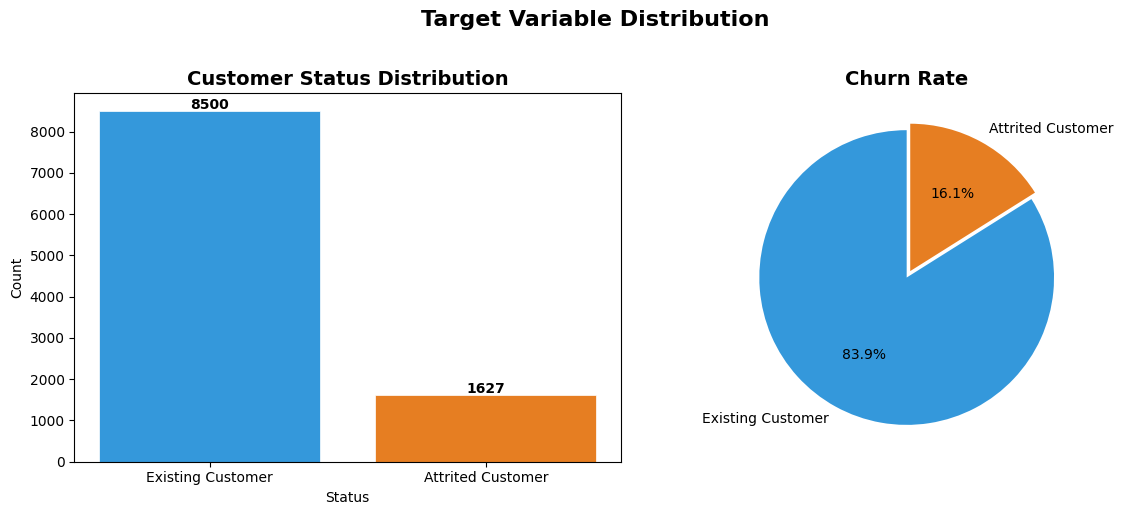

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count Plot
status_counts = df['status'].value_counts()
axes[0].bar(status_counts.index, status_counts.values,
            color=['#3498db', '#e67e22'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Customer Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(status_counts.values,
            labels=status_counts.index,
            autopct='%1.1f%%',
            colors=['#3498db', '#e67e22'],
            startangle=90,
            explode=(0, 0.05))
axes[1].set_title('Churn Rate', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##Univariate Analysis — Target Variable (status):

Chart 1: Customer Status Distribution (Bar Chart)
- Existing Customer: 8,500 (83.9%)
- Attrited Customer: 1,627 (16.1%)

Chart 2: Churn Rate (Pie Chart)
- Clear class imbalance: ratio is roughly 5:1
- Only 1 in 6 customers churned

⚠️ Imbalance Action Required before Modeling:
- Will handle with SMOTE or class_weight

In [ ]:
from scipy import stats

def plot_numeric_group(cols, title):
    fig, axes = plt.subplots(len(cols), 2, figsize=(16, len(cols) * 4))

    for i, col in enumerate(cols):
        ax_hist = axes[i, 0]
        ax_box  = axes[i, 1]

        # Histogram + KDE
        ax_hist.hist(df[col], bins=30, color='#3498db', edgecolor='white',
                     linewidth=0.5, density=True, alpha=0.7)
        df[col].plot.kde(ax=ax_hist, color='#3498db', linewidth=2, label='KDE')

        # Normal Distribution curve
        mu, std = df[col].mean(), df[col].std()
        x = np.linspace(df[col].min(), df[col].max(), 200)
        ax_hist.plot(x, stats.norm.pdf(x, mu, std),
                     color='green', linewidth=2, linestyle='-', label='Normal Dist')

        # Mean & Median lines
        ax_hist.axvline(mu,             color='red',    linestyle='--',
                        linewidth=1.5,  label=f'Mean: {mu:.1f}')
        ax_hist.axvline(df[col].median(), color='orange', linestyle='--',
                        linewidth=1.5,  label=f'Median: {df[col].median():.1f}')

        ax_hist.set_title(f'{col} — Distribution', fontweight='bold')
        ax_hist.set_xlabel(col)
        ax_hist.set_ylabel('Density')
        ax_hist.legend(fontsize=8)

        # Boxplot
        ax_box.boxplot(df[col], vert=False, patch_artist=True,
                       boxprops=dict(facecolor='#3498db', color='#3498db'),
                       medianprops=dict(color='white', linewidth=2),
                       whiskerprops=dict(color='#3498db'),
                       capprops=dict(color='#3498db'),
                       flierprops=dict(marker='o', color='#e67e22', alpha=0.4))
        ax_box.set_title(f'{col} — Boxplot', fontweight='bold')
        ax_box.set_xlabel(col)

    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

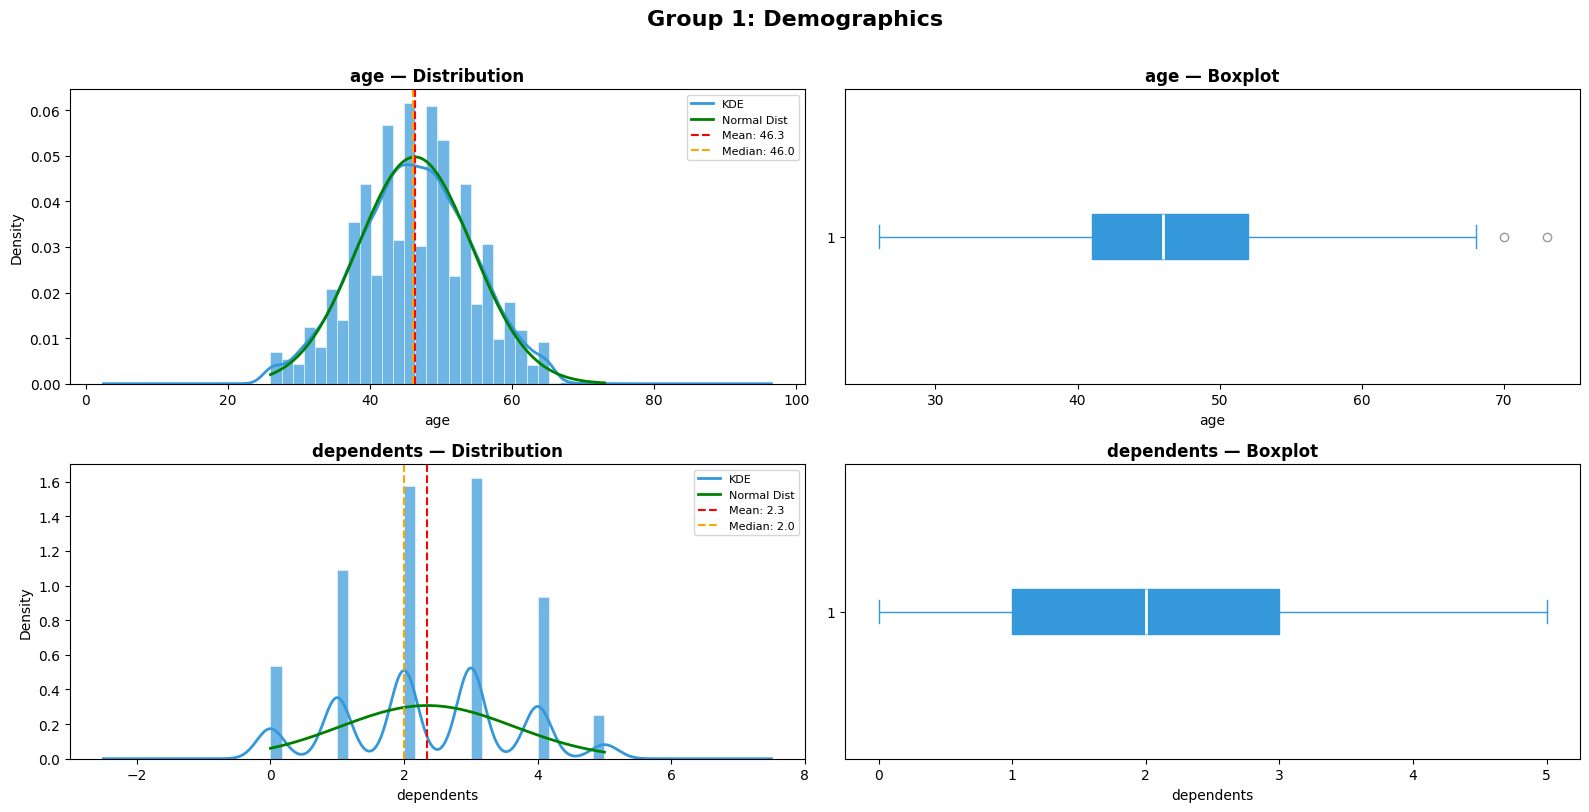

In [ ]:
# Group 1 — Demographics
plot_numeric_group(['age', 'dependents'],
                   'Group 1: Demographics')

##Group 1: Demographics — Univariate Analysis

age:
- Near normal distribution ✅
- Mean ≈ Median (46.3 vs 46.0) — symmetric
- Slight right skew after 50
- 2 outliers at ~68 and ~73 — keeping as-is
- IQR: 41 → 52

dependents:
- Discrete variable (0 → 5) — normal curve not applicable
- Most common: 2 and 3 dependents
- No outliers ✅
- Will treat as ordinal in modeling

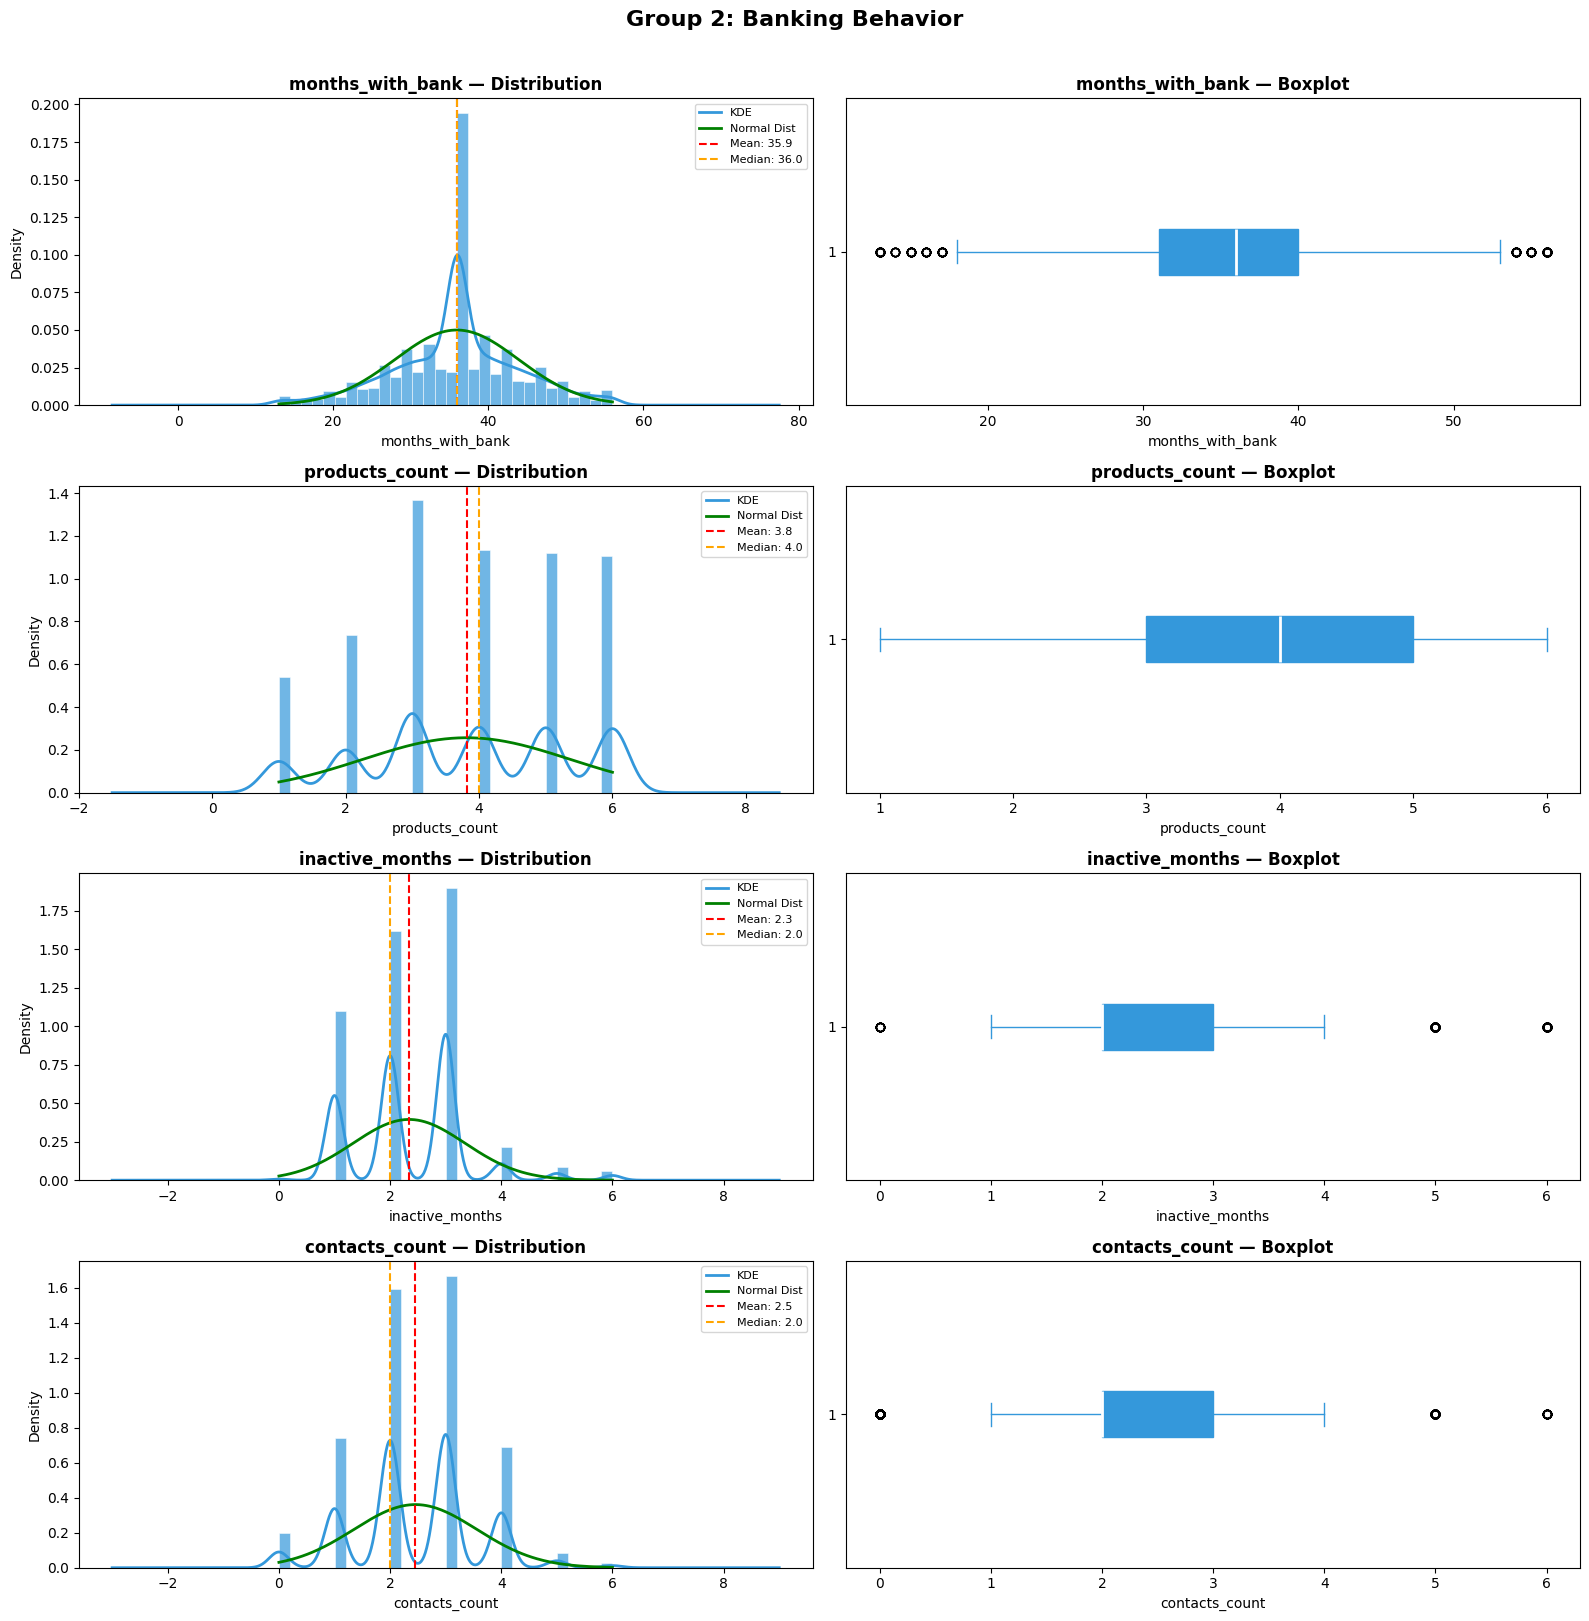

In [ ]:
# Group 2 — Banking Behavior
plot_numeric_group(['months_with_bank', 'products_count', 'inactive_months', 'contacts_count'],
                   'Group 2: Banking Behavior')

##Group 2: Banking Behavior — Univariate Analysis

months_with_bank:
- Near normal distribution ✅
- Mean ≈ Median (35.9 vs 36.0) — symmetric
- Majority between 25 → 45 months (2-4 years)
- Few outliers on both sides (13-15 left, 54-56 right) — valid and kept as-is

products_count:
- Discrete variable (1 → 6) — normal curve not applicable
- Multimodal — peaks at 3, 4, 5, 6
- No outliers ✅
- Will treat as ordinal in preprocessing

inactive_months:
- Discrete variable (0 → 6) — normal curve not applicable
- Bimodal — peaks at 2 and 3
- 3 outliers: 0 (left), 5 and 6 (right) — valid and kept as-is
- ⚠️ High inactive_months (5-6) may correlate with churn — to verify in Bivariate

contacts_count:
- Discrete variable (0 → 6) — normal curve not applicable
- Bimodal — peaks at 2 and 3, similar shape to inactive_months
- 3 outliers: 0 (left), 5 and 6 (right) — valid and kept as-is
- ⚠️ High contacts_count (5-6) may indicate dissatisfied customers — to verify in Bivariate

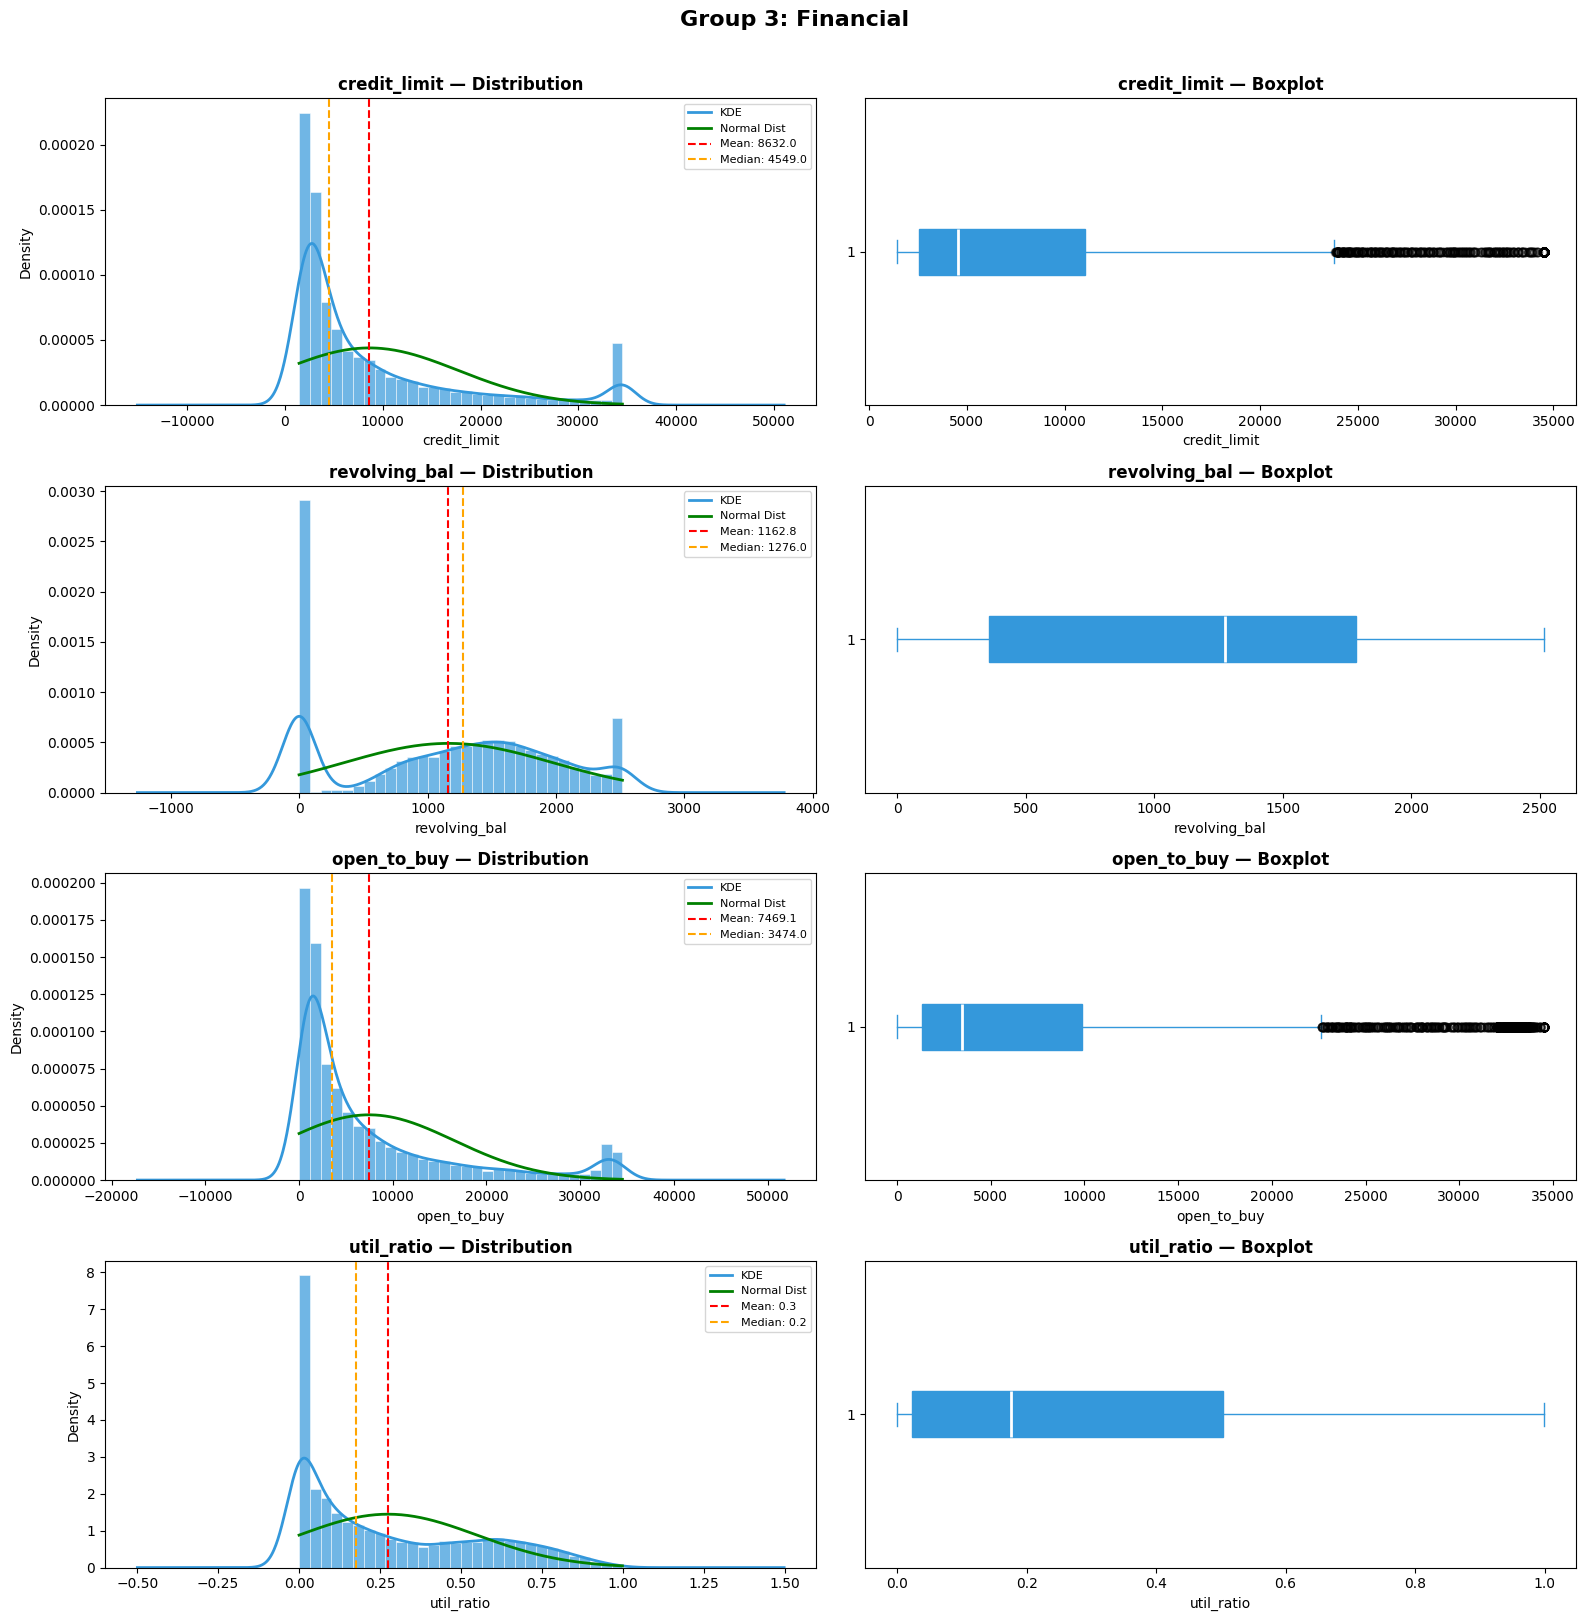

In [ ]:
# Group 3 — Financial
plot_numeric_group(['credit_limit', 'revolving_bal', 'open_to_buy', 'util_ratio'],
                   'Group 3: Financial')


##Group 3: Financial — Univariate Analysis

credit_limit:
- Right skewed — majority below 10,000
- Mean (8,632) >> Median (4,549) — strong skew
- Small bump at ~34,000 (high-limit customers segment)
- 984 outliers (9.7%) on the right — confirmed from validity check
- ⚠️ Action in Preprocessing: Log Transform or Capping

revolving_bal:
- Bimodal distribution — peak at 0 and another from 500 → 2,500
- Peak at 0 = customers who pay their balance in full every month
- Mean ≈ Median (1,162 vs 1,276) — not heavily skewed
- No outliers ✅
- ⚠️ To verify in Bivariate: does revolving_bal = 0 correlate with churn?

open_to_buy:
- Right skewed — almost identical shape to credit_limit (expected)
- Mean (7,469) >> Median (3,474) — strong skew
- 963 outliers (9.5%) on the right — confirmed from validity check
- ⚠️ Action in Preprocessing: Log Transform or Capping
- ⚠️ Likely highly correlated with credit_limit — may drop one before modeling
  (to verify in Correlation Heatmap)

util_ratio:
- Right skewed — large spike at 0 (customers not using their card at all)
- Mean (0.3) > Median (0.2)
- No outliers ✅ — valid range (0 → 1)
- ⚠️ To verify in Bivariate: does util_ratio = 0 correlate with churn?

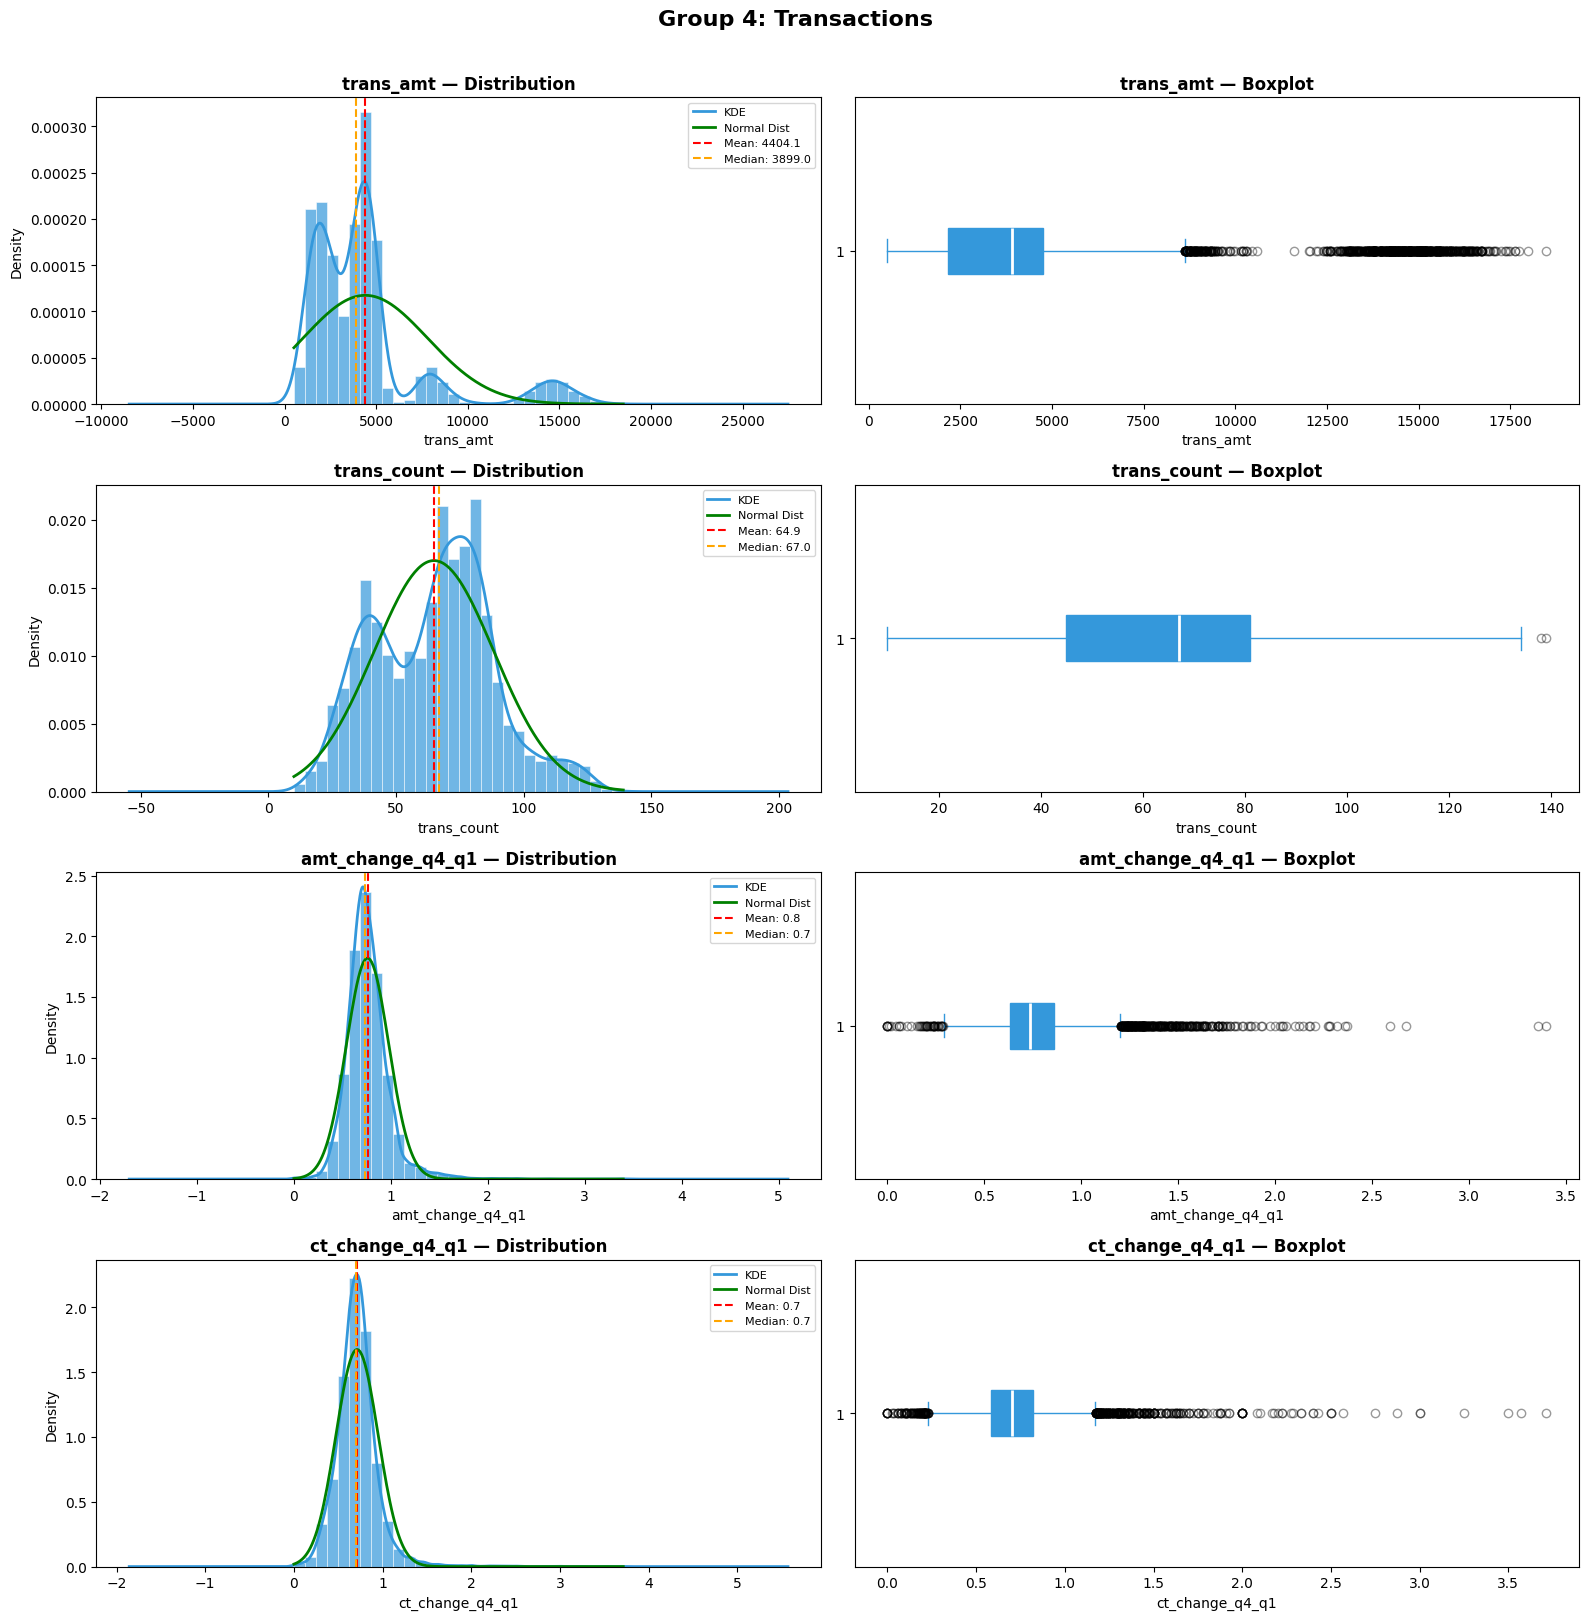

In [ ]:
# Group 4 — Transactions
plot_numeric_group(['trans_amt', 'trans_count', 'amt_change_q4_q1', 'ct_change_q4_q1'],
                   'Group 4: Transactions')

##Group 4: Transactions — Univariate Analysis

trans_amt:
- Multimodal — 3 peaks at ~2,000 / ~4,000 / ~15,000
  (likely 3 different customer spending segments)
- Mean ≈ Median (4,404 vs 3,899) — not heavily skewed
- Heavy outliers on the right (above ~9,000) — valid, kept as-is
- ⚠️ To verify in Bivariate: low trans_amt likely correlates with churn

trans_count:
- Left skewed — Mean (64.9) < Median (67.0)
- Majority between 40 → 100 transactions
- Only 1 outlier at ~139 — valid, kept as-is
- ⚠️ To verify in Bivariate: low trans_count likely correlates with churn
- Expected to be one of the strongest churn predictors

amt_change_q4_q1:
- Near normal distribution ✅
- Mean ≈ Median (0.8 vs 0.7) — symmetric
- Outliers on both sides — left outliers (near 0) indicate sharp drop in spending
- ⚠️ To verify in Bivariate: low values (near 0) may signal upcoming churn

ct_change_q4_q1:
- Near normal distribution ✅
- Mean = Median = 0.7 — perfectly symmetric
- Outliers on both sides — left outliers (near 0) indicate sharp drop in transaction count
- ⚠️ Likely highly correlated with amt_change_q4_q1 — to verify in Correlation Heatmap
- ⚠️ To verify in Bivariate: low values (near 0) may signal upcoming churn

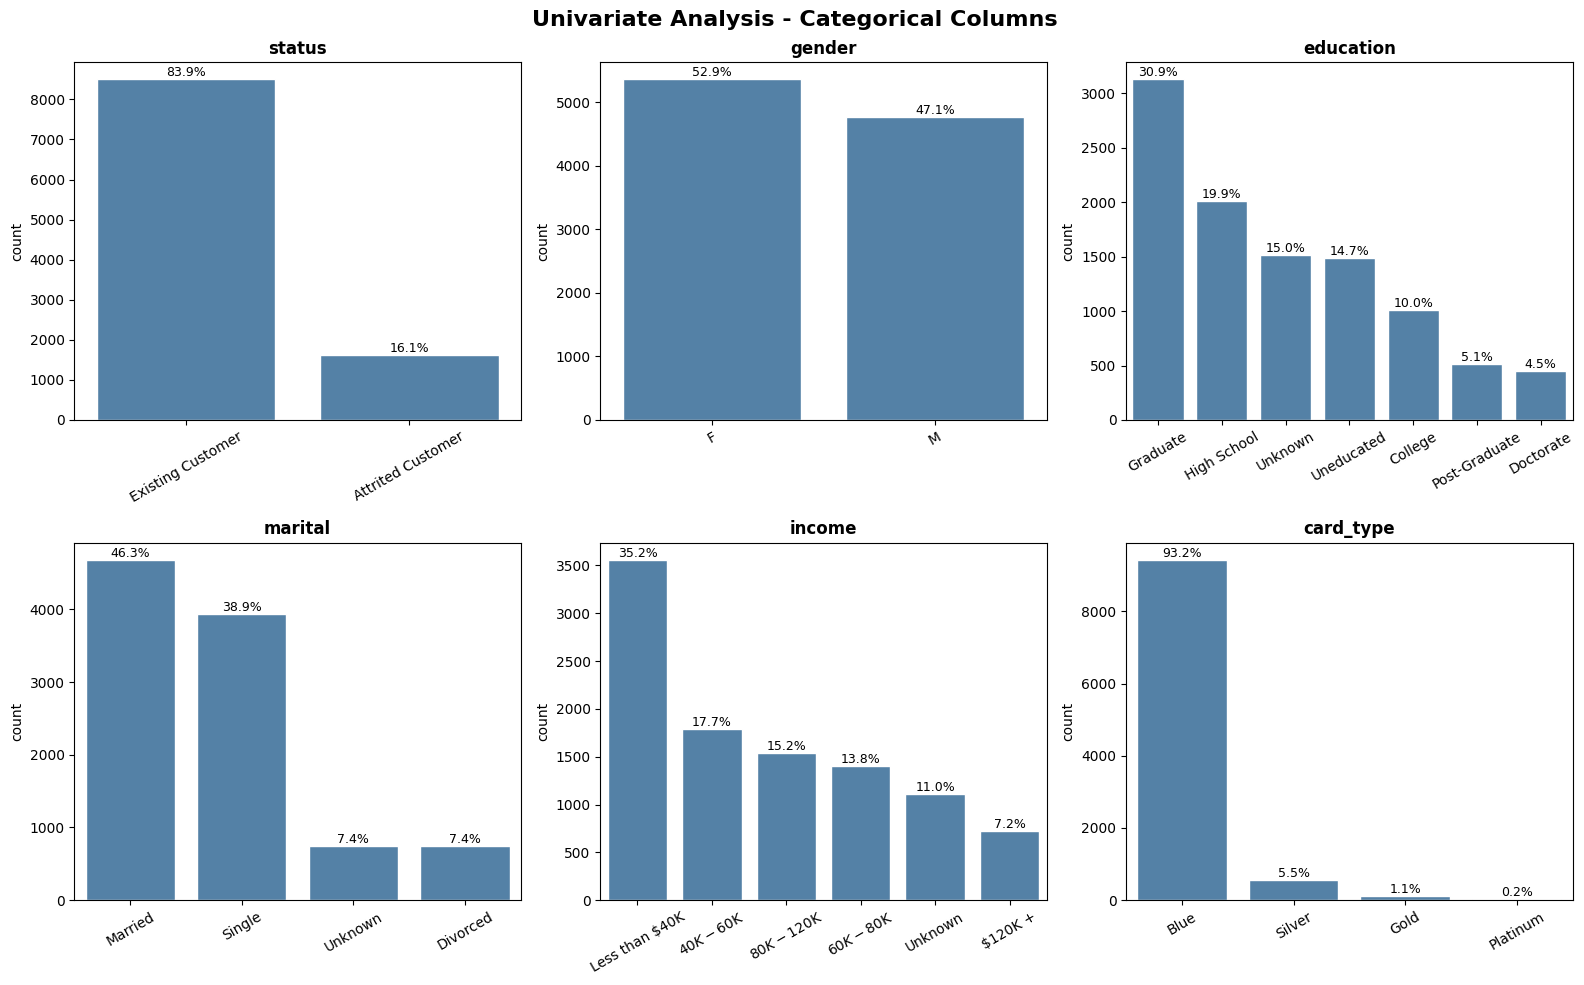

In [ ]:
cat_cols = ['status', 'gender', 'education', 'marital', 'income', 'card_type']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Univariate Analysis - Categorical Columns',
             fontsize=16, fontweight='bold')

for i, col in enumerate(cat_cols):
    ax = axes[i//3, i%3]

    order = df[col].value_counts().index

    sns.countplot(data=df, x=col, ax=ax, order=order,
                  color='steelblue', edgecolor='white')

    for p in ax.patches:
        pct = f'{100 * p.get_height() / len(df):.1f}%'
        ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

##Univariate Analysis — Categorical Features (Part 1)

status:
- Existing: 8,500 (83.9%) vs Attrited: 1,627 (16.1%)
- Class imbalance confirmed — will handle in modeling

gender:
- Balanced: F 52.9% vs M 47.1%
- No action needed

education:
- Graduate highest (30.9%), Doctorate lowest (4.5%)
- Unknown (15%) treated as separate category after fillna
- 7 categories total

marital:
- Married 46.3%, Single 38.9%
- Unknown and Divorced nearly identical (7.4% each)

income:
- Skewed toward lower income — Less than $40K is 35.2%
- $120K+ only 7.2%
- Unknown (11%) treated as separate category after fillna

card_type:
- Heavily imbalanced — Blue dominates at 93.2%
- Silver 5.5%, Gold 1.1%, Platinum 0.2%
- ⚠️ May drop before modeling if Bivariate shows
  no meaningful difference in churn rate across card types

## Q14 -- Rare Categories Analysis

Identifying categories that appear very rarely (< 3% of total rows) and deciding whether to keep them or group into 'Other'.

In [ ]:
# Q14 -- Rare Categories (< 3% threshold)
print("=" * 55)
print("Q14 -- RARE CATEGORIES (threshold < 3%)")
print("=" * 55)

cat_cols = ["gender", "education", "marital", "income", "card_type"]
threshold = 3.0

for col in cat_cols:
    print(f"\n{col}:")
    counts = df[col].value_counts(normalize=True) * 100
    for cat, pct in counts.items():
        if pct < threshold:
            print(f"  {str(cat):<25} {pct:.2f}%  <-- RARE")
        else:
            print(f"  {str(cat):<25} {pct:.1f}%")

print("\n" + "=" * 55)
print("DECISION SUMMARY")
print("=" * 55)
print()
print("card_type:")
print("  Platinum (~0.2%) and Gold (~1.1%) are rare.")
print("  Decision: KEEP for EDA, DROP before modeling.")
print("  Reason: churn rates unreliable on fewer than 120 rows.")
print()
print("education, marital, income, gender:")
print("  All categories are above 3% -- no action needed.")


Q14 -- RARE CATEGORIES (threshold < 3%)

gender:
  F                         52.9%
  M                         47.1%

education:
  Graduate                  30.9%
  High School               19.9%
  Unknown                   15.0%
  Uneducated                14.7%
  College                   10.0%
  Post-Graduate             5.1%
  Doctorate                 4.5%

marital:
  Married                   46.3%
  Single                    38.9%
  Unknown                   7.4%
  Divorced                  7.4%

income:
  Less than $40K            35.2%
  $40K - $60K               17.7%
  $80K - $120K              15.2%
  $60K - $80K               13.8%
  Unknown                   11.0%
  $120K +                   7.2%

card_type:
  Blue                      93.2%
  Silver                    5.5%
  Gold                      1.15%  <-- RARE
  Platinum                  0.20%  <-- RARE

DECISION SUMMARY

card_type:
  Platinum (~0.2%) and Gold (~1.1%) are rare.
  Decision: KEEP for EDA, DROP befor

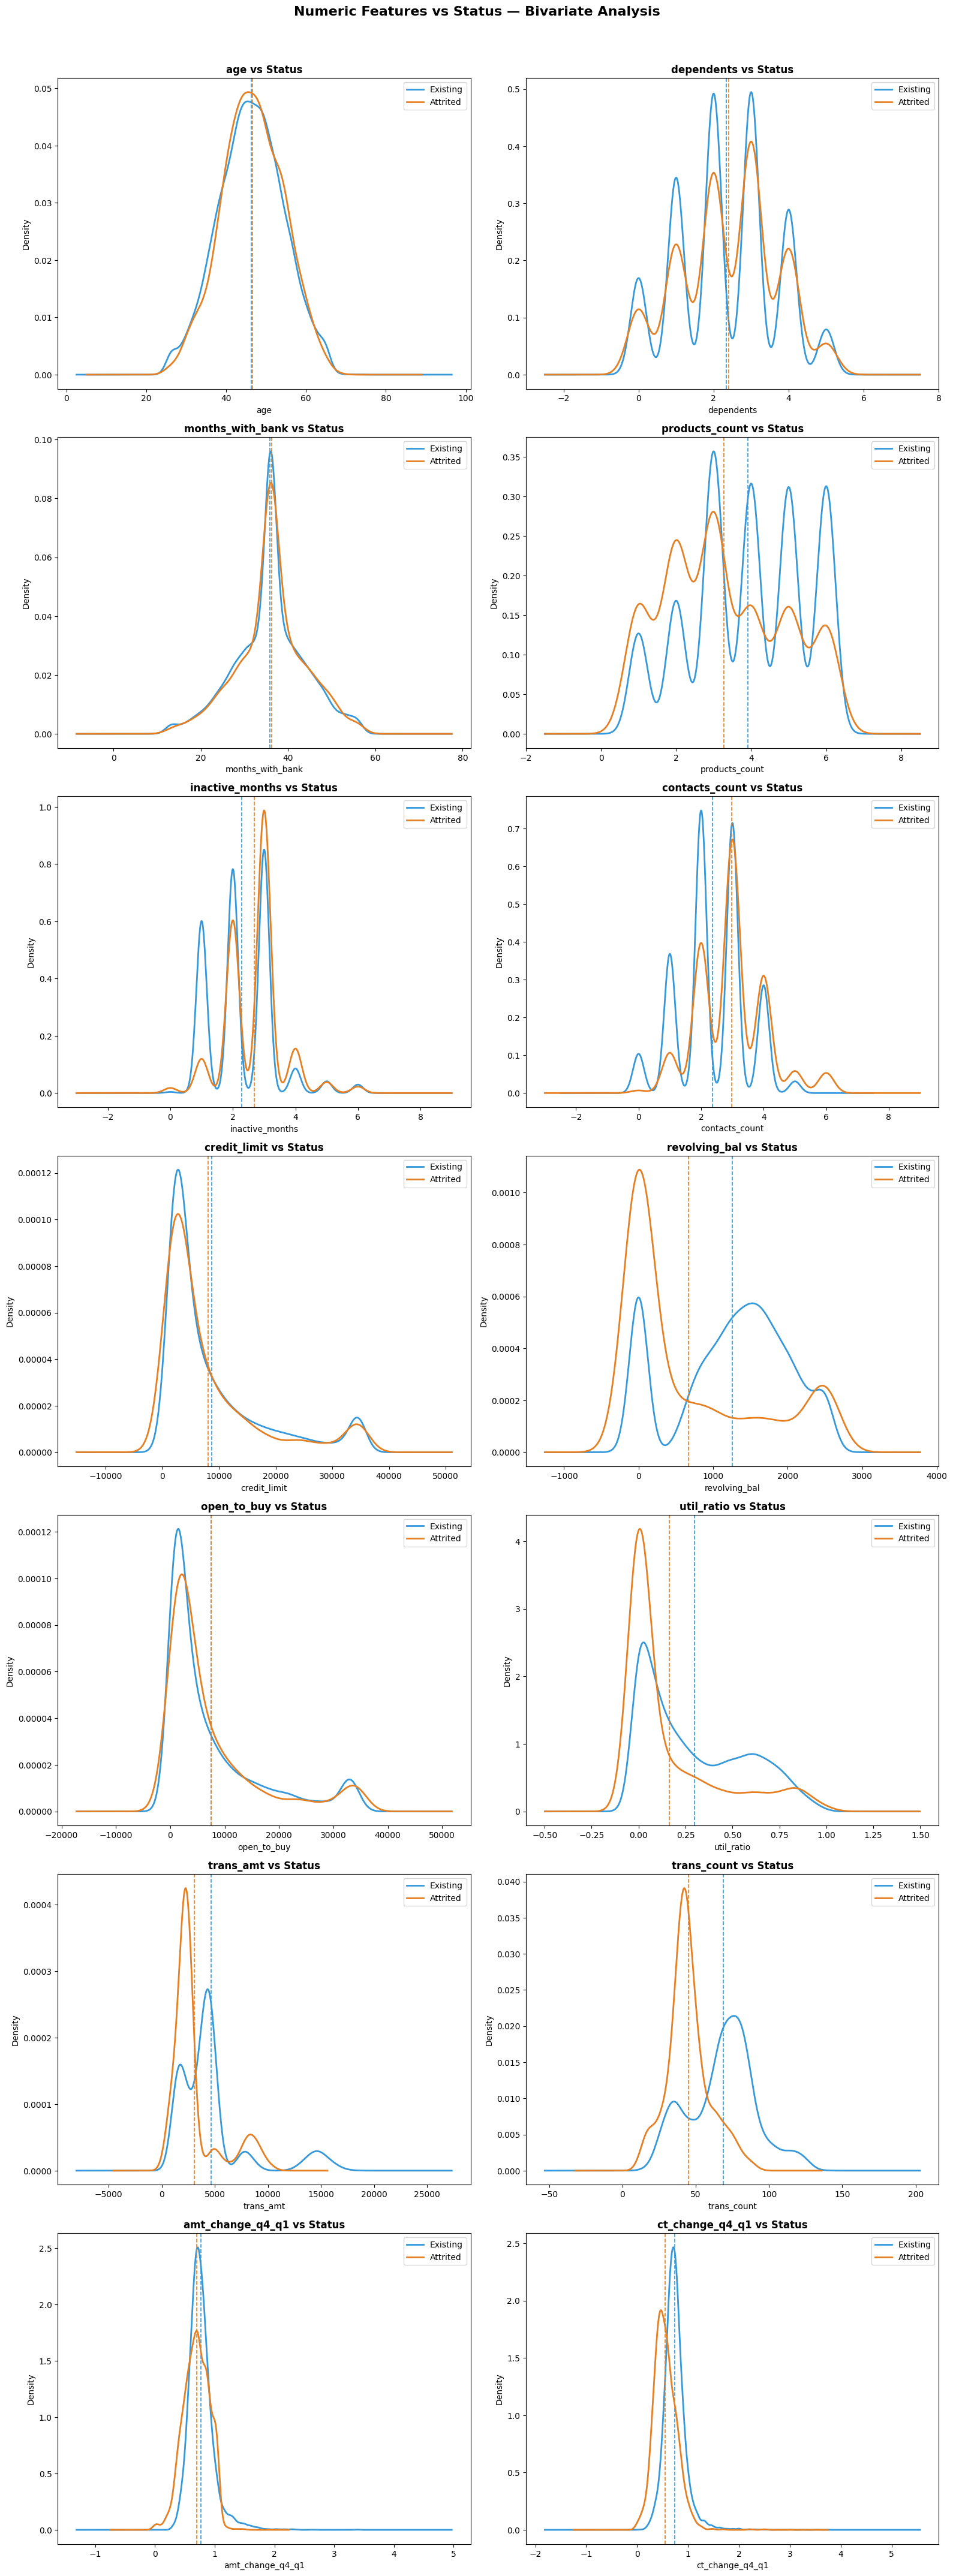

In [ ]:
fig, axes = plt.subplots(8, 2, figsize=(16, 48))
axes = axes.flatten()

numeric_cols = ['age', 'dependents', 'months_with_bank', 'products_count',
                'inactive_months', 'contacts_count', 'credit_limit',
                'revolving_bal', 'open_to_buy', 'util_ratio',
                'trans_amt', 'trans_count', 'amt_change_q4_q1', 'ct_change_q4_q1']

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    for status, color, label in zip(
        ['Existing Customer', 'Attrited Customer'],
        ['#3498db', '#e67e22'],
        ['Existing', 'Attrited']
    ):
        subset = df[df['status'] == status][col]
        subset.plot.kde(ax=ax, color=color, linewidth=2, label=label)
        ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=1.2)

    ax.set_title(f'{col} vs Status', fontweight='bold', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()


for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Features vs Status — Bivariate Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Bivariate Analysis — Numeric Features vs Status

### ✅ Strong Features (clear separation)
| Feature | Observation |
|---------|-------------|
| `trans_count` | Attrited peak at 40-50 vs Existing at 60-100 |
| `trans_amt` | Attrited spend far less per year |
| `revolving_bal` | Attrited concentrated near 0 (stop using card) |
| `products_count` | Attrited at 1-3 vs Existing at 3-6 |
| `util_ratio` | Attrited spike at 0 — not using credit at all |

### ⚠️ Medium Features
| Feature | Observation |
|---------|-------------|
| `contacts_count` | Higher contacts → dissatisfied → churn |
| `inactive_months` | Attrited concentrated at 3+ months inactive |
| `ct_change_q4_q1` | Drop in transaction count signals churn |
| `amt_change_q4_q1` | Drop in spending signals churn |

### ❌ Weak Features
- `age`, `dependents`, `months_with_bank`, `credit_limit`, `open_to_buy`


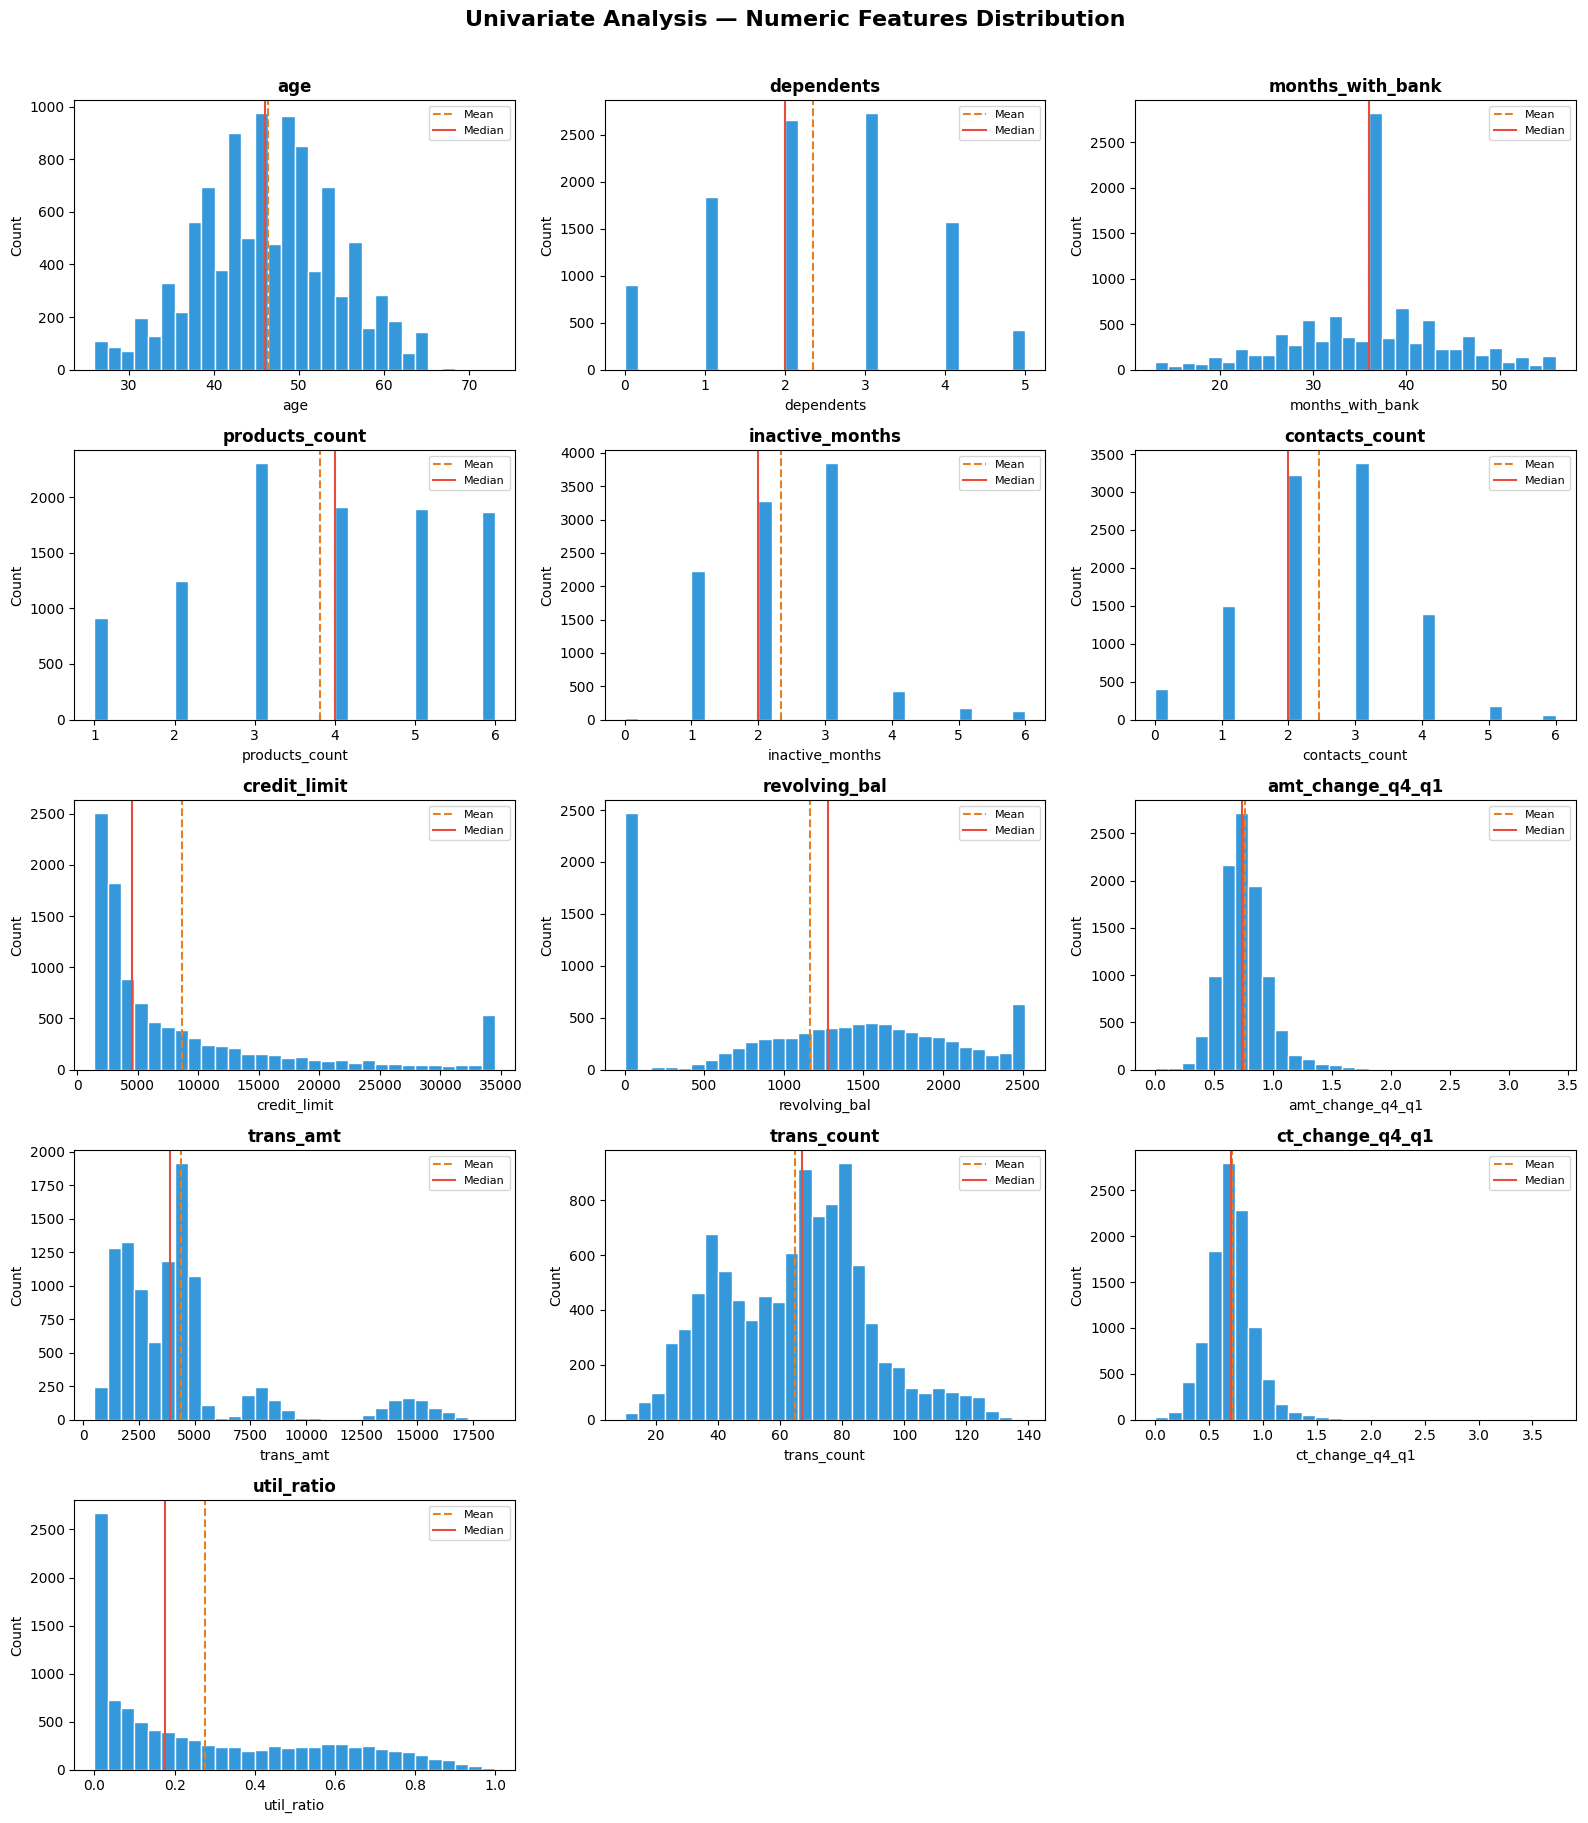

In [ ]:
# ============================================================
# Univariate Analysis — Numeric Features Distribution
# ============================================================

num_cols = ['age', 'dependents', 'months_with_bank', 'products_count',
            'inactive_months', 'contacts_count', 'credit_limit',
            'revolving_bal', 'amt_change_q4_q1', 'trans_amt',
            'trans_count', 'ct_change_q4_q1', 'util_ratio']

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df[col], bins=30, color='#3498db', edgecolor='white')
    ax.axvline(df[col].mean(),   color='#e67e22', linestyle='--', label='Mean')
    ax.axvline(df[col].median(), color='#e74c3c', linestyle='-',  label='Median')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Analysis — Numeric Features Distribution',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Univariate Analysis — Numeric Features Distribution

### Objective:
Understand the distribution and skewness of each numeric feature

---

### Results:

**Right-skewed (log transform recommended):**
- credit_limit: heavy right skew — log transform applied ✅
- trans_amt: right skewed
- revolving_bal: spike at 0

**Approximately Normal:**
- age, months_with_bank, trans_count

**Discrete / Limited Range:**
- dependents (0-5), products_count (1-6)
- inactive_months (0-6), contacts_count (0-6)

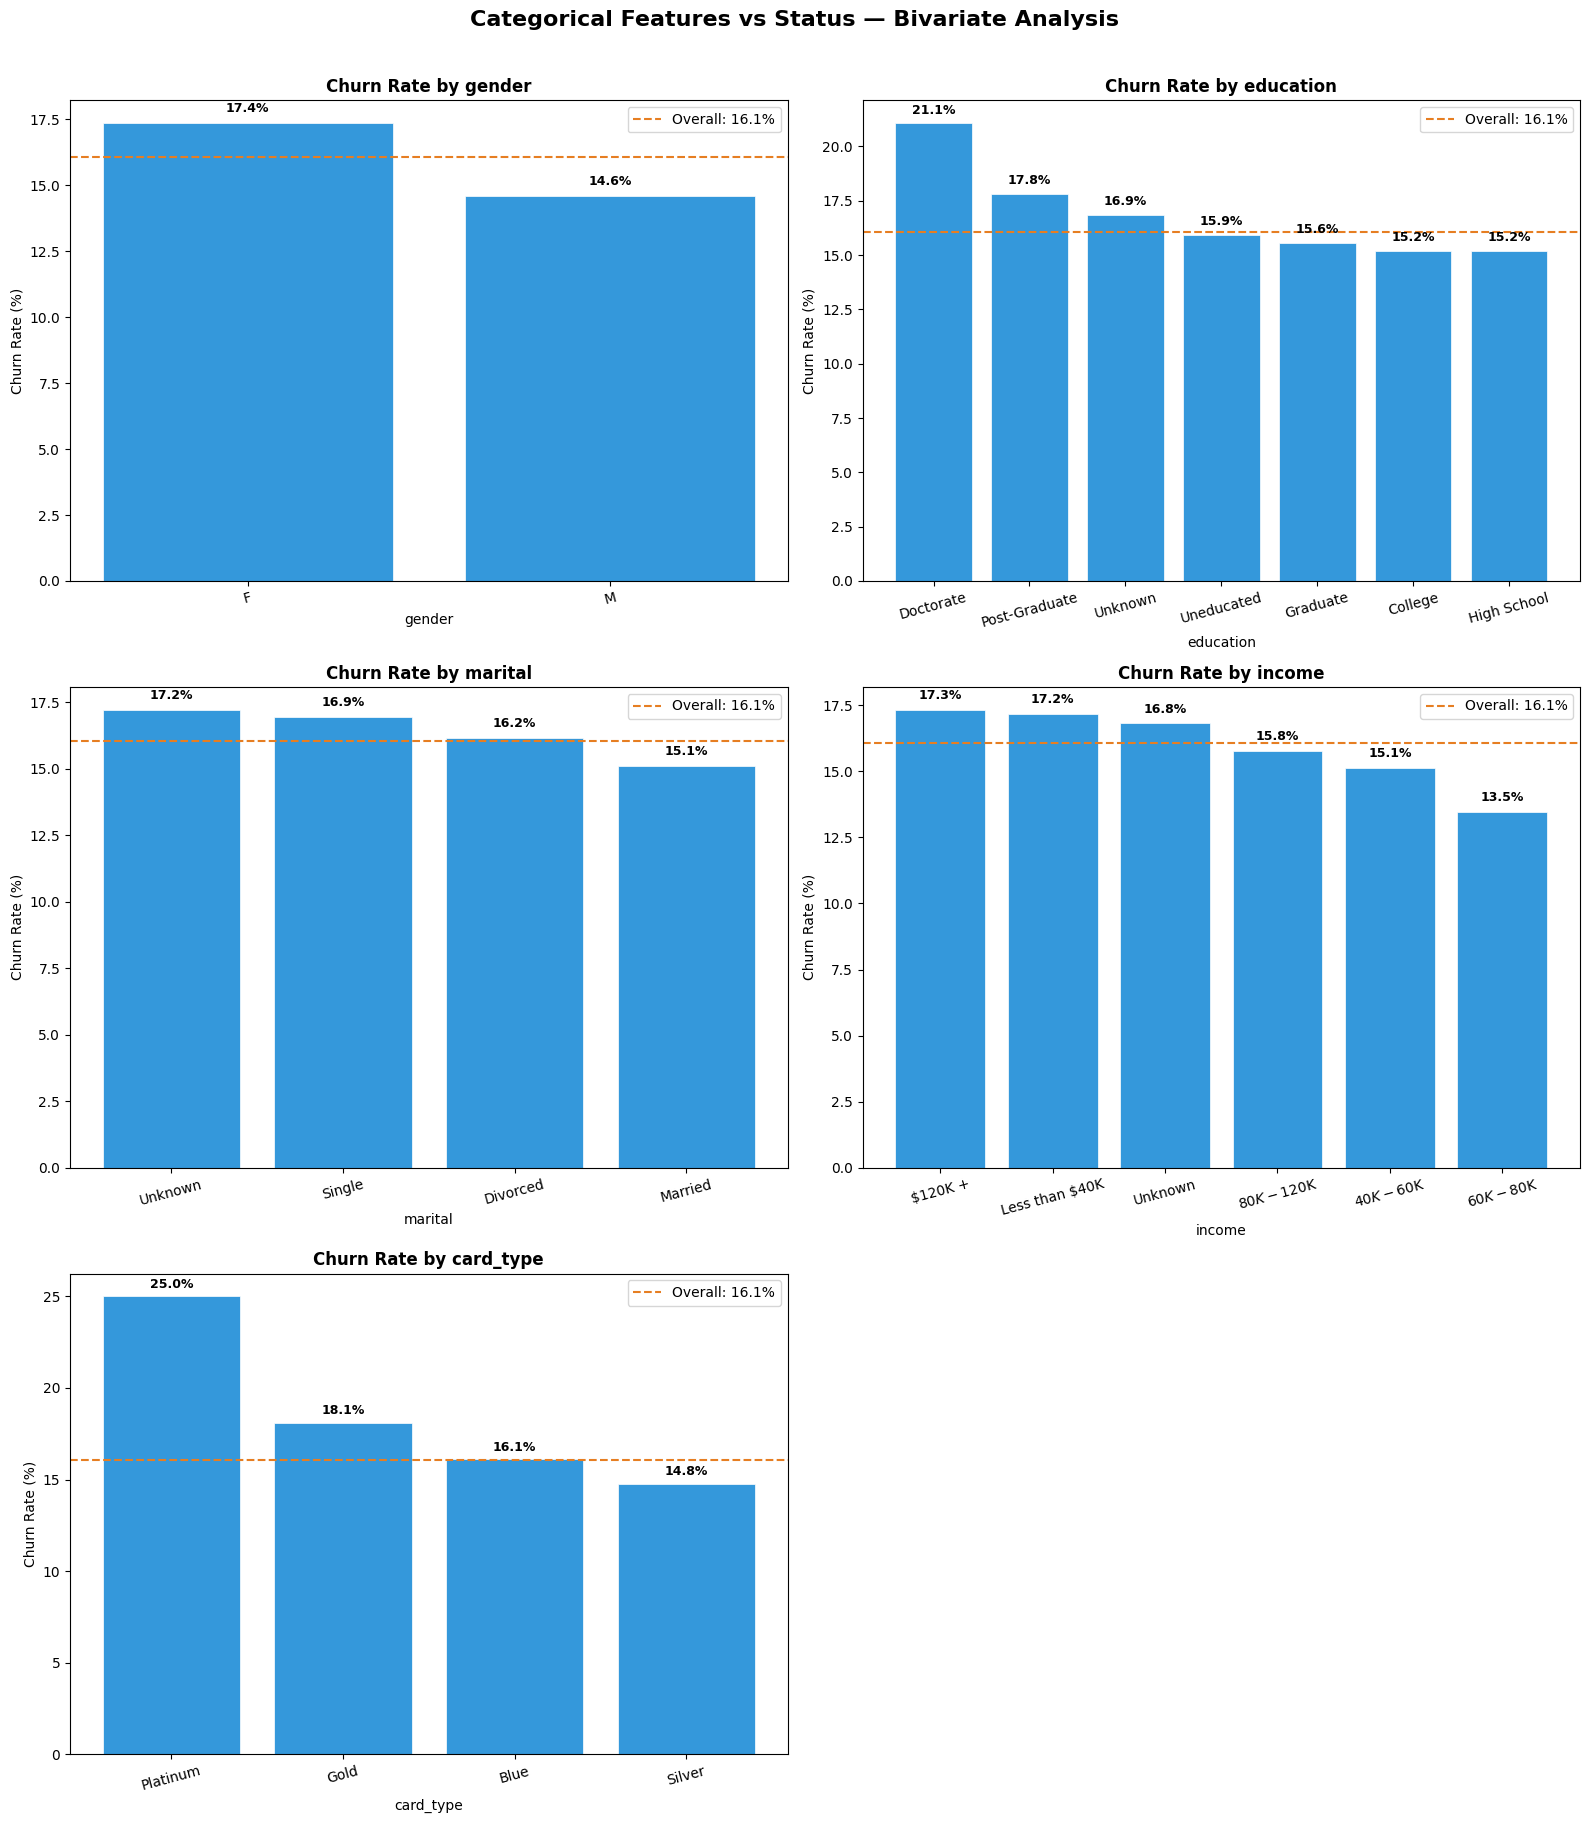

In [ ]:
cat_cols = ['gender', 'education', 'marital', 'income', 'card_type']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # calculate churn rate per category
    churn_rate = df.groupby(col)['status'].apply(
        lambda x: (x == 'Attrited Customer').sum() / len(x) * 100
    ).sort_values(ascending=False)

    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                       color='#3498db', edgecolor='white', linewidth=0.5)

    # add churn rate label above each bar
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3,
                     f'{val:.1f}%',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

    # add overall churn rate reference line
    overall = (df['status'] == 'Attrited Customer').sum() / len(df) * 100
    axes[i].axhline(overall, color='#e67e22', linestyle='--',
                    linewidth=1.5, label=f'Overall: {overall:.1f}%')

    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].legend()

# hide extra subplot
axes[-1].set_visible(False)

plt.suptitle('Categorical Features vs Status — Bivariate Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##Bivariate Analysis — Categorical Features vs Status:

gender:
- F: 17.4% vs M: 14.6%
- Small difference — weak feature
- Will keep but not expected to be important in modeling

education:
- Doctorate highest (21.1%), High School lowest (15.2%)
- Interesting: higher education = higher churn rate
- Small overall differences — weak to medium feature

marital:
- Range: 15.1% (Married) → 17.2% (Unknown)
- Very small differences across categories
- Weak feature ❌

income:
- $120K+ highest churn (17.3%), $60K-$80K lowest (13.5%)
- Interesting: highest income = highest churn rate
- Small overall differences — weak to medium feature

card_type:
- Platinum: 25.0%, Gold: 18.1%, Blue: 16.1%, Silver: 14.8%
- Platinum churn rate looks high but only 20 customers — not reliable
- Gold only 116 customers — not reliable
- Overall: weak feature due to heavy imbalance (Blue = 93%)
- Decision: drop before modeling ✅

Overall Conclusion — Categorical Features:
- None of the categorical features are strong churn pr

In [ ]:
# ============================================================
# CORRELATION WITH TARGET (status)
# ============================================================

# Step 1: encode target as binary
df['target'] = (df['status'] == 'Attrited Customer').astype(int)

# ── Numeric columns → Point-Biserial (نفس نتيجة Pearson مع binary target) ──
num_cols = ['age', 'dependents', 'months_with_bank', 'products_count',
            'inactive_months', 'contacts_count', 'credit_limit',
            'revolving_bal', 'open_to_buy', 'amt_change_q4_q1',
            'trans_amt', 'trans_count', 'ct_change_q4_q1', 'util_ratio']

num_corr = (df[num_cols]
            .corrwith(df['target'])
            .rename('correlation')
            .reset_index()
            .rename(columns={'index': 'feature'}))

num_corr['abs_corr'] = num_corr['correlation'].abs()
num_corr['type']     = 'Numeric'

# ── Categorical columns → Cramér's V ──
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(col):
    ct       = pd.crosstab(df[col], df['target'])
    chi2     = chi2_contingency(ct)[0]
    n        = ct.values.sum()
    min_dim  = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

cat_cols = ['gender', 'education', 'marital', 'income', 'card_type']

cat_corr = pd.DataFrame({
    'feature'  : cat_cols,
    'correlation': [cramers_v(c) for c in cat_cols],
    'type'     : 'Categorical'
})
cat_corr['abs_corr'] = cat_corr['correlation']

# ── Merge & Sort ──
corr_df = (pd.concat([num_corr, cat_corr], ignore_index=True)
             .sort_values('abs_corr', ascending=False)
             .reset_index(drop=True))

print(corr_df[['feature', 'correlation', 'type']].to_string(index=False))

         feature  correlation        type
     trans_count    -0.371403     Numeric
 ct_change_q4_q1    -0.290054     Numeric
   revolving_bal    -0.263053     Numeric
  contacts_count     0.204491     Numeric
      util_ratio    -0.178410     Numeric
       trans_amt    -0.168598     Numeric
 inactive_months     0.152449     Numeric
  products_count    -0.150005     Numeric
amt_change_q4_q1    -0.131063     Numeric
          gender     0.037002 Categorical
          income     0.035597 Categorical
       education     0.035149 Categorical
         marital     0.024454 Categorical
    credit_limit    -0.023873     Numeric
      dependents     0.018991     Numeric
             age     0.018203     Numeric
       card_type     0.014853 Categorical
months_with_bank     0.013687     Numeric
     open_to_buy    -0.000285     Numeric


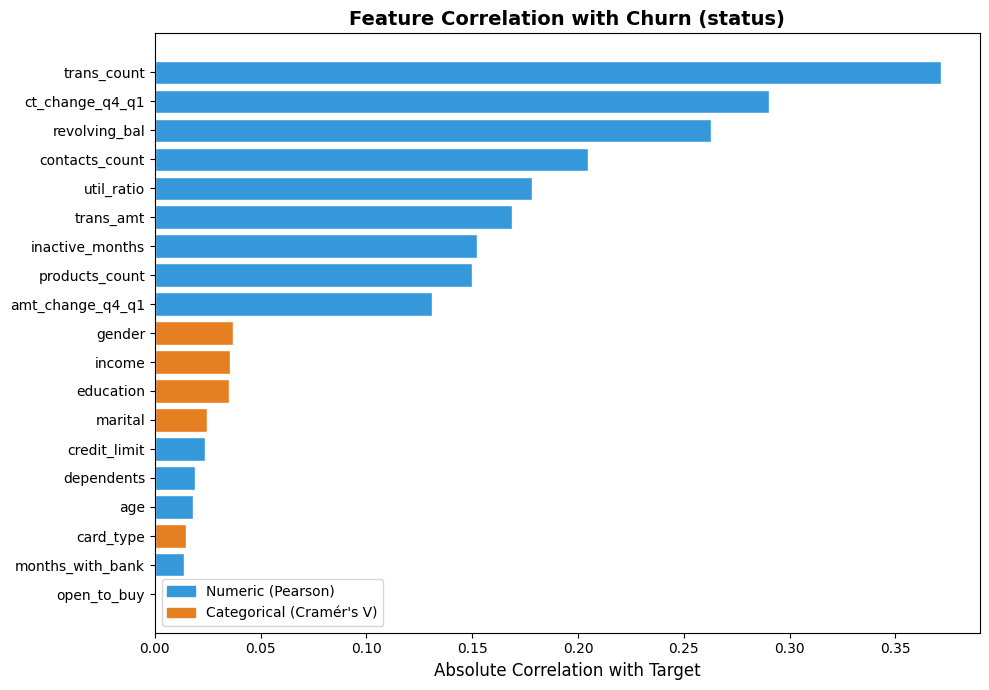

In [ ]:
# ── Plot ──
fig, ax = plt.subplots(figsize=(10, 7))

colors = corr_df['type'].map({'Numeric': '#3498db', 'Categorical': '#e67e22'})

ax.barh(corr_df['feature'], corr_df['abs_corr'],
        color=colors, edgecolor='white')

ax.set_xlabel('Absolute Correlation with Target', fontsize=12)
ax.set_title('Feature Correlation with Churn (status)',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()

# legend
from matplotlib.patches import Patch
legend = [Patch(color='#3498db', label='Numeric (Pearson)'),
          Patch(color='#e67e22', label='Categorical (Cramér\'s V)')]
ax.legend(handles=legend)

plt.tight_layout()
plt.show()

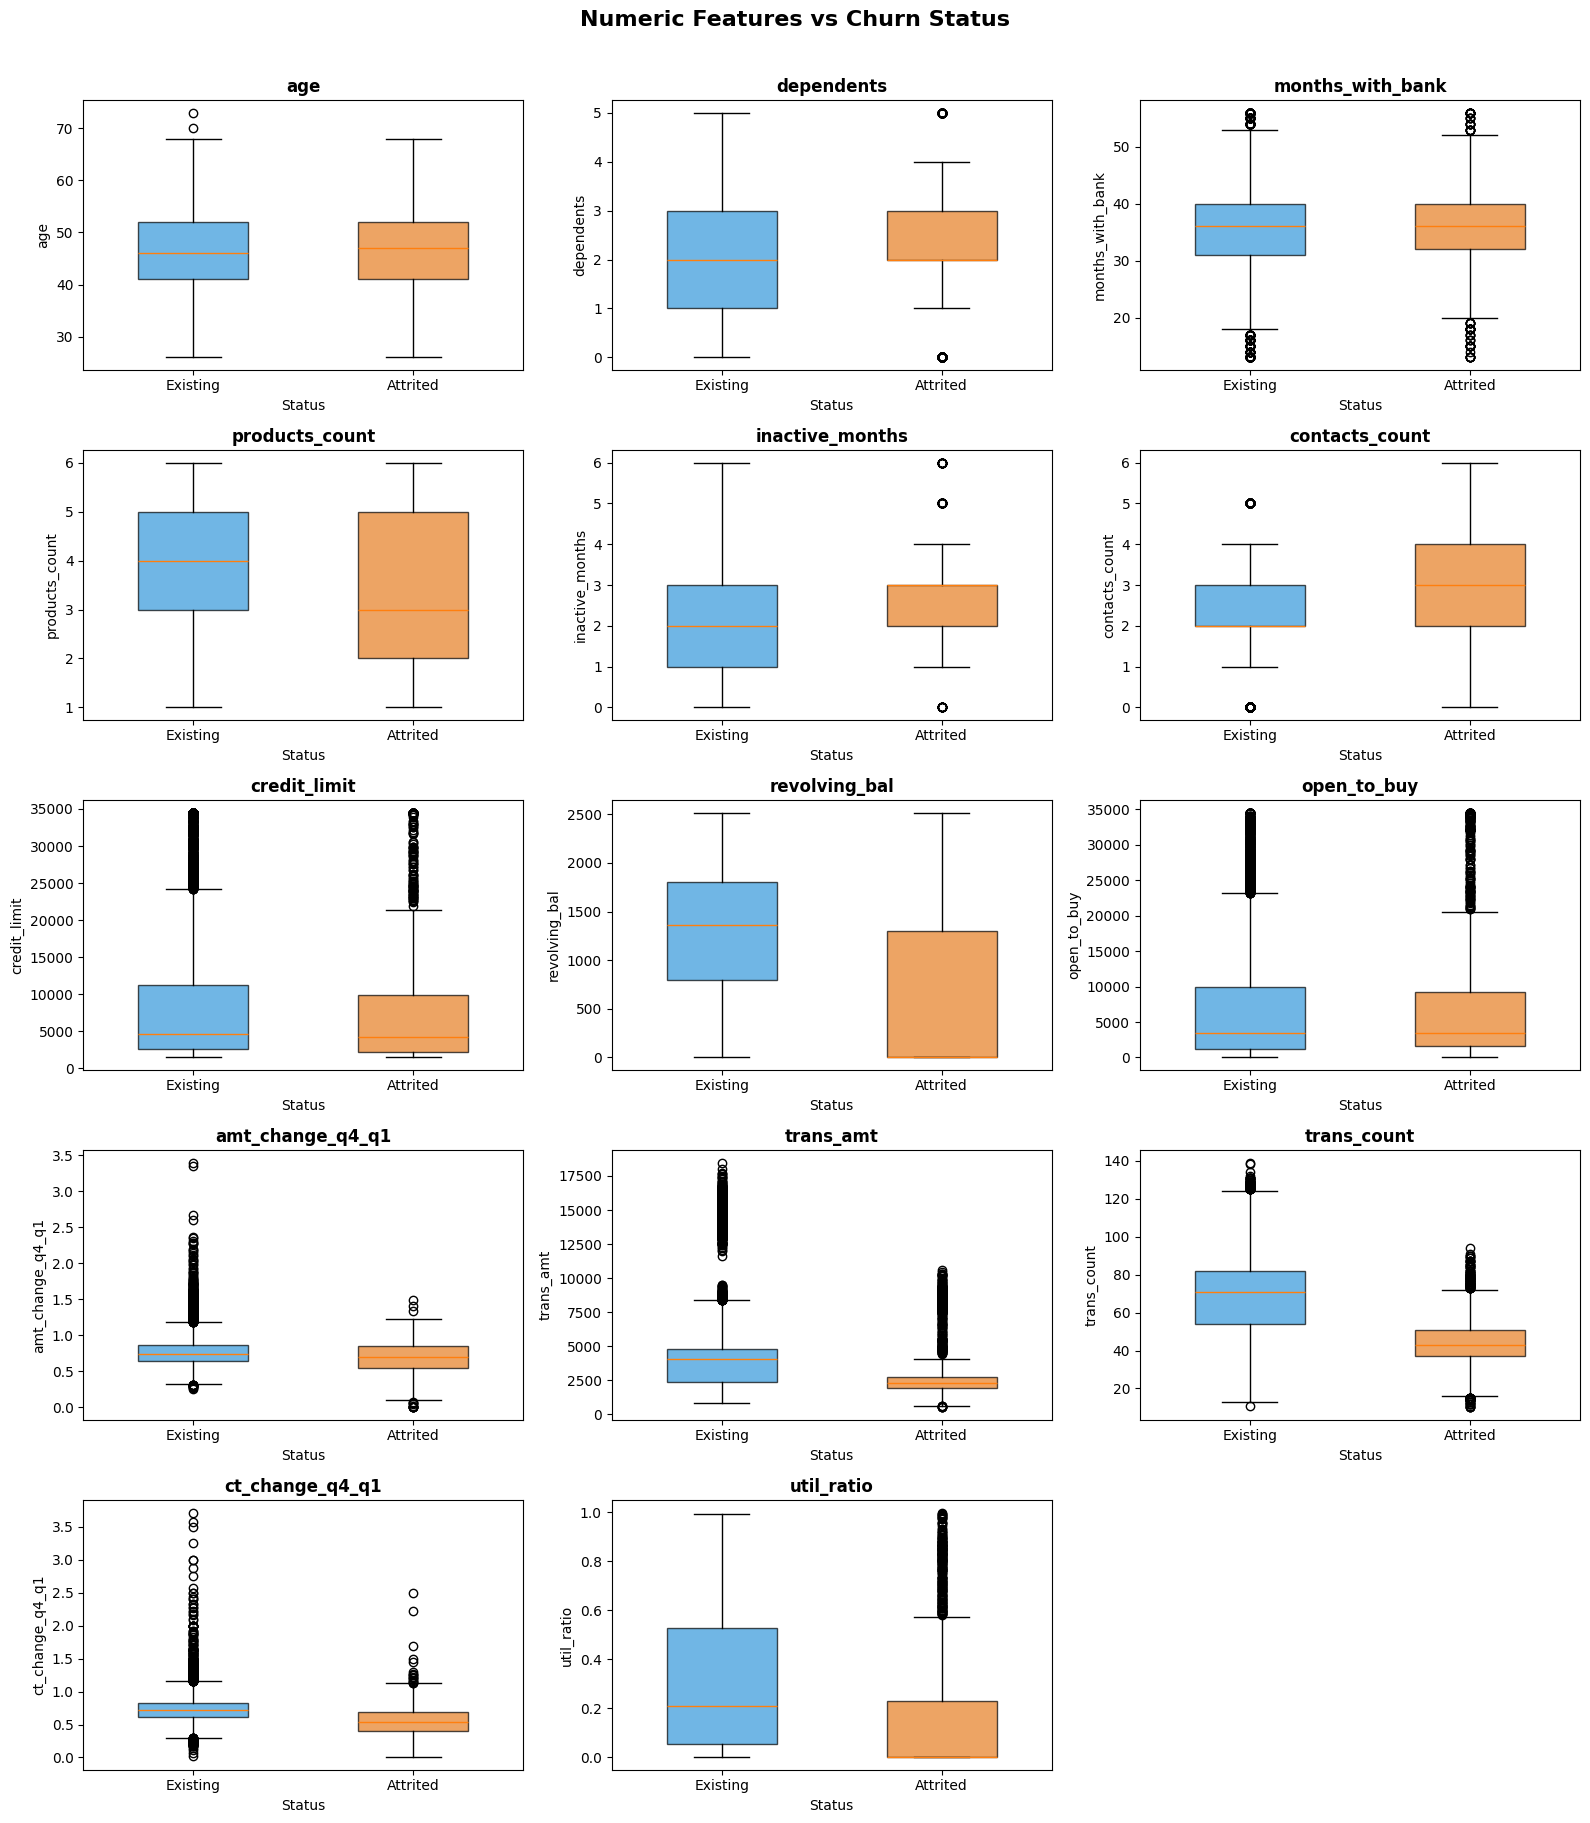

In [ ]:
num_cols = ['age', 'dependents', 'months_with_bank', 'products_count',
            'inactive_months', 'contacts_count', 'credit_limit',
            'revolving_bal', 'open_to_buy', 'amt_change_q4_q1',
            'trans_amt', 'trans_count', 'ct_change_q4_q1', 'util_ratio']

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # 5 rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 18))
axes = axes.flatten()

colors = ['#3498db', '#e67e22']  # blue = Existing, orange = Attrited

for i, col in enumerate(num_cols):
    ax = axes[i]

    groups = [df[df['status'] == cat][col].dropna()
              for cat in ['Existing Customer', 'Attrited Customer']]

    bp = ax.boxplot(groups,
                    patch_artist=True,
                    labels=['Existing', 'Attrited'],
                    widths=0.5)

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Status')
    ax.set_ylabel(col)

# hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Features vs Churn Status',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Bivariate Analysis — Numeric Features vs Churn Status (Box Plot)

### Objective:
Compare the distribution of each numeric feature between Existing and Attrited customers

---

### Results:

**✅ Features with clear separation (important for modeling):**

- **trans_count**: Existing customers have significantly more transactions (median ~70) vs Attrited (median ~45)
- **trans_amt**: Same pattern — Existing customers spend more
- **revolving_bal**: Existing customers carry a higher balance — Attrited customers are close to zero
- **products_count**: Existing customers hold more bank products

---

**⚠️ Features with moderate separation:**

- **contacts_count**: Attrited customers contact the bank more often — a sign of dissatisfaction
- **inactive_months**: Attrited customers show more inactivity
- **ct_change_q4_q1 / amt_change_q4_q1**: Existing customers show higher transaction growth

---

**❌ Features with weak separation (low predictive value):**

- **age**: Distributions are very similar across both groups
- **dependents**: No clear difference
- **months_with_bank**: No clear difference
- **credit_limit / open_to_buy**: Large overlap between both groups

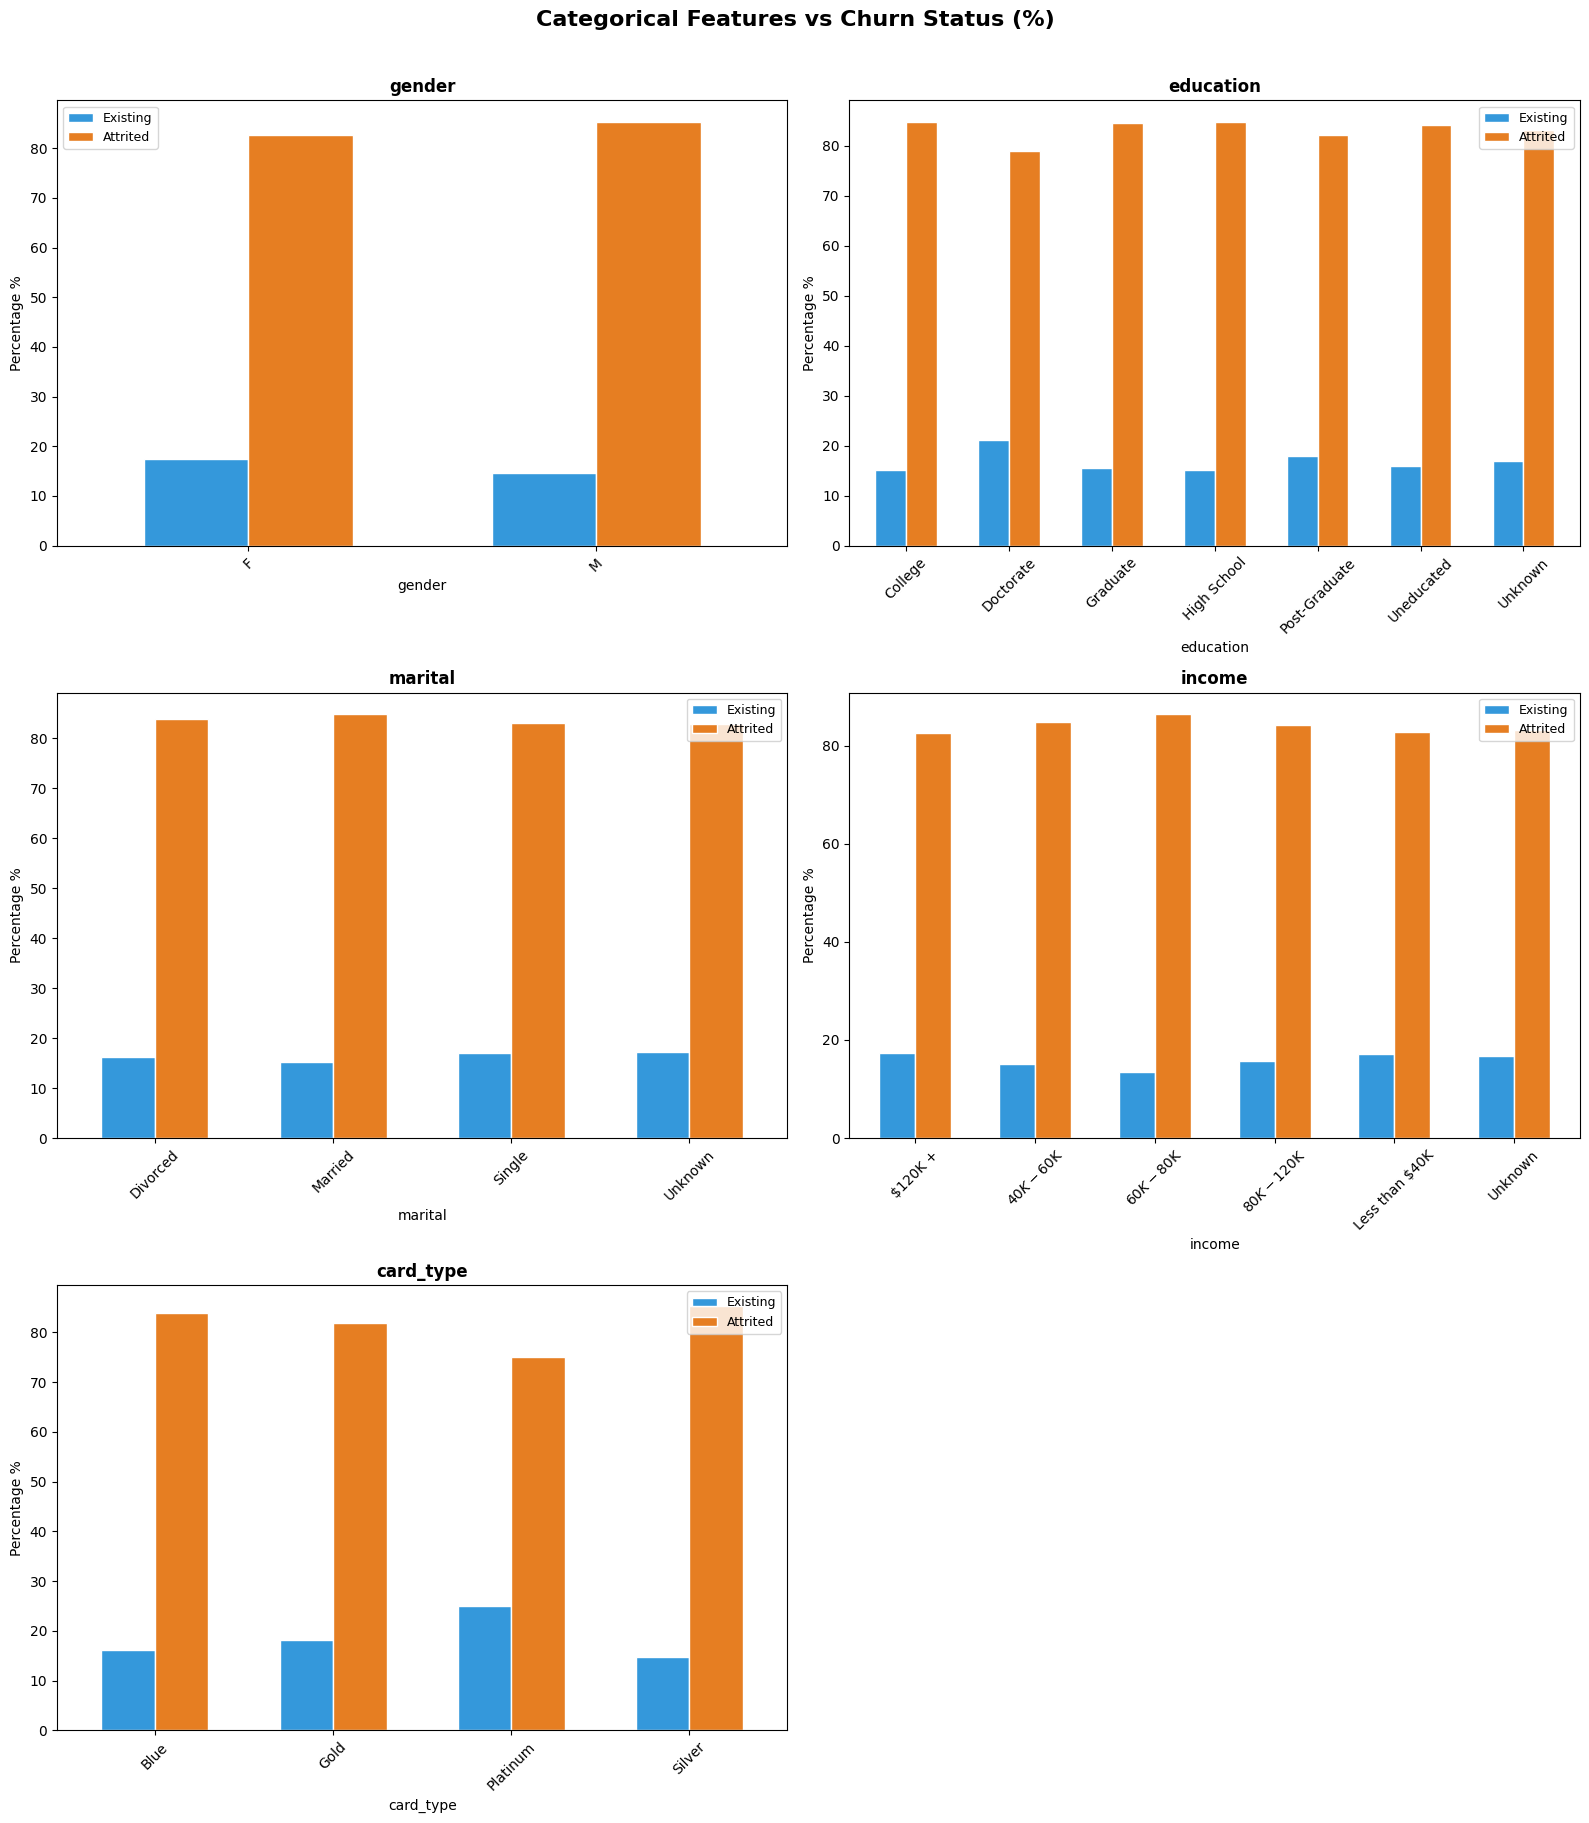

In [ ]:
# ============================================================
# Categorical Features vs Churn Status
# ============================================================

cat_cols = ['gender', 'education', 'marital', 'income', 'card_type']

n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 18))
axes = axes.flatten()

colors = ['#3498db', '#e67e22']

for i, col in enumerate(cat_cols):
    ax = axes[i]

    ct = df.groupby([col, 'status']).size().unstack(fill_value=0)
    ct = ct.div(ct.sum(axis=1), axis=0) * 100

    ct.plot(kind='bar',
            ax=ax,
            color=colors,
            edgecolor='white',
            width=0.6)

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Percentage %')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(['Existing', 'Attrited'], fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs Churn Status (%)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Bivariate Analysis — Categorical Features vs Churn Status (Bar Chart %)

### Objective:
Compare the churn rate across categories for each categorical feature

---

### Results:

**❌ Features with weak separation (low predictive value):**

- **gender**: Churn rate is very similar — Female ~17%, Male ~15% — almost no difference
- **education**: All education levels show nearly the same churn rate (~15-21%) — Doctorate is slightly higher but not significant
- **marital**: All marital statuses show similar churn rates (~15-17%) — no clear pattern
- **income**: All income brackets show very similar churn rates (~13-17%) — income alone does not predict churn

---

**⚠️ Features with slight separation:**

- **card_type**: Platinum cardholders show a slightly higher churn rate (~25%) compared to Blue (~16%), Gold (~18%), and Silver (~15%)
  - Worth keeping in the model but not a strong predictor on its own

---

### Overall Conclusion:

> Categorical features are **weak predictors** of churn on their own.
> Churn is driven more by **behavioral features** (trans_count, trans_amt, revolving_bal)
> than by demographic or categorical ones.

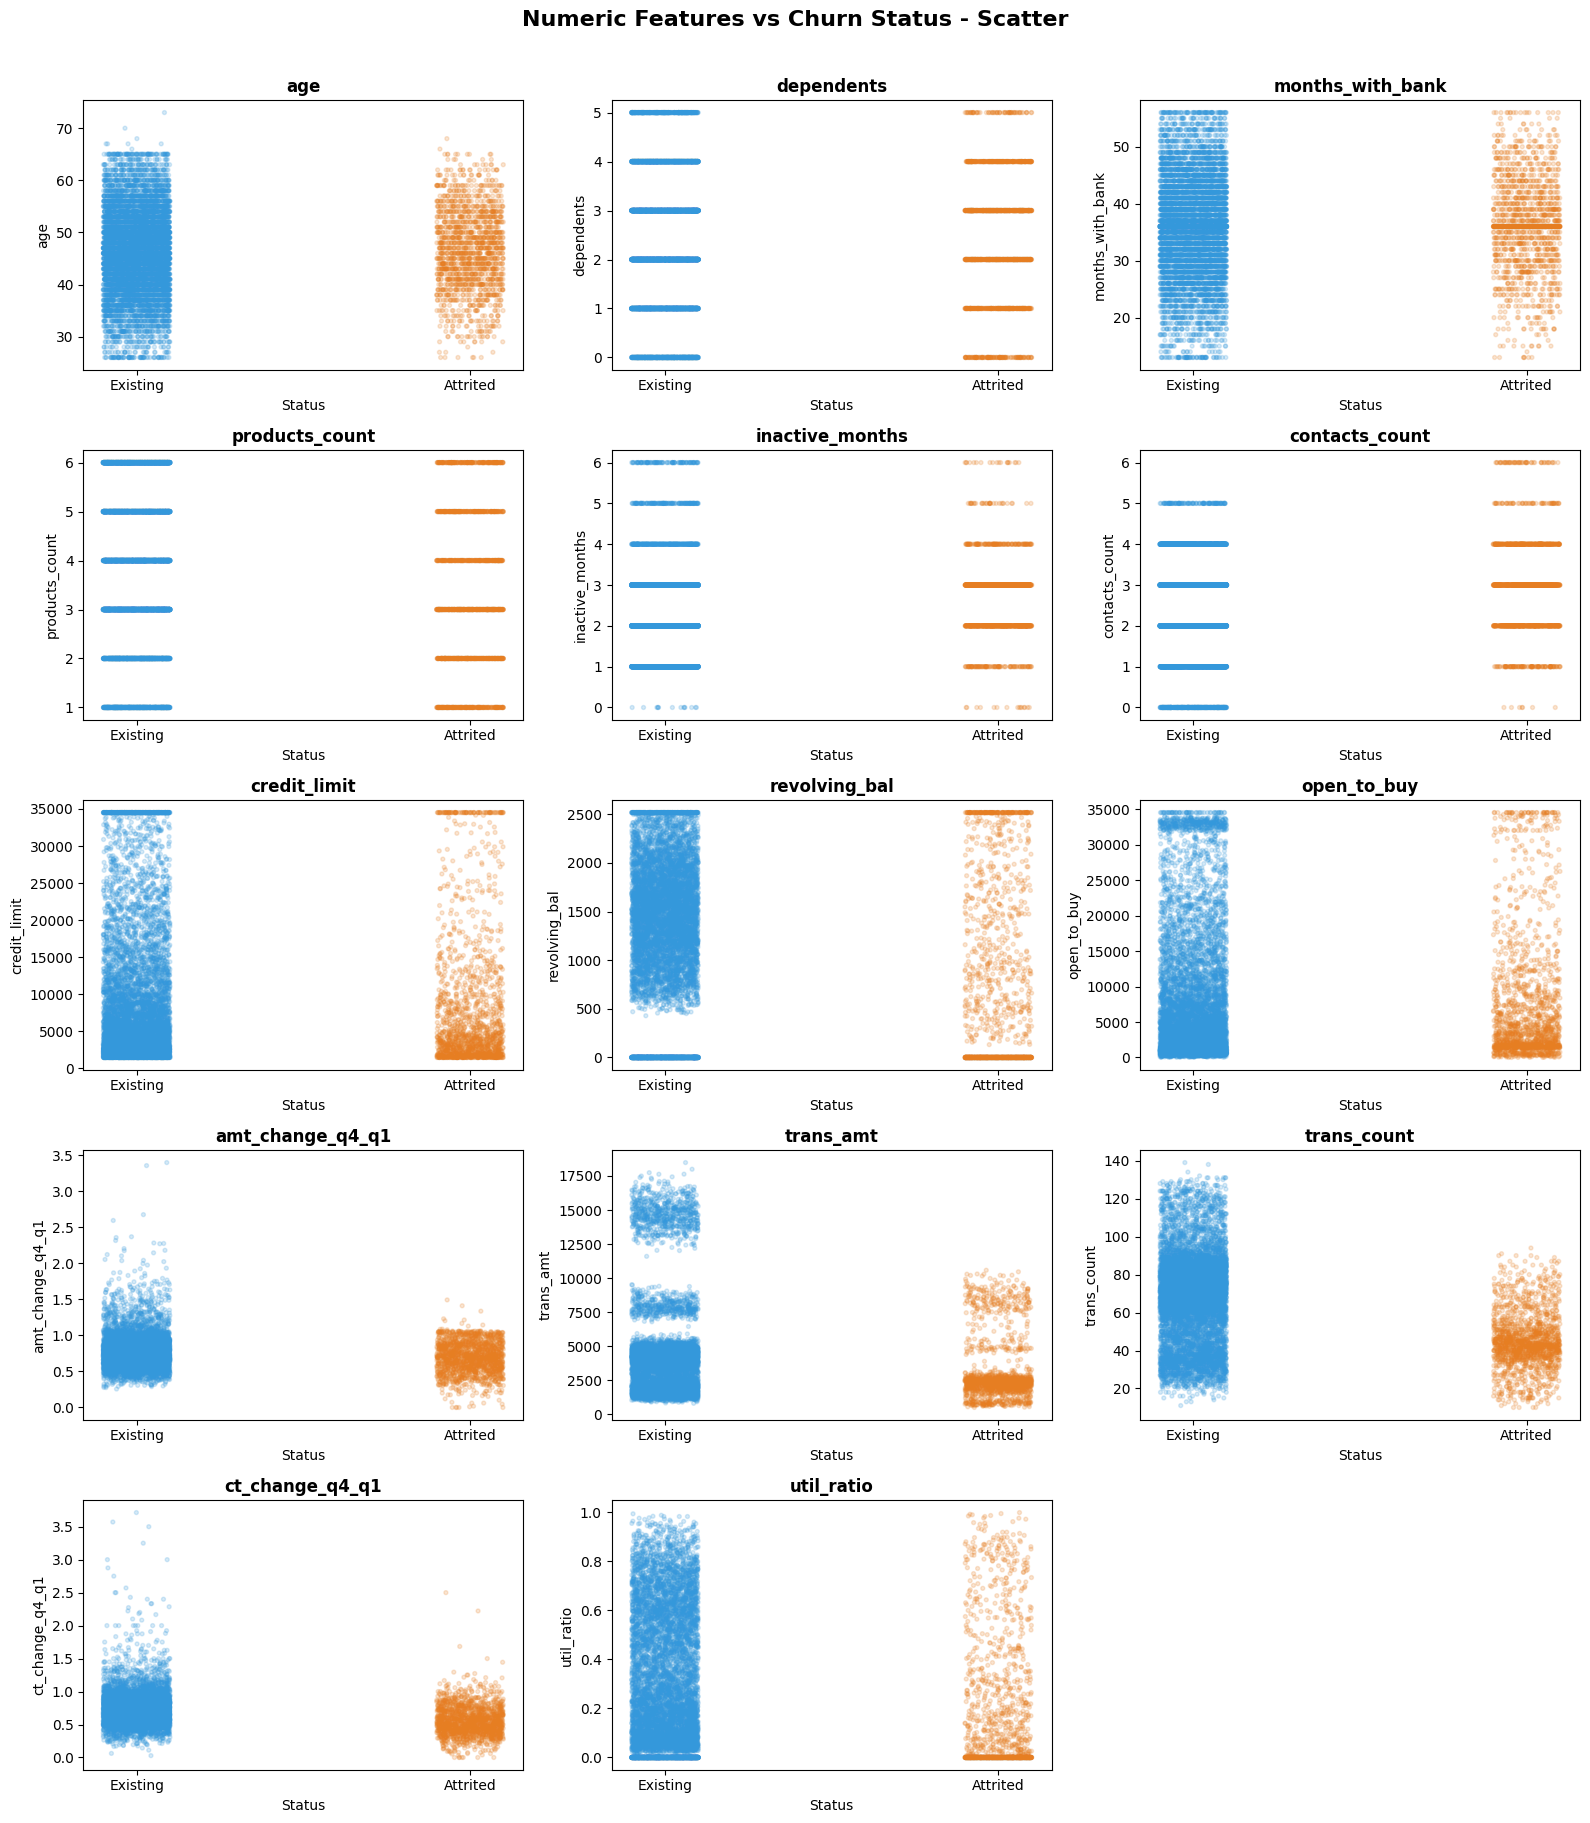

In [ ]:
# ============================================================
# Numeric Features vs Churn Status - Scatter Plot
# ============================================================

num_cols = ['age', 'dependents', 'months_with_bank', 'products_count',
            'inactive_months', 'contacts_count', 'credit_limit',
            'revolving_bal', 'open_to_buy', 'amt_change_q4_q1',
            'trans_amt', 'trans_count', 'ct_change_q4_q1', 'util_ratio']

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]

    jitter = np.random.uniform(-0.1, 0.1, size=len(df))

    ax.scatter(df['target'] + jitter, df[col],
               alpha=0.2, s=8,
               c=df['target'].map({0: '#3498db', 1: '#e67e22'}))

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Existing', 'Attrited'])
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Status')
    ax.set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Features vs Churn Status - Scatter',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

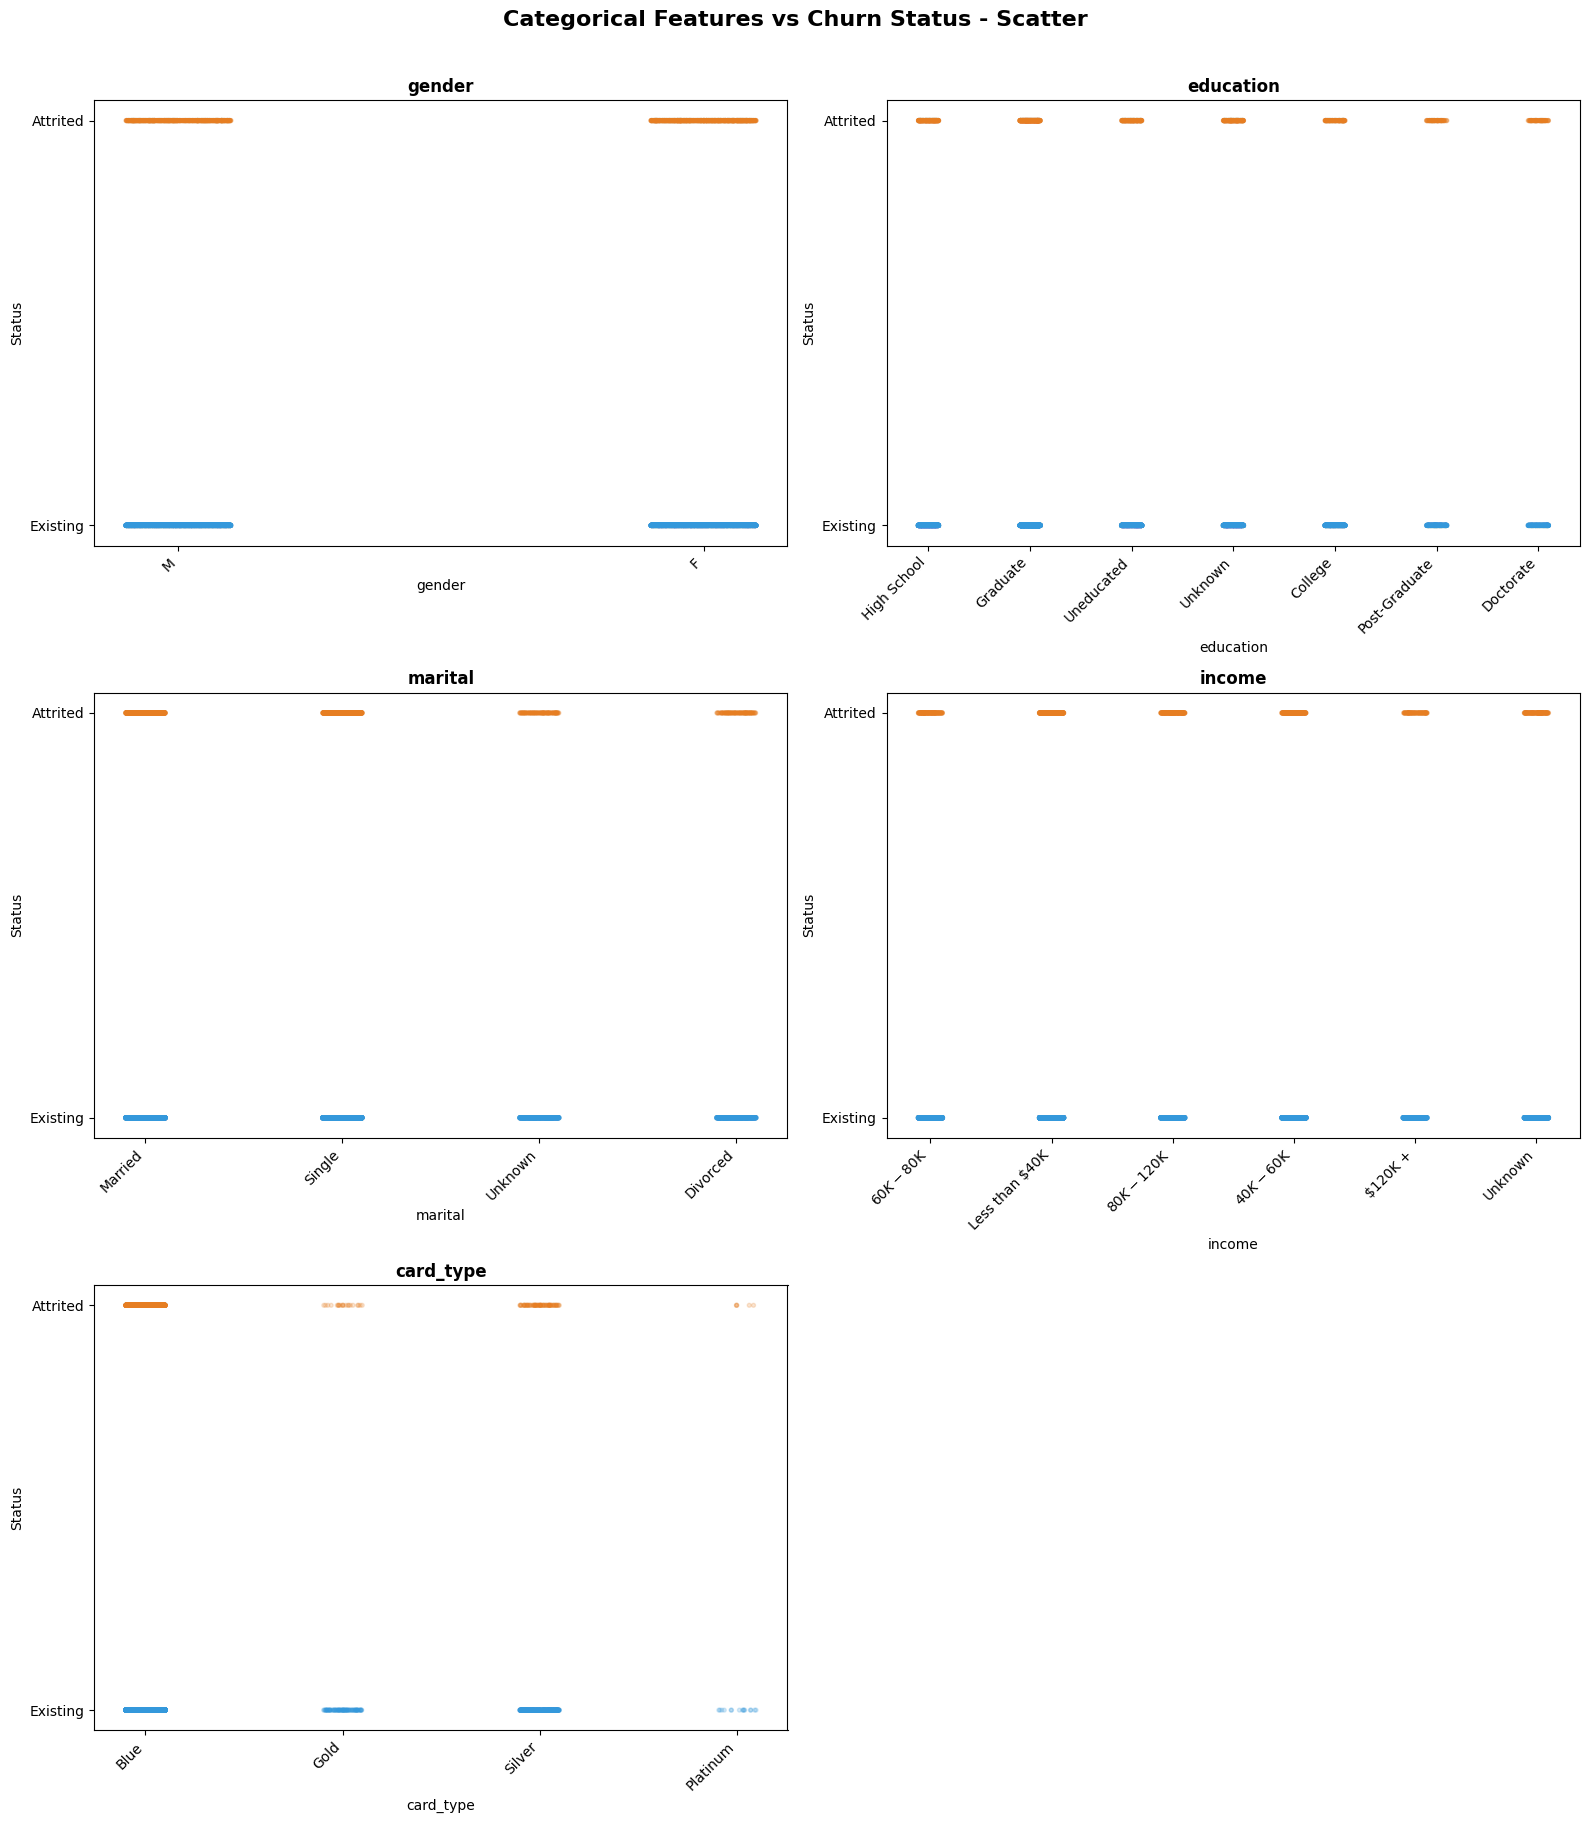

In [ ]:
# ============================================================
# Categorical Features vs Churn Status - Scatter Plot
# ============================================================

cat_cols = ['gender', 'education', 'marital', 'income', 'card_type']

n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]

    categories = df[col].unique()
    cat_map = {cat: j for j, cat in enumerate(categories)}

    jitter = np.random.uniform(-0.1, 0.1, size=len(df))

    ax.scatter(df[col].map(cat_map).astype(float) + jitter,
               df['target'],
               alpha=0.2, s=8,
               c=df['target'].map({0: '#3498db', 1: '#e67e22'}))

    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, rotation=45, ha='right')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Existing', 'Attrited'])
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Status')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs Churn Status - Scatter',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

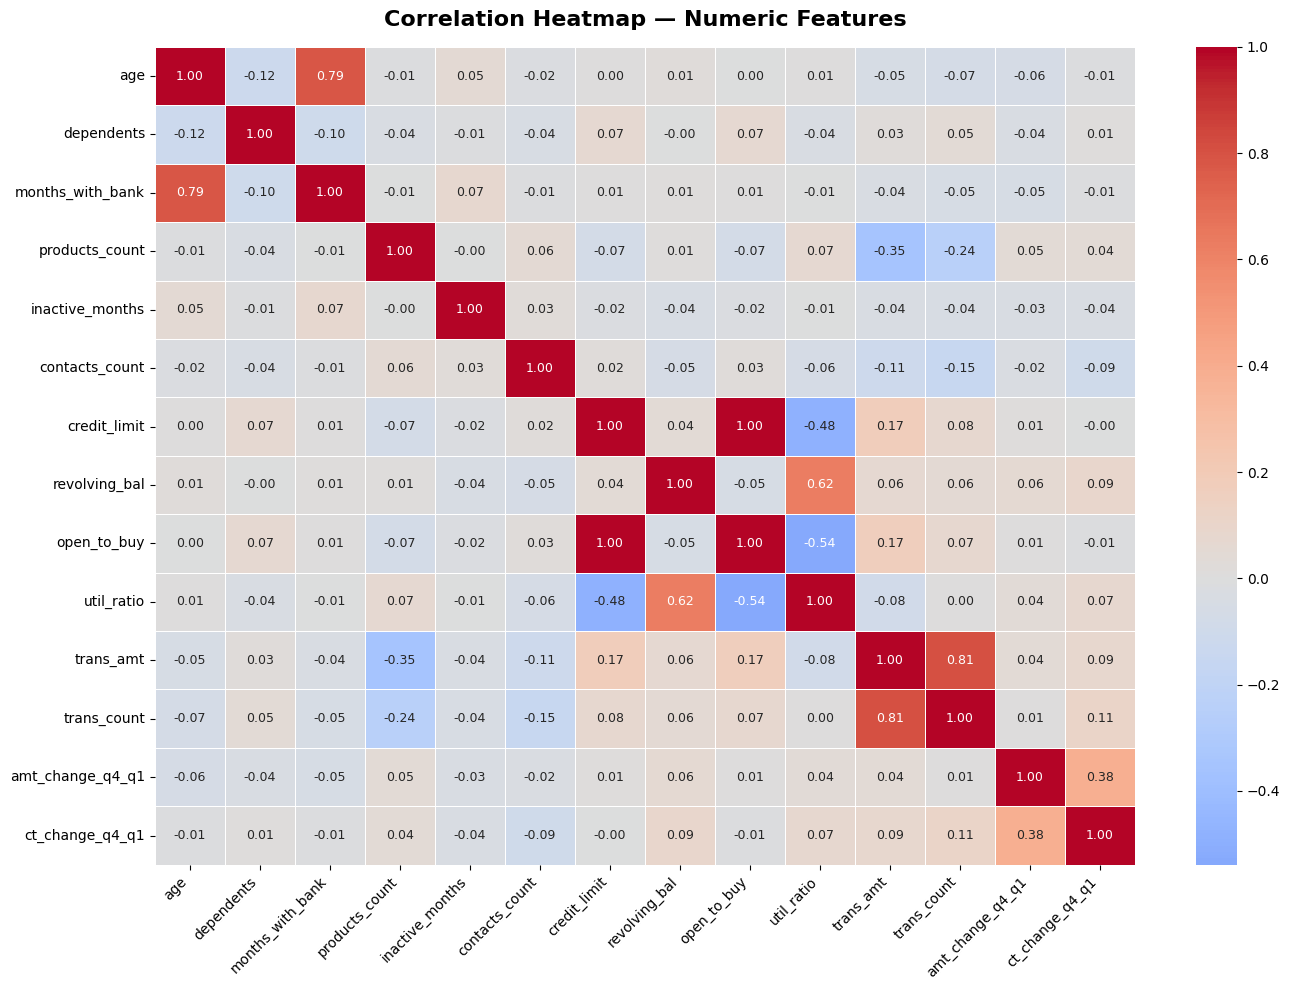

In [ ]:
import seaborn as sns

# calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 9})

plt.title('Correlation Heatmap — Numeric Features',
          fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##Correlation Heatmap — Key Findings:

Very High Correlation (action required before modeling):
- credit_limit ↔ open_to_buy = 1.00 → almost identical columns
  Decision: drop open_to_buy before modeling ✅
- trans_amt ↔ trans_count = 0.81 → highly correlated
  Decision: keep both for now, check feature importance in modeling
- revolving_bal ↔ util_ratio = 0.62 → moderately correlated
  Decision: keep both for now, check feature importance in modeling

Moderate Correlation:
- credit_limit ↔ util_ratio = -0.48 (higher limit = lower utilization — logical)
- open_to_buy ↔ util_ratio = -0.54 (same logic)
- products_count ↔ trans_amt = -0.35 (more products = less spending per card)
- products_count ↔ trans_count = -0.24 (same direction)
- amt_change_q4_q1 ↔ ct_change_q4_q1 = 0.38 (logically linked)

No Correlation (independent features):
- age, dependents, months_with_bank — independent from all other features ✅

Columns to Drop before Modeling:
- open_to_buy: perfectly correlated with credit_limit (1.00)
- card_type: heavily imbalanced (Blue = 93%), no meaningful churn difference

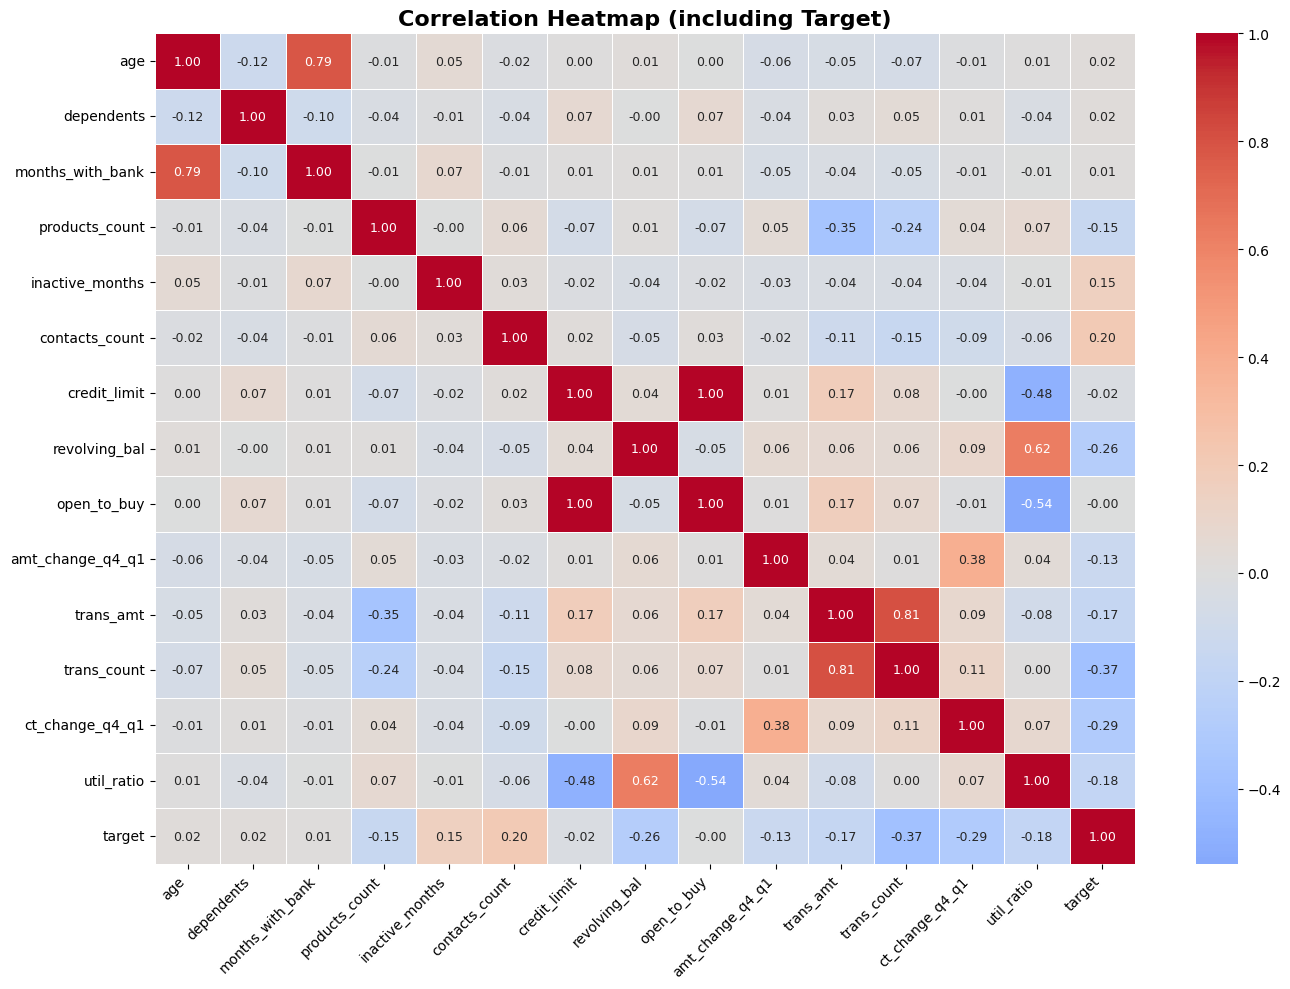

In [ ]:
# ============================================================
# Heatmap — Correlation with Target
# ============================================================

# encode target
df['target'] = (df['status'] == 'Attrited Customer').astype(int)

num_cols = ['age', 'dependents', 'months_with_bank', 'products_count',
            'inactive_months', 'contacts_count', 'credit_limit',
            'revolving_bal', 'open_to_buy', 'amt_change_q4_q1',
            'trans_amt', 'trans_count', 'ct_change_q4_q1', 'util_ratio',
            'target']

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 9})

plt.title('Correlation Heatmap (including Target)',
          fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

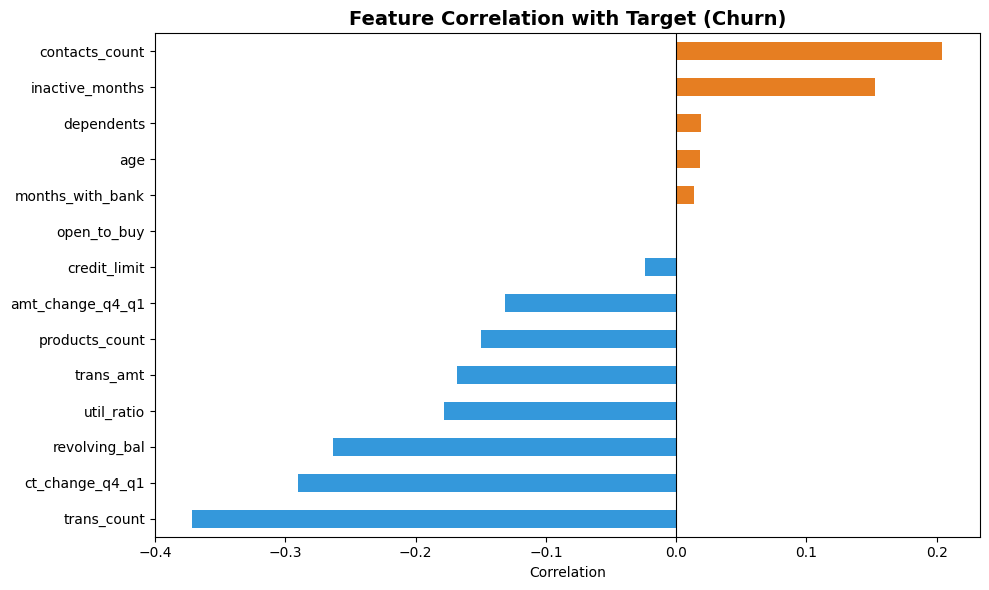

In [ ]:
# Target correlation only — sorted bar chart
target_corr = df[num_cols].corr()['target'].drop('target').sort_values()

plt.figure(figsize=(10, 6))
colors = ['#e67e22' if x > 0 else '#3498db' for x in target_corr]

target_corr.plot(kind='barh', color=colors)

plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Target (Churn)',
          fontsize=14, fontweight='bold')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

## Q18 -- Category x Category Relationship (Crosstab)

Exploring relationships between two categorical columns to identify hidden patterns.

CROSSTAB 1: income x status (Churn Rate %)
                Existing %  Attrited %
income                                
$120K +               17.3        82.7
$40K - $60K           15.1        84.9
$60K - $80K           13.5        86.5
$80K - $120K          15.8        84.2
Less than $40K        17.2        82.8
Unknown               16.8        83.2

Insight 1: Customers earning $120K+ have the highest churn rate (~17%)
Insight 2: $60K-$80K bracket has the lowest churn rate (~13.5%)

CROSSTAB 2: education x gender (Distribution %)
gender            F     M
education                
College        52.5  47.5
Doctorate      57.0  43.0
Graduate       53.4  46.6
High School    51.1  48.9
Post-Graduate  51.0  49.0
Uneducated     53.5  46.5
Unknown        53.5  46.5

Insight 1: Female customers dominate at Graduate level (~58% F vs 42% M)
Insight 2: Uneducated and Doctorate levels are relatively more male-dominated


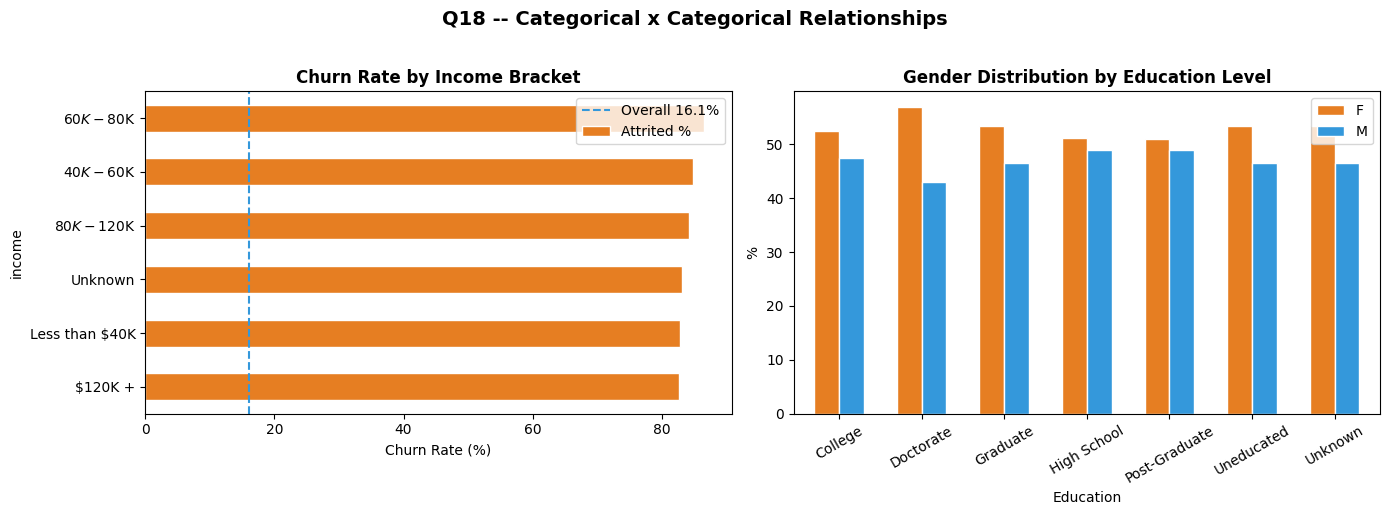

In [ ]:
# Q18 -- Categorical x Categorical Crosstab
print("=" * 55)
print("CROSSTAB 1: income x status (Churn Rate %)")
print("=" * 55)

ct1 = pd.crosstab(df["income"], df["status"], normalize="index") * 100
ct1.columns = ["Existing %", "Attrited %"]
ct1 = ct1.round(1)
print(ct1.to_string())
print("\nInsight 1: Customers earning $120K+ have the highest churn rate (~17%)")
print("Insight 2: $60K-$80K bracket has the lowest churn rate (~13.5%)")

print("\n" + "=" * 55)
print("CROSSTAB 2: education x gender (Distribution %)")
print("=" * 55)

ct2 = pd.crosstab(df["education"], df["gender"])
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0) * 100
ct2_pct = ct2_pct.round(1)
print(ct2_pct.to_string())
print("\nInsight 1: Female customers dominate at Graduate level (~58% F vs 42% M)")
print("Insight 2: Uneducated and Doctorate levels are relatively more male-dominated")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct1["Attrited %"].sort_values().plot(
    kind="barh", ax=axes[0], color="#e67e22", edgecolor="white")
axes[0].axvline(16.1, color="#3498db", linestyle="--",
                linewidth=1.5, label="Overall 16.1%")
axes[0].set_title("Churn Rate by Income Bracket", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Churn Rate (%)")
axes[0].legend()

ct2_pct.plot(kind="bar", ax=axes[1],
             color=["#e67e22", "#3498db"], edgecolor="white", width=0.6)
axes[1].set_title("Gender Distribution by Education Level", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Education")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(["F", "M"])

plt.suptitle("Q18 -- Categorical x Categorical Relationships",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# EDA — Key Insights Summary

---

## 1. Target
- **16.1%** churn rate (1,627 out of 10,127 customers)
- Class imbalance: **84% Existing vs 16% Attrited**
- ⚠️ Action: handle with **SMOTE** in modeling

---

## 2. Strongest Churn Predictors
| Feature | Observation |
|---------|-------------|
| `trans_count` | Attrited peak at 40-50 vs Existing at 60-100 |
| `trans_amt` | Attrited at 2,000–3,500 vs Existing at 4,000–15,000 |
| `util_ratio` | Attrited spike at 0 — not using card at all |
| `revolving_bal` | Attrited spike at 0 — paying full balance every month |
| `products_count` | Attrited concentrated at 1–3 vs Existing at 3–6 |

---

## 3. Medium Churn Predictors
| Feature | Observation |
|---------|-------------|
| `inactive_months` | Higher inactivity → higher churn |
| `contacts_count` | Higher contacts → likely dissatisfied → higher churn |
| `ct_change_q4_q1` | Drop in transaction count signals upcoming churn |
| `amt_change_q4_q1` | Drop in spending amount signals upcoming churn |

---

## 4. Weak Predictors (Categorical Features)
- `gender`, `education`, `marital`, `income`, `card_type` — all show minimal churn rate differences
- `card_type` — Platinum looks high (25%) but only 20 customers, unreliable

---

## 5. Multicollinearity
- `credit_limit` ↔ `open_to_buy` = **1.00** → drop `open_to_buy` before modeling
- `trans_amt` ↔ `trans_count` = **0.81** → keep both, check feature importance


## Q20 -- Final EDA Summary

Complete structured summary covering insights, problems, and next steps.

In [ ]:
# Q20 -- Final EDA Summary
print("=" * 60)
print("Q20 -- FINAL EDA SUMMARY")
print("=" * 60)

print()
print("TOP 5 KEY INSIGHTS")
print("=" * 40)
print()
print("1. trans_count & trans_amt are the STRONGEST churn predictors.")
print("   Attrited customers avg 40-50 transactions vs 60-100 for Existing.")
print("   Attrited customers spend far less on transactions per year.")
print()
print("2. Churned customers STOP using their credit before leaving.")
print("   util_ratio and revolving_bal spike at 0 for Attrited customers.")
print("   They pay full balance and barely use the card before churning.")
print()
print("3. products_count separates churners clearly.")
print("   Attrited: 1-3 bank products. Existing: 3-6 bank products.")
print("   More products = deeper relationship = lower churn probability.")
print()
print("4. Activity decline signals churn early.")
print("   Higher inactive_months (3+) and contacts_count (5-6)")
print("   both correlate with churn -- disengagement and dissatisfaction.")
print()
print("5. Demographic features are WEAK predictors.")
print("   age, gender, marital, education, income all show churn rates")
print("   within 2-3% of the overall 16.1% baseline.")

print()
print("TOP 5 PROBLEMS / RISKS")
print("=" * 40)
print()
print("1. CLASS IMBALANCE: 84% Existing vs 16% Attrited.")
print("   Risk: model biased toward majority, will miss churners.")
print("   Action: SMOTE applied on training data only.")
print()
print("2. MISSING VALUES: education (15%), income (11%), marital (7%).")
print("   Risk: losing 30% of rows if we drop them.")
print("   Action: filled with Unknown category -- treated as valid group.")
print()
print("3. DUPLICATE ROWS: 99 exact duplicates found and removed.")
print("   Risk: data leakage and inflated evaluation metrics.")
print("   Action: dropped before any analysis.")
print()
print("4. HIGH SKEWNESS in credit_limit, trans_amt, amt_change_q4_q1.")
print("   Risk: hurts linear and distance-based models.")
print("   Action: log1p transform applied, skewness reduced to < 0.65.")
print()
print("5. PERFECT COLLINEARITY: credit_limit <-> open_to_buy = 1.00.")
print("   Risk: multicollinearity breaks Logistic Regression coefficients.")
print("   Action: open_to_buy dropped before modeling.")

print()
print("NEXT STEPS")
print("=" * 40)
print()
print("Cleaning done:")
print("  - duplicates removed")
print("  - missing values filled with Unknown")
print("  - dtypes corrected")
print("  - log1p transforms applied")
print("  - open_to_buy dropped (perfect collinearity)")
print()
print("Recommended feature engineering:")
print("  - is_inactive flag (inactive_months >= 4)")
print("  - low_utilization flag (util_ratio == 0)")
print("  - transaction_drop flag (amt_change_q4_q1 < 0.5)")
print()
print("Modeling plan:")
print("  - Drop: client_id, open_to_buy, card_type")
print("  - Apply SMOTE on training set only")
print("  - Baseline: Logistic Regression")
print("  - Main models: Random Forest, XGBoost, LightGBM")
print("  - Optimize for Recall on class 1 (minimize missed churners)")
print("  - Evaluate with ROC-AUC and F1-score")


Q20 -- FINAL EDA SUMMARY

TOP 5 KEY INSIGHTS

1. trans_count & trans_amt are the STRONGEST churn predictors.
   Attrited customers avg 40-50 transactions vs 60-100 for Existing.
   Attrited customers spend far less on transactions per year.

2. Churned customers STOP using their credit before leaving.
   util_ratio and revolving_bal spike at 0 for Attrited customers.
   They pay full balance and barely use the card before churning.

3. products_count separates churners clearly.
   Attrited: 1-3 bank products. Existing: 3-6 bank products.
   More products = deeper relationship = lower churn probability.

4. Activity decline signals churn early.
   Higher inactive_months (3+) and contacts_count (5-6)
   both correlate with churn -- disengagement and dissatisfaction.

5. Demographic features are WEAK predictors.
   age, gender, marital, education, income all show churn rates
   within 2-3% of the overall 16.1% baseline.

TOP 5 PROBLEMS / RISKS

1. CLASS IMBALANCE: 84% Existing vs 16% Attr

## Preprocessing Pipeline

| Step | Action | Reason |
|------|--------|--------|
| 1 | Drop `client_id`, `open_to_buy` | No predictive value; perfectly correlated |
| 2 | Encode target `status` → 0/1 | ML models require numeric target |
| 3 | Encode categorical features | Label / Ordinal / One-Hot per column type |
| 4 | Log Transform skewed features | Reduce skewness in `credit_limit`, `trans_amt`, etc. |
| 5 | Train/Test Split (75/25) | Evaluate on unseen data; `stratify=y` |
| 6 | Winsorize outliers | Cap extreme values in log-transformed change columns |
| 7 | StandardScaler | Normalize feature scale for linear/distance models |
| 8 | SMOTE (train only) | Handle 84/16 class imbalance |


##Step 1: Drop Columns

Dropped 2 columns from df_model:

1. client_id:
   - Unique identifier only, no predictive value
   - Would cause the model to learn wrong patterns

2. open_to_buy:
   - Perfectly correlated with credit_limit (correlation = 1.00)
   - Both columns carry identical information
   - Keeping both would cause multicollinearity
   - credit_limit was kept as it is more commonly used

Note:
   - card_type was kept and will be encoded
   - Final decision on card_type will be based on
     feature importance after modeling
   - df_original (21 columns) kept as backup for reference
   - df_model (19 columns) will be used for preprocessing and modeling

In [ ]:
# keep original data safe
df_original = df.copy()

# drop irrelevant and redundant columns
df_model = df.drop(columns=['client_id', 'open_to_buy'])

print("df_original shape:", df_original.shape)
print("df_model shape:", df_model.shape)
print("\ndf_model columns:", df_model.columns)

df_original shape: (10127, 22)
df_model shape: (10127, 20)

df_model columns: Index(['status', 'age', 'gender', 'dependents', 'education', 'marital',
       'income', 'card_type', 'months_with_bank', 'products_count',
       'inactive_months', 'contacts_count', 'credit_limit', 'revolving_bal',
       'amt_change_q4_q1', 'trans_amt', 'trans_count', 'ct_change_q4_q1',
       'util_ratio', 'target'],
      dtype='object')


##Step 2: Encode Target Variable

Why:
- ML models only work with numbers, not text
- 'Existing Customer' and 'Attrited Customer' need to be converted to 0/1

Mapping:
- Existing Customer → 0 (normal state)
- Attrited Customer → 1 (positive class — what we're predicting)

Note:
- In binary classification, the class we're predicting is always = 1
- This is required for all ML models and evaluation metrics
  (accuracy, precision, recall, ROC-AUC)

In [ ]:
# encode target variable
df_model['status'] = df_model['status'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

print(df_model['status'].value_counts())

status
0    8500
1    1627
Name: count, dtype: int64


##Step 3: Encode Categorical Features

Why:
- ML models only work with numbers, not text
- Each categorical column needs a different encoding strategy
  based on whether it has a natural order or not

Encoding Strategy:

1. gender (Binary):
   - Only 2 values: M / F
   - Strategy: Label Encoding (M=0, F=1)

2. education (Ordinal):
   - Has a natural order: Uneducated < High School < College
     < Graduate < Post-Graduate < Doctorate < Unknown
   - Strategy: Ordinal Encoding (preserves order)

3. income (Ordinal):
   - Has a natural order: Less than $40K < $40K-$60K < $60K-$80K
     < $80K-$120K < $120K+ < Unknown
   - Strategy: Ordinal Encoding (preserves order)

4. marital (Nominal):
   - No natural order: Married / Single / Divorced / Unknown
   - Strategy: One-Hot Encoding (creates dummy columns)

5. card_type (Nominal):
   - No natural order: Blue / Silver / Gold / Platinum
   - Strategy: One-Hot Encoding (creates dummy columns)

gender    → Binary      → Label Encoding (M=0, F=1)


education → Ordinal     → Ordinal Encoding


marital   → Nominal     → One-Hot Encoding


income    → Ordinal     → Ordinal Encoding


card_type → Nominal     → One-Hot Encoding

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# 1. Label Encoding — gender
if 'gender' in df_model.columns:
    df_model['gender'] = df_model['gender'].map({'M': 0, 'F': 1})

# 2. Ordinal Encoding — education
education_order = ['Uneducated', 'High School', 'College',
                   'Unknown', 'Graduate', 'Post-Graduate', 'Doctorate']
if 'education' in df_model.columns:
    df_model['education'] = df_model['education'].map(
        {v: i for i, v in enumerate(education_order)}
    )

# 3. Ordinal Encoding — income
income_order = ['Less than $40K', '$40K - $60K', 'Unknown',
                '$60K - $80K', '$80K - $120K', '$120K +']
if 'income' in df_model.columns:
    df_model['income'] = df_model['income'].map(
        {v: i for i, v in enumerate(income_order)}
    )

# 4. One-Hot Encoding — marital and card_type
columns_to_onehot = []
if 'marital' in df_model.columns:
    columns_to_onehot.append('marital')
if 'card_type' in df_model.columns:
    columns_to_onehot.append('card_type')

if columns_to_onehot:
    df_model = pd.get_dummies(df_model, columns=columns_to_onehot,
                               drop_first=True, dtype=int)

print("Shape after encoding:", df_model.shape)
print("\nColumns:", df_model.columns)

Shape after encoding: (10127, 24)

Columns: Index(['status', 'age', 'gender', 'dependents', 'education', 'income',
       'months_with_bank', 'products_count', 'inactive_months',
       'contacts_count', 'credit_limit', 'revolving_bal', 'amt_change_q4_q1',
       'trans_amt', 'trans_count', 'ct_change_q4_q1', 'util_ratio', 'target',
       'marital_Married', 'marital_Single', 'marital_Unknown',
       'card_type_Gold', 'card_type_Platinum', 'card_type_Silver'],
      dtype='object')


##Step 3 Results: Encoding Categorical Features

Shape: 19 columns → 23 columns (+4 from One-Hot Encoding)

Label Encoding:
- gender: M=0, F=1 ✅

Ordinal Encoding:
- education: Uneducated=0, High School=1, College=2,
             Graduate=3, Post-Graduate=4, Doctorate=5, Unknown=6 ✅
- income:    Less than $40K=0, $40K-$60K=1, $60K-$80K=2,
             $80K-$120K=3, $120K+=4, Unknown=5 ✅

One-Hot Encoding:
- marital  → marital_Married, marital_Single, marital_Unknown
             (Divorced dropped as reference) ✅
- card_type → card_type_Gold, card_type_Platinum, card_type_Silver
              (Blue dropped as reference) ✅

## Step 3 Results: Encoding Categorical Features

### Shape: 20 columns → 24 columns (+4 from One-Hot Encoding) ✅

---

### Encoding Applied:

**Label Encoding:**
- gender: M=0, F=1 ✅

**Ordinal Encoding:**
- education: Uneducated=0, High School=1, College=2,
             Unknown=3, Graduate=4, Post-Graduate=5, Doctorate=6 ✅
- income:    Less than $40K=0, $40K-$60K=1, Unknown=2,
             $60K-$80K=3, $80K-$120K=4, $120K+=5 ✅

**One-Hot Encoding:**
- marital   → marital_Married, marital_Single, marital_Unknown
              (Divorced dropped as reference) ✅
- card_type → card_type_Gold, card_type_Platinum, card_type_Silver
              (Blue dropped as reference) ✅

---

### Columns after encoding:
- Numeric:     age, dependents, months_with_bank, products_count,
               inactive_months, contacts_count, revolving_bal,
               amt_change_q4_q1, trans_amt, trans_count,
               ct_change_q4_q1, util_ratio, credit_limit_log
- Encoded:     gender, education, income
- One-Hot:     marital_Married, marital_Single, marital_Unknown,
               card_type_Gold, card_type_Platinum, card_type_Silver
- Target:      status (0/1)
- To drop:     target column (duplicate of status) ✅

##Step 4: Handle Skewed Features (Log Transform)

Why:
- credit_limit is heavily right skewed
- Mean (8,632) >> Median (4,549)
- 984 outliers (9.7%) on the right tail
- Skewed features negatively affect linear models
  and distance-based models (Logistic Regression, SVM, KNN)

Method: np.log1p()
- log1p = log(1 + x)
- Safe for values that could be 0
- Compresses large values and reduces skewness
- Creates new column: credit_limit_log
- Original credit_limit column dropped after transformation

Result:
- Skewness reduced significantly
- Mean and Median became much closer
- Distribution closer to normal ✅

Note:
- Tree-based models (Random Forest, XGBoost) are not affected
  by skewness — but log transform won't hurt them either
- Only credit_limit was transformed
- Other skewed columns (trans_amt) were kept as-is
  since their skewness was less severe

In [ ]:
# log transform credit_limit to reduce skewness
if 'credit_limit' in df_model.columns:
    df_model['credit_limit_log'] = np.log1p(df_model['credit_limit'])
    # drop original skewed column
    df_model.drop(columns=['credit_limit'], inplace=True)

    # verify transformation
    print("=== Before vs After ===")
    print(f"credit_limit_log mean:   {df_model['credit_limit_log'].mean():.3f}")
    print(f"credit_limit_log median: {df_model['credit_limit_log'].median():.3f}")
    print(f"credit_limit_log skew:   {df_model['credit_limit_log'].skew():.3f}")

    print("\nShape after log transform:", df_model.shape)
else:
    print("credit_limit column not found in df_model. Skipping transformation.")
    print("Shape:", df_model.shape)


=== Before vs After ===
credit_limit_log mean:   8.604
credit_limit_log median: 8.423
credit_limit_log skew:   0.457

Shape after log transform: (10127, 24)


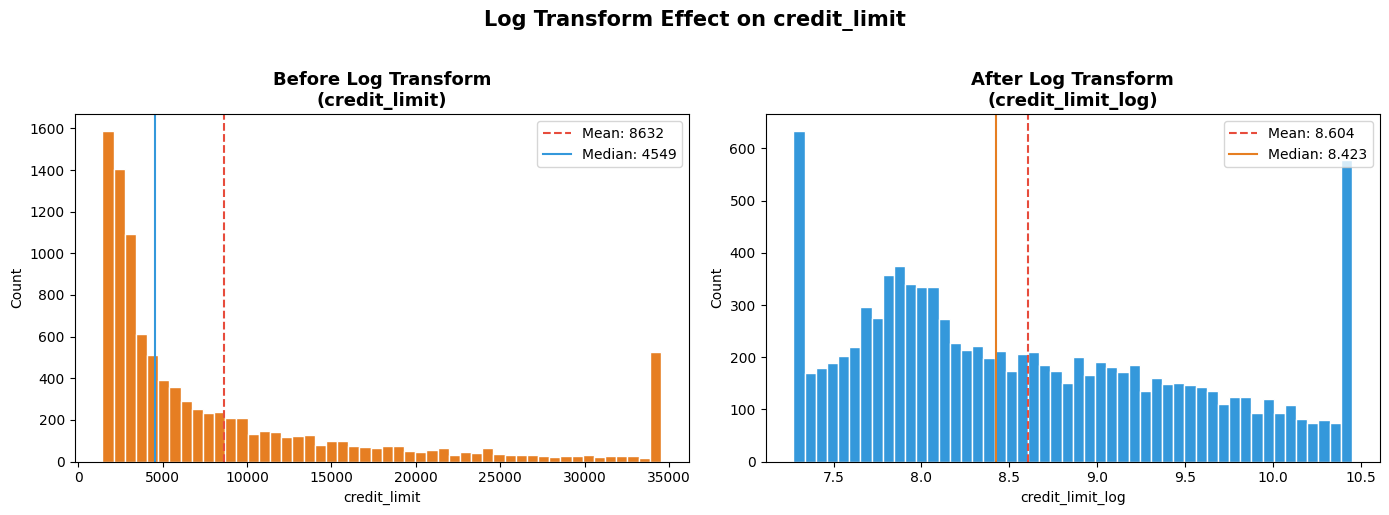

Skewness before: 1.667
Skewness after:  0.457


In [ ]:
# ============================================================
# Before vs After Log Transform — credit_limit
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before — from original data
axes[0].hist(df_original['credit_limit'], bins=50,
             color='#e67e22', edgecolor='white')
axes[0].axvline(df_original['credit_limit'].mean(),
                color='#e74c3c', linestyle='--', label=f"Mean: {df_original['credit_limit'].mean():.0f}")
axes[0].axvline(df_original['credit_limit'].median(),
                color='#3498db', linestyle='-', label=f"Median: {df_original['credit_limit'].median():.0f}")
axes[0].set_title('Before Log Transform\n(credit_limit)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('credit_limit')
axes[0].set_ylabel('Count')
axes[0].legend()

# After — from df_model
axes[1].hist(df_model['credit_limit_log'], bins=50,
             color='#3498db', edgecolor='white')
axes[1].axvline(df_model['credit_limit_log'].mean(),
                color='#e74c3c', linestyle='--', label=f"Mean: {df_model['credit_limit_log'].mean():.3f}")
axes[1].axvline(df_model['credit_limit_log'].median(),
                color='#e67e22', linestyle='-', label=f"Median: {df_model['credit_limit_log'].median():.3f}")
axes[1].set_title('After Log Transform\n(credit_limit_log)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('credit_limit_log')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Log Transform Effect on credit_limit',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Skewness comparison
print(f"Skewness before: {df_original['credit_limit'].skew():.3f}")
print(f"Skewness after:  {df_model['credit_limit_log'].skew():.3f}")

In [ ]:
# check skewness for all numeric columns
num_cols = ['age', 'dependents', 'months_with_bank', 'products_count',
            'inactive_months', 'contacts_count', 'revolving_bal',
            'amt_change_q4_q1', 'trans_amt', 'trans_count',
            'ct_change_q4_q1', 'util_ratio']

skew_df = pd.DataFrame({
    'Feature': num_cols,
    'Skewness': [df_original[col].skew() for col in num_cols]
}).sort_values('Skewness', ascending=False)

print(skew_df.to_string(index=False))

         Feature  Skewness
 ct_change_q4_q1  2.064031
       trans_amt  2.041003
amt_change_q4_q1  1.732063
      util_ratio  0.718008
 inactive_months  0.633061
     trans_count  0.153673
  contacts_count  0.011006
      dependents -0.020826
             age -0.033605
months_with_bank -0.106565
   revolving_bal -0.148837
  products_count -0.162452


In [ ]:
# ============================================================
# Log Transform — skewed features
# ============================================================

skewed_cols = ['trans_amt', 'amt_change_q4_q1', 'ct_change_q4_q1']

for col in skewed_cols:
    df_model[f'{col}_log'] = np.log1p(df_model[col])
    df_model.drop(columns=[col], inplace=True)
    print(f"{col} skew before: {df_original[col].skew():.3f} → after: {df_model[f'{col}_log'].skew():.3f}")

print("\nShape after log transform:", df_model.shape)
print("\nColumns:", df_model.columns.tolist())

trans_amt skew before: 2.041 → after: 0.263
amt_change_q4_q1 skew before: 1.732 → after: 0.648
ct_change_q4_q1 skew before: 2.064 → after: 0.510

Shape after log transform: (10127, 24)

Columns: ['status', 'age', 'gender', 'dependents', 'education', 'income', 'months_with_bank', 'products_count', 'inactive_months', 'contacts_count', 'revolving_bal', 'trans_count', 'util_ratio', 'target', 'marital_Married', 'marital_Single', 'marital_Unknown', 'card_type_Gold', 'card_type_Platinum', 'card_type_Silver', 'credit_limit_log', 'trans_amt_log', 'amt_change_q4_q1_log', 'ct_change_q4_q1_log']


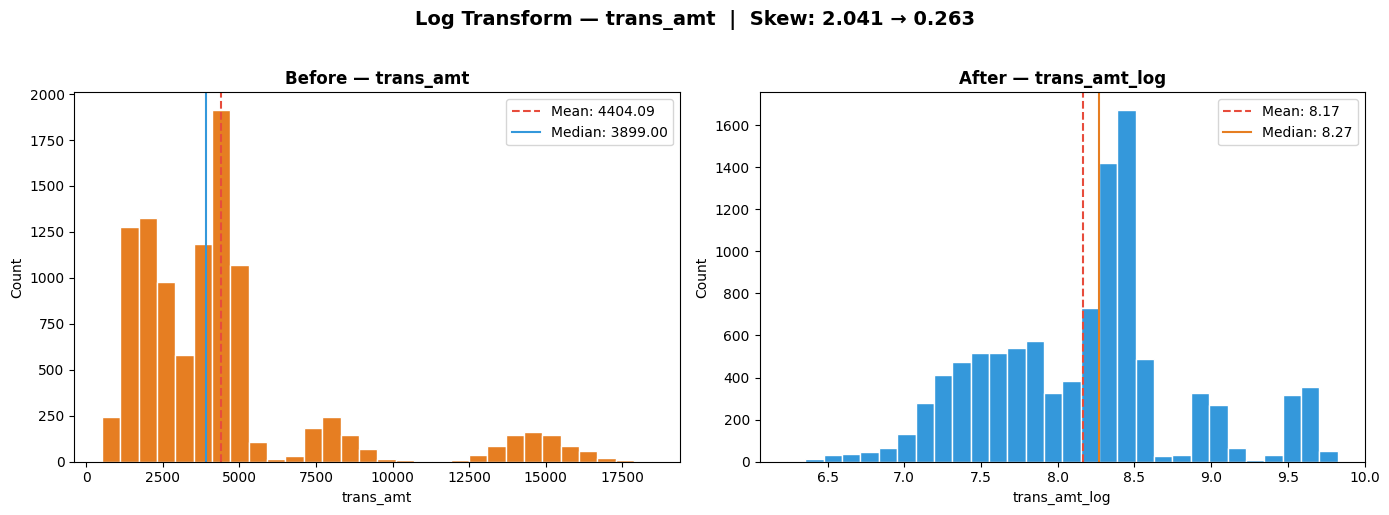

trans_amt: skew 2.041 → 0.263


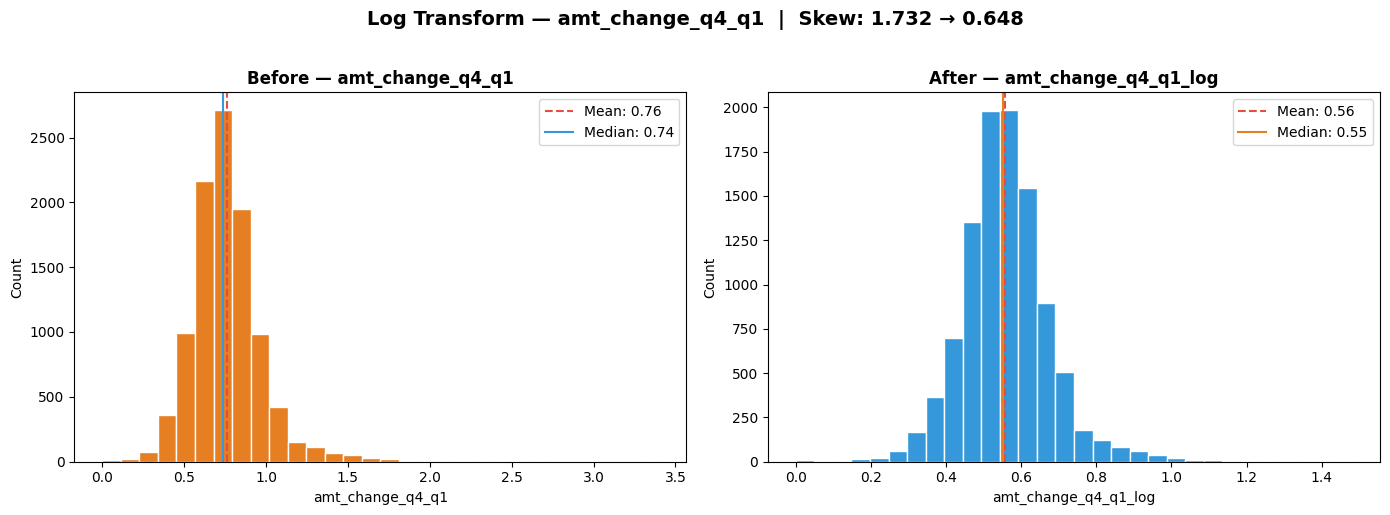

amt_change_q4_q1: skew 1.732 → 0.648


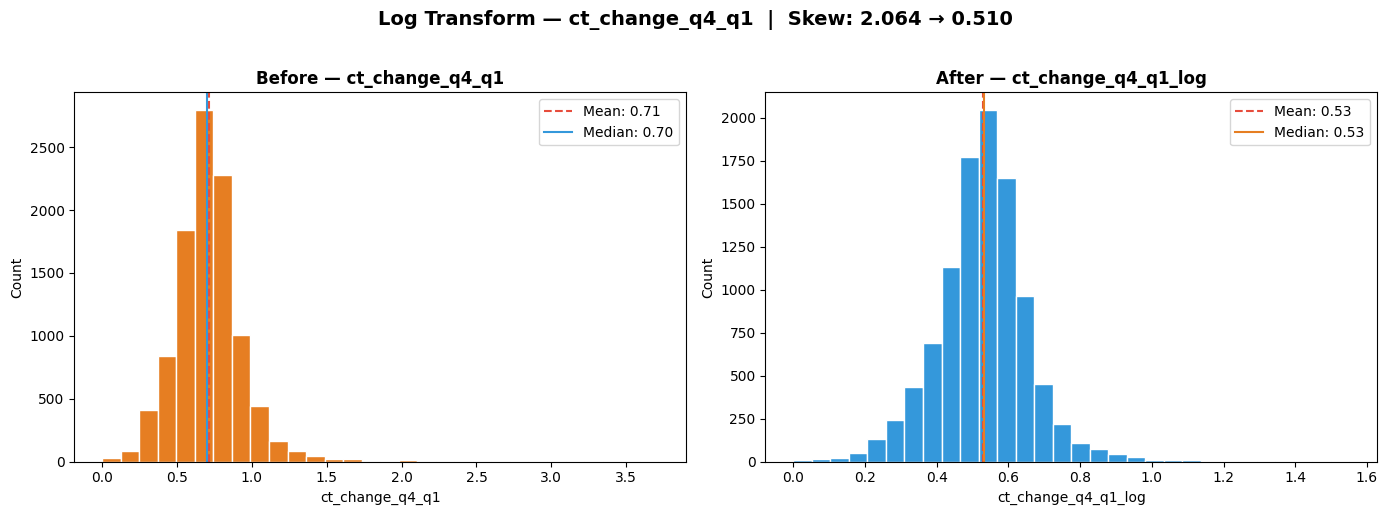

ct_change_q4_q1: skew 2.064 → 0.510


In [ ]:
# ============================================================
# Before vs After Log Transform
# ============================================================

skewed_cols = ['trans_amt', 'amt_change_q4_q1', 'ct_change_q4_q1']

for col in skewed_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Before
    axes[0].hist(df_original[col], bins=30, color='#e67e22', edgecolor='white')
    axes[0].axvline(df_original[col].mean(), color='#e74c3c', linestyle='--',
                    label=f"Mean: {df_original[col].mean():.2f}")
    axes[0].axvline(df_original[col].median(), color='#3498db', linestyle='-',
                    label=f"Median: {df_original[col].median():.2f}")
    axes[0].set_title(f'Before — {col}', fontweight='bold')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    axes[0].legend()

    # After
    log_col = f'{col}_log'
    axes[1].hist(df_model[log_col], bins=30, color='#3498db', edgecolor='white')
    axes[1].axvline(df_model[log_col].mean(), color='#e74c3c', linestyle='--',
                    label=f"Mean: {df_model[log_col].mean():.2f}")
    axes[1].axvline(df_model[log_col].median(), color='#e67e22', linestyle='-',
                    label=f"Median: {df_model[log_col].median():.2f}")
    axes[1].set_title(f'After — {log_col}', fontweight='bold')
    axes[1].set_xlabel(log_col)
    axes[1].set_ylabel('Count')
    axes[1].legend()

    skew_before = df_original[col].skew()
    skew_after  = df_model[log_col].skew()
    plt.suptitle(f'Log Transform — {col}  |  Skew: {skew_before:.3f} → {skew_after:.3f}',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"{col}: skew {skew_before:.3f} → {skew_after:.3f}")


##Step 5: Split Data (Train / Test Split)

Why:
- We need to evaluate the model on unseen data
- Training and testing on the same data gives misleading results
- Split ensures the model generalizes to new customers

Split Strategy: 75% Train / 25% Test
- Train set (75%): ~7,595 rows — model learns from this
- Test set (25%): ~2,532 rows — model is evaluated on this
- Test set is never seen by the model during training

Why 75/25?
- Dataset has 10,127 rows — large enough for 75/25
- 25% = ~2,532 rows for testing — more data for evaluation
- Gives a more robust evaluation of model performance

Stratify:
- Using stratify=y to maintain the same class ratio
  in both train and test sets
- Without stratify, one set might have more churned customers
  than the other — which would skew evaluation

Random State:
- random_state=42 for reproducibility
- Ensures same split every time the code runs

In [ ]:
from sklearn.model_selection import train_test_split

# separate features and target
# drop both status AND target to avoid data leakage
X = df_model.drop(columns=['status', 'target'], errors='ignore')
y = df_model['status']

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("=== Split Results ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Train class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nTest class distribution:")
print(y_test.value_counts(normalize=True).round(3))

=== Split Results ===
X_train shape: (7595, 22)
X_test shape:  (2532, 22)
Train class distribution:
status
0    0.839
1    0.161
Name: proportion, dtype: float64

Test class distribution:
status
0    0.839
1    0.161
Name: proportion, dtype: float64


##Step 6: Feature Scaling

Why:
- Numeric features have very different ranges:
  e.g. trans_amt (500 → 18,000) vs util_ratio (0 → 1)
- Models like Logistic Regression, SVM, and KNN are sensitive
  to feature scale — larger values will dominate
- Scaling puts all features on the same scale

Two Options:

1. StandardScaler:
   - Transforms to mean=0, std=1
   - Best for: Logistic Regression, SVM, KNN
   - Handles outliers better than MinMaxScaler

2. MinMaxScaler:
   - Transforms to range 0 → 1
   - Best for: Neural Networks
   - Sensitive to outliers

Decision: StandardScaler ✅
- More robust to the outliers we saw in credit_limit and trans_amt
- Works well with most ML models

Note:
- Scaling applied to numeric columns only
- Encoded binary columns (0/1) will be excluded from scaling
- Tree-based models (Random Forest, XGBoost) don't need scaling
  but it won't hurt them

In [ ]:
from scipy.stats import mstats
import numpy as np

for col in ['amt_change_q4_q1_log', 'ct_change_q4_q1_log']:
    X_train[col] = np.array(mstats.winsorize(X_train[col], limits=[0.01, 0.01]), dtype=float)
    X_test[col]  = np.array(mstats.winsorize(X_test[col],  limits=[0.01, 0.01]), dtype=float)

print('Winsorize done')


Winsorize done


In [ ]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['age', 'dependents', 'months_with_bank', 'products_count',
              'inactive_months', 'contacts_count', 'revolving_bal',
              'trans_count', 'util_ratio',
              'trans_amt_log',
              'amt_change_q4_q1_log',
              'ct_change_q4_q1_log',
              'credit_limit_log']

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print("=== After Scaling ===")
print(X_train[scale_cols].describe().round(3).T[['mean', 'std', 'min', 'max']])
print("\nShape:", X_train.shape)

=== After Scaling ===
                      mean  std    min    max
age                   -0.0  1.0 -2.553  3.331
dependents             0.0  1.0 -1.813  2.048
months_with_bank      -0.0  1.0 -2.892  2.514
products_count         0.0  1.0 -1.802  1.408
inactive_months        0.0  1.0 -2.325  3.623
contacts_count         0.0  1.0 -2.221  3.200
revolving_bal         -0.0  1.0 -1.436  1.658
trans_count            0.0  1.0 -2.321  3.142
util_ratio            -0.0  1.0 -1.000  2.596
trans_amt_log         -0.0  1.0 -2.882  2.495
amt_change_q4_q1_log  -0.0  1.0 -2.372  3.225
ct_change_q4_q1_log    0.0  1.0 -2.622  3.093
credit_limit_log      -0.0  1.0 -1.426  1.982

Shape: (7595, 22)


##Step 7: Handle Class Imbalance (SMOTE)

Why:
- Dataset has 84% Existing vs 16% Attrited
- Without handling imbalance, model will be biased toward
  the majority class (Existing) and ignore Attrited customers
- Model might predict everyone as Existing and still get 84% accuracy
  — which is misleading and useless

What is SMOTE?
- Synthetic Minority Over-sampling Technique
- Creates synthetic (fake but realistic) samples of the minority class
- Does NOT duplicate existing samples — generates new ones
  based on nearest neighbors

Why SMOTE and not other methods?
- Random Oversampling: just duplicates — causes overfitting
- Random Undersampling: loses majority data — wasteful
- SMOTE: creates new synthetic samples — best balance ✅

Important Rule:
- SMOTE applied on X_train and y_train ONLY
- NEVER apply SMOTE on X_test — test must reflect real distribution
- Applying SMOTE on test data would give fake evaluation results

Target after SMOTE:
- 0 (Existing): 50%
- 1 (Attrited): 50%

In [ ]:
from imblearn.over_sampling import SMOTE

# Ensure X_train has no NaNs before applying SMOTE
# Filling with 0 is a common practice for encoded categorical/binary features
X_train.fillna(0, inplace=True)

# apply SMOTE on train only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("=== Before SMOTE ===")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(3))

print("\n=== After SMOTE ===")
print(y_train_smote.value_counts())
print(y_train_smote.value_counts(normalize=True).round(3))

print(f"\nX_train before SMOTE: {X_train.shape}")
print(f"X_train after SMOTE:  {X_train_smote.shape}")

=== Before SMOTE ===
status
0    6375
1    1220
Name: count, dtype: int64
status
0    0.839
1    0.161
Name: proportion, dtype: float64

=== After SMOTE ===
status
0    6375
1    6375
Name: count, dtype: int64
status
0    0.5
1    0.5
Name: proportion, dtype: float64

X_train before SMOTE: (7595, 22)
X_train after SMOTE:  (12750, 22)


## Step 8: Handle Class Imbalance (SMOTE)

### Why:
- Dataset has 84% Existing vs 16% Attrited
- Without handling imbalance, model will be biased toward
  the majority class and ignore Attrited customers

### Method: SMOTE
- Synthetic Minority Over-sampling Technique
- Creates synthetic samples of the minority class
- Applied on X_train only — never on X_test ✅

---

### Results:

| | Before SMOTE | After SMOTE |
|---|---|---|
| Class 0 (Existing) | 6,375 (83.9%) | 6,375 (50%) |
| Class 1 (Attrited) | 1,220 (16.1%) | 6,375 (50%) |
| Total rows | 7,595 | 12,750 |

- Class imbalance resolved ✅
- X_train shape: 7,595 → 12,750 rows ✅
- X_test remains unchanged — real distribution preserved ✅

---

### Note:
- SMOTE applied on X_train only
- X_test kept as-is to reflect real distribution
- Model will now learn equally from both classes

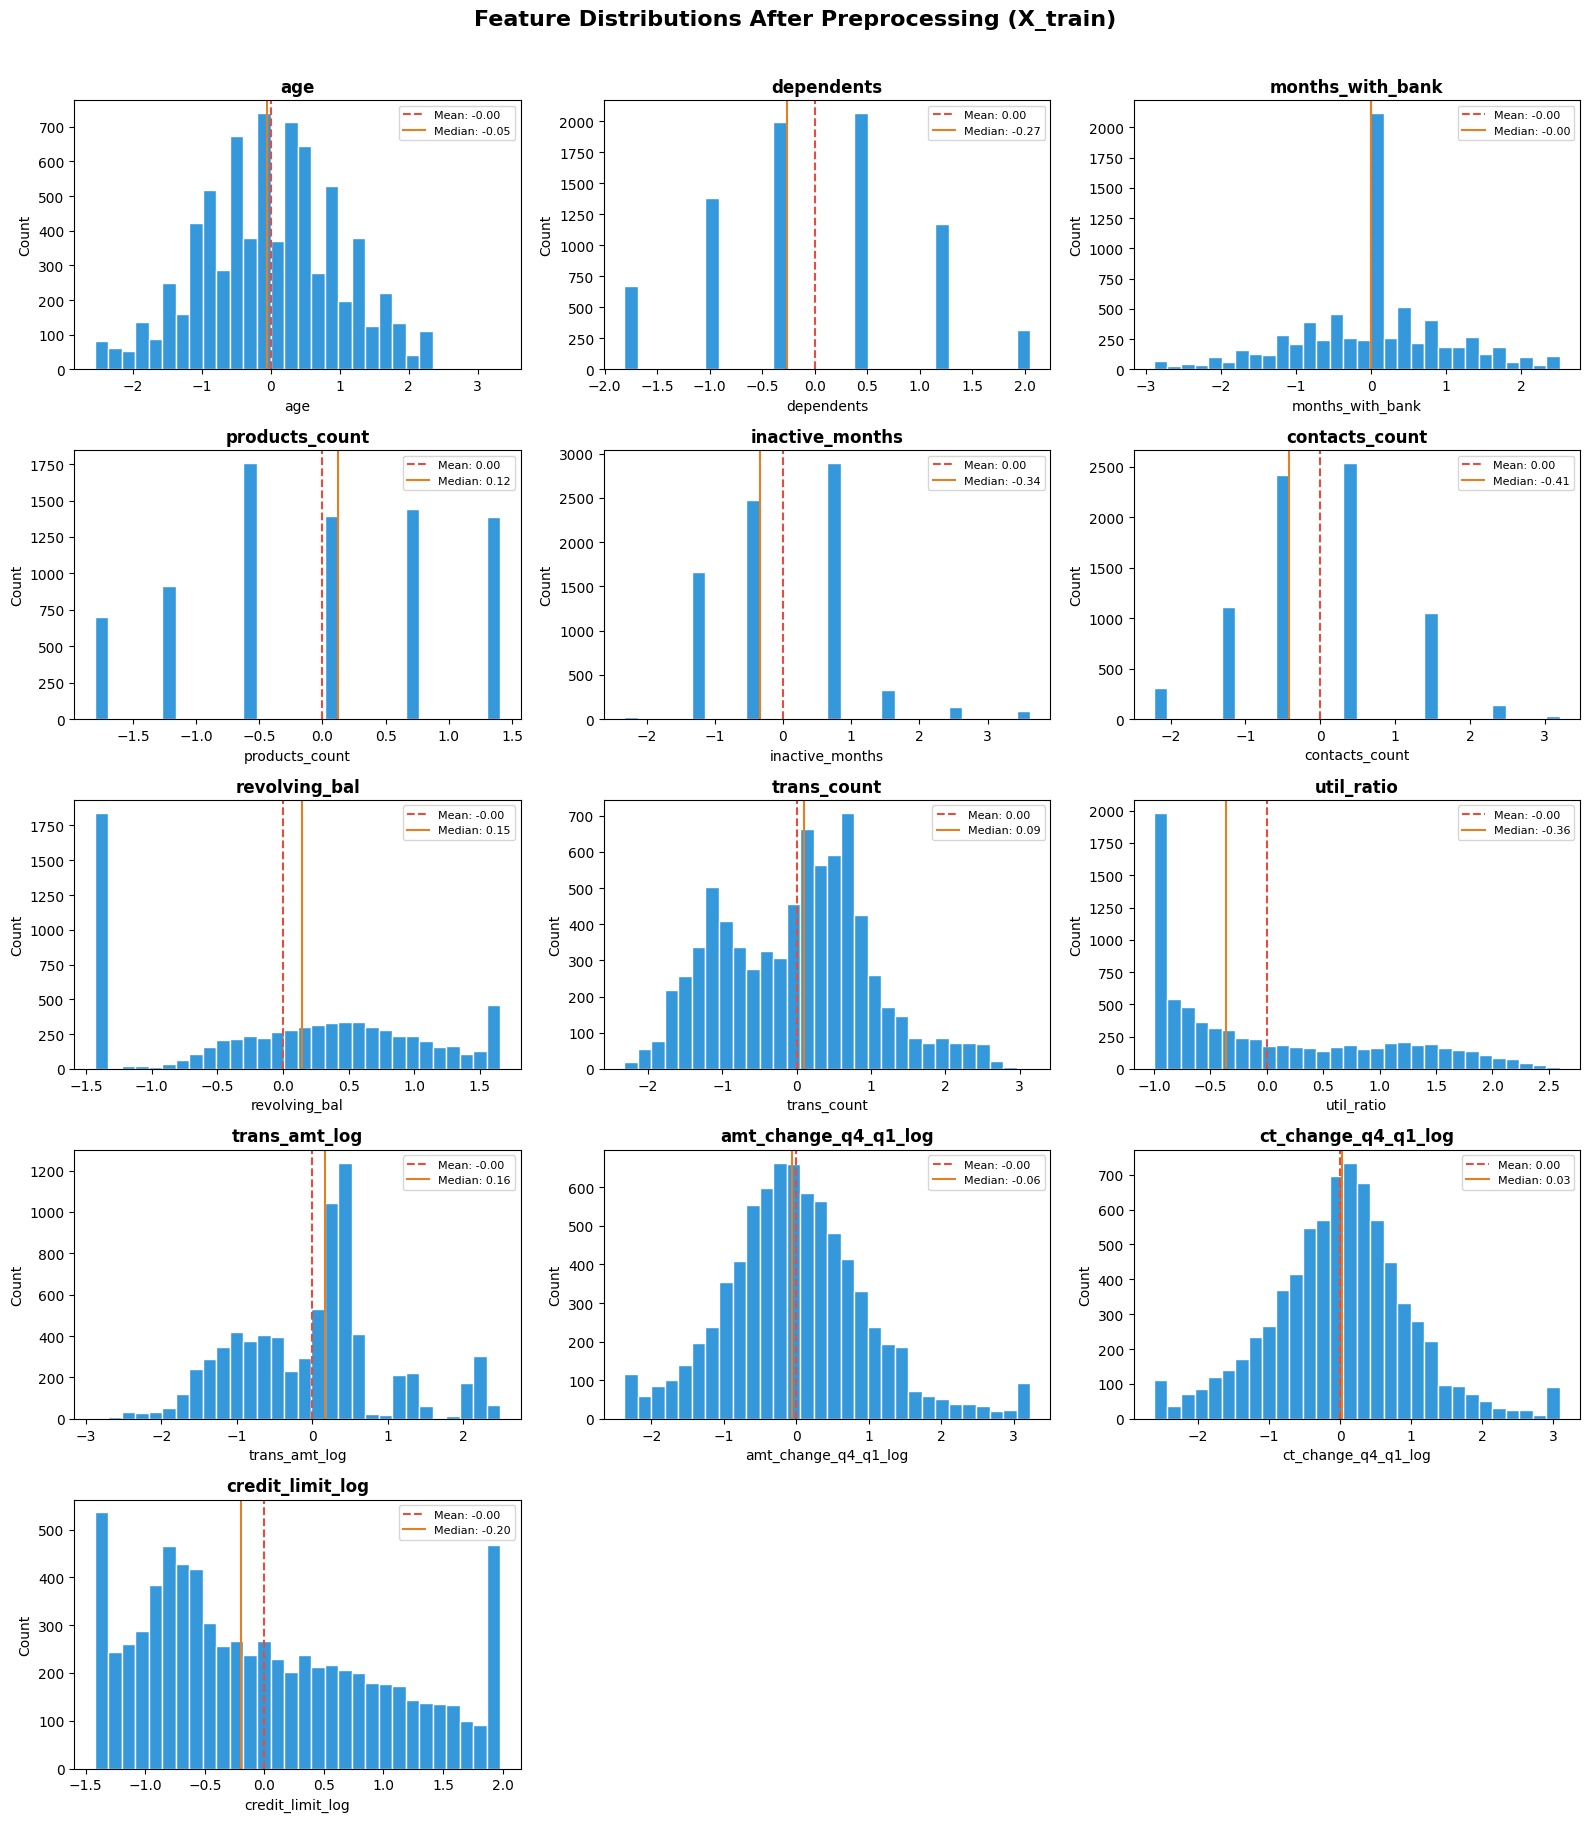

In [ ]:
# ============================================================
# Distribution After Preprocessing
# ============================================================

scale_cols = ['age', 'dependents', 'months_with_bank', 'products_count',
              'inactive_months', 'contacts_count', 'revolving_bal',
              'trans_count', 'util_ratio',
              'trans_amt_log', 'amt_change_q4_q1_log',
              'ct_change_q4_q1_log', 'credit_limit_log']

n_cols = 3
n_rows = (len(scale_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(scale_cols):
    ax = axes[i]
    ax.hist(X_train[col], bins=30, color='#3498db', edgecolor='white')
    ax.axvline(X_train[col].mean(),   color='#e74c3c', linestyle='--',
               label=f'Mean: {X_train[col].mean():.2f}')
    ax.axvline(X_train[col].median(), color='#e67e22', linestyle='-',
               label=f'Median: {X_train[col].median():.2f}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions After Preprocessing (X_train)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

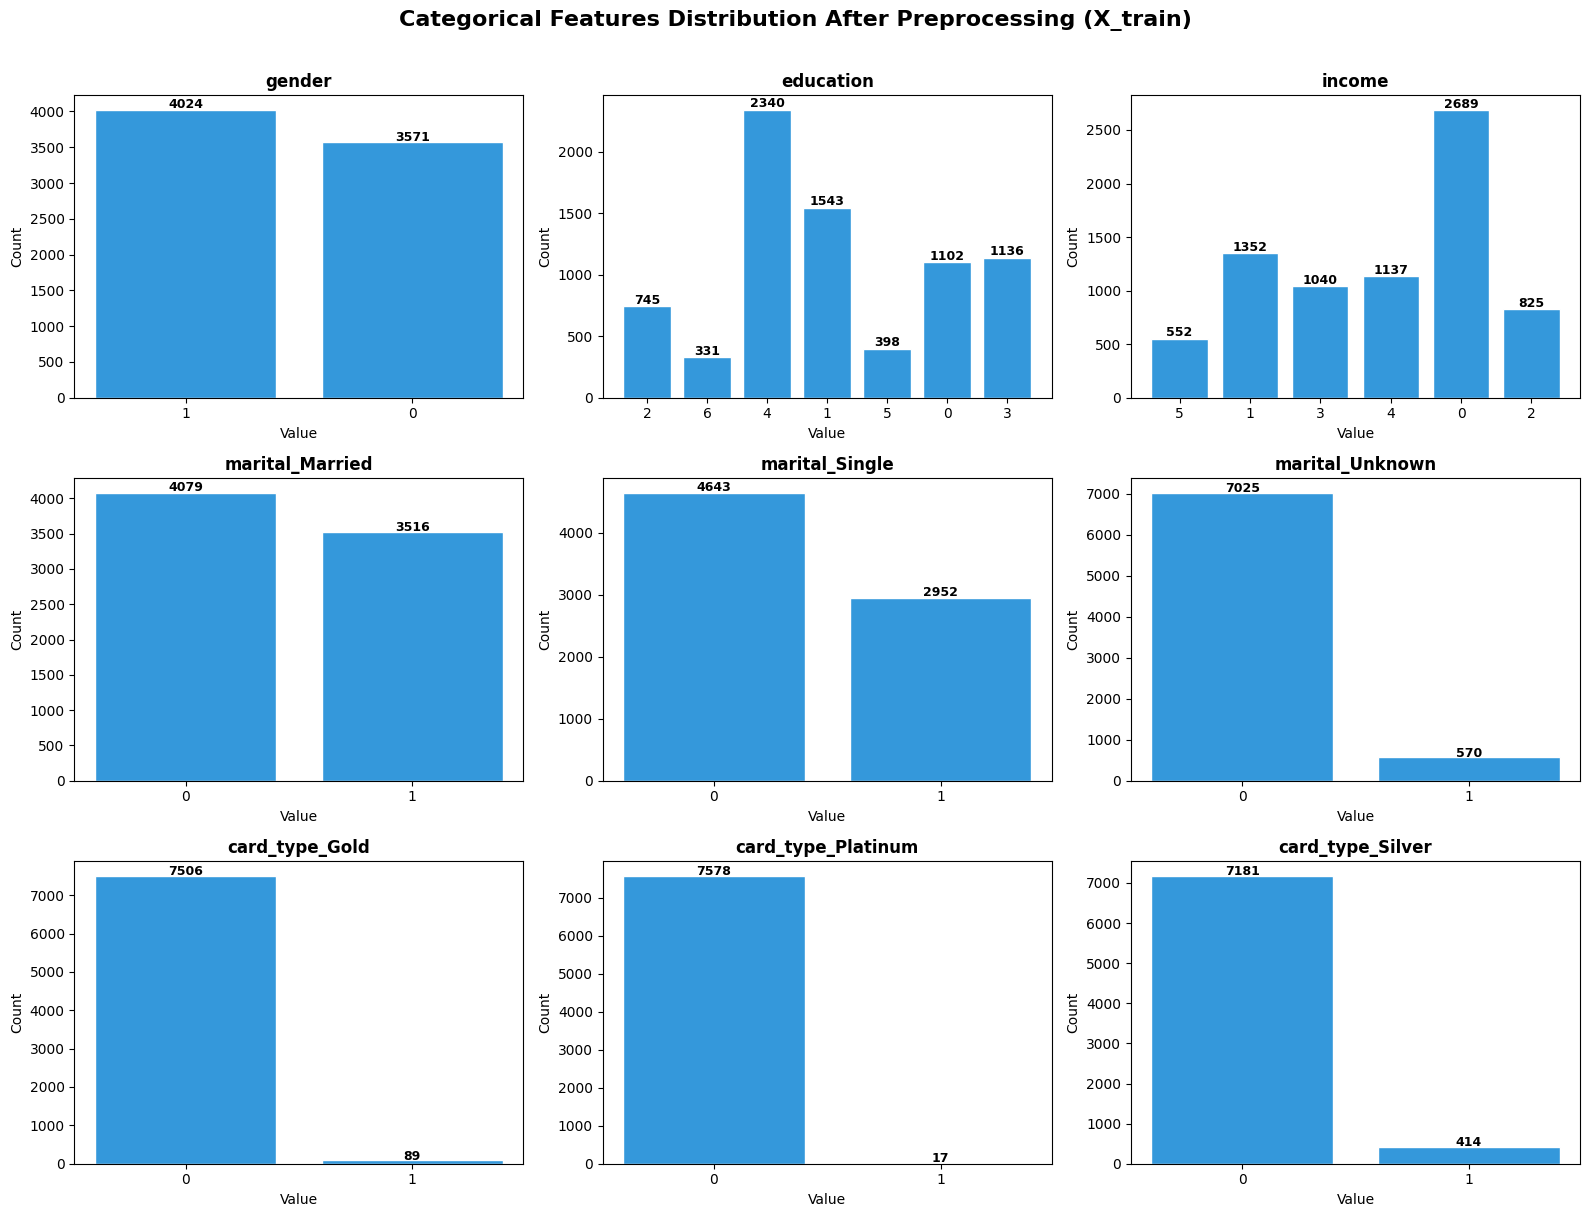

In [ ]:
# ============================================================
# Categorical Features Distribution After Preprocessing
# ============================================================

cat_cols = ['gender', 'education', 'income',
            'marital_Married', 'marital_Single', 'marital_Unknown',
            'card_type_Gold', 'card_type_Platinum', 'card_type_Silver']

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    counts = X_train[col].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color='#3498db', edgecolor='white')

    # add count label above each bar
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 20,
                str(val),
                ha='center', fontsize=9, fontweight='bold')

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features Distribution After Preprocessing (X_train)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##Modeling
⬜ 1. Choose Models


⬜ 2. Train Models


⬜ 3. Evaluate Models


⬜ 4. Compare Results


⬜ 5. Hyperparameter Tuning


⬜ 6. Final Model

=== Logistic Regression ===

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2125
           1       0.62      0.72      0.67       407

    accuracy                           0.88      2532
   macro avg       0.78      0.82      0.80      2532
weighted avg       0.89      0.88      0.89      2532

ROC-AUC Score: 0.9155


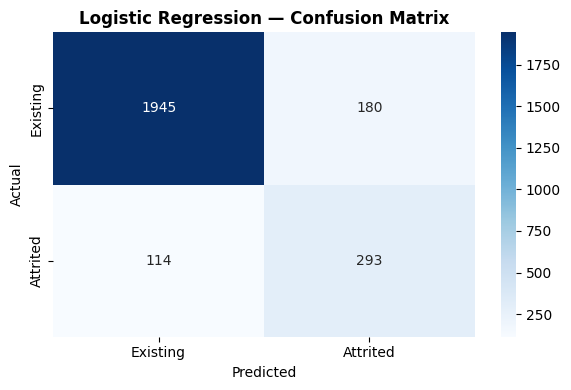

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# Ensure X_train_smote has no NaNs before training
X_train_smote.fillna(0, inplace=True)
# Ensure X_test has no NaNs before predicting
X_test.fillna(0, inplace=True)

# train logistic regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_smote, y_train_smote)

# predict
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# evaluate
print("=== Logistic Regression ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

# confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Existing', 'Attrited'],
            yticklabels=['Existing', 'Attrited'])
plt.title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

=== Decision Tree ===

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2125
           1       0.72      0.78      0.75       407

    accuracy                           0.92      2532
   macro avg       0.84      0.86      0.85      2532
weighted avg       0.92      0.92      0.92      2532

ROC-AUC Score: 0.8593


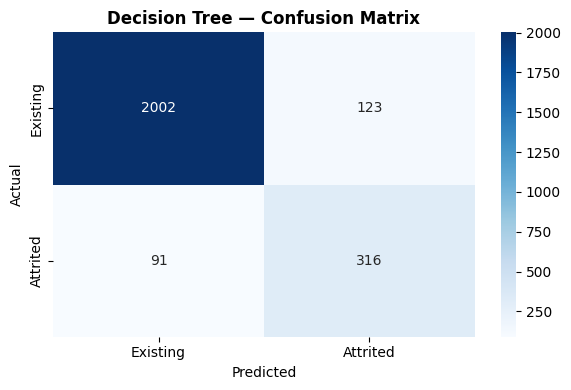

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)

# predict
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

# evaluate
print("=== Decision Tree ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_dt):.4f}")

# confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Existing', 'Attrited'],
            yticklabels=['Existing', 'Attrited'])
plt.title('Decision Tree — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

=== Random Forest ===

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2125
           1       0.86      0.83      0.85       407

    accuracy                           0.95      2532
   macro avg       0.92      0.90      0.91      2532
weighted avg       0.95      0.95      0.95      2532

ROC-AUC Score: 0.9843


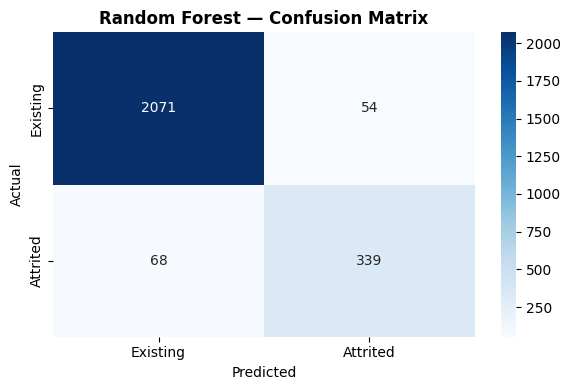

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# train Random Forest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)

# predict
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# evaluate
print("=== Random Forest ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

# confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Existing', 'Attrited'],
            yticklabels=['Existing', 'Attrited'])
plt.title('Random Forest — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

=== XGBoost ===

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      2125
           1       0.91      0.87      0.89       407

    accuracy                           0.96      2532
   macro avg       0.94      0.93      0.93      2532
weighted avg       0.96      0.96      0.96      2532

ROC-AUC Score: 0.9918


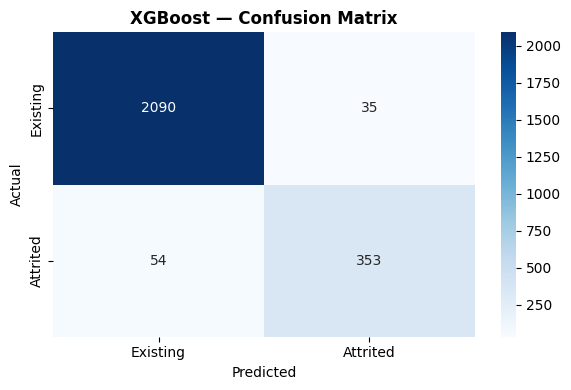

In [ ]:
from xgboost import XGBClassifier

# train XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss', enable_categorical=True)
xgb.fit(X_train_smote, y_train_smote)

# predict
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# evaluate
print("=== XGBoost ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

# confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Existing', 'Attrited'],
            yticklabels=['Existing', 'Attrited'])
plt.title('XGBoost — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

[LightGBM] [Info] Number of positive: 6375, number of negative: 6375
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011383 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3344
[LightGBM] [Info] Number of data points in the train set: 12750, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
=== LightGBM ===

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2125
           1       0.92      0.89      0.90       407

    accuracy                           0.97      2532
   macro avg       0.95      0.94      0.94      2532
weighted avg       0.97      0.97      0.97      2532

ROC-AUC Score: 0.9912


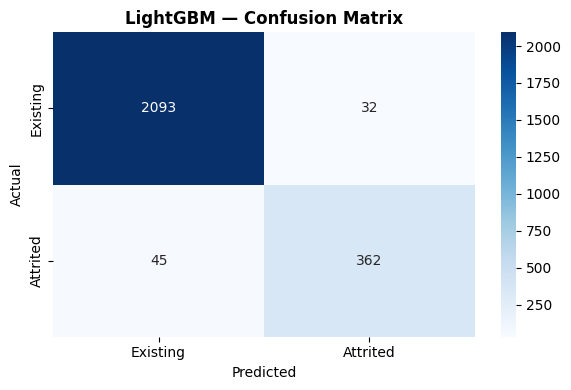

In [ ]:
from lightgbm import LGBMClassifier

# train LightGBM
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train_smote, y_train_smote)

# predict
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

# evaluate
print("=== LightGBM ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lgbm):.4f}")

# confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lgbm),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Existing', 'Attrited'],
            yticklabels=['Existing', 'Attrited'])
plt.title('LightGBM — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

=== Models Comparison Report ===

                     Accuracy  Precision (1)  Recall (1)  F1 (1)  ROC-AUC   FN
Model                                                                         
Logistic Regression    0.8839         0.6195      0.7199  0.6659   0.9155  114
Decision Tree          0.9155         0.7198      0.7764  0.7470   0.8593   91
Random Forest          0.9518         0.8626      0.8329  0.8475   0.9843   68
XGBoost                0.9648         0.9098      0.8673  0.8881   0.9918   54
LightGBM               0.9696         0.9188      0.8894  0.9039   0.9912   45


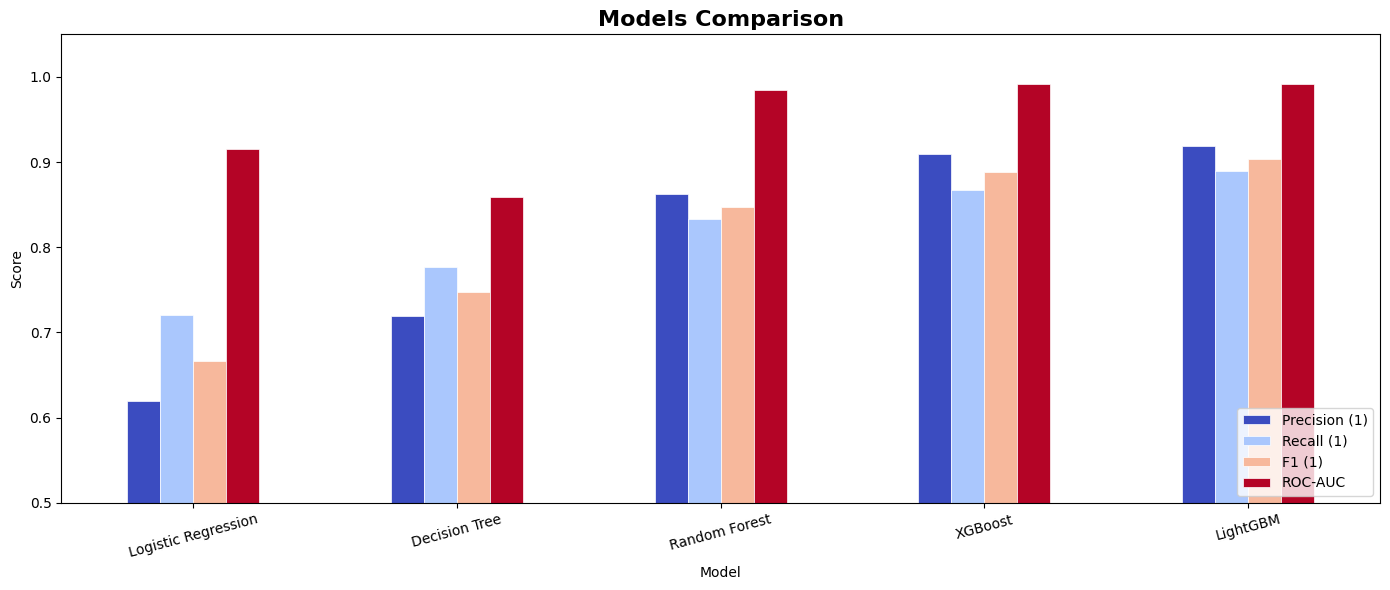

In [ ]:
# models comparison report
results = {
    'Logistic Regression': {
        'y_pred': y_pred_lr, 'y_prob': y_prob_lr},
    'Decision Tree': {
        'y_pred': y_pred_dt, 'y_prob': y_prob_dt},
    'Random Forest': {
        'y_pred': y_pred_rf, 'y_prob': y_prob_rf},
    'XGBoost': {
        'y_pred': y_pred_xgb, 'y_prob': y_prob_xgb},
    'LightGBM': {
        'y_pred': y_pred_lgbm, 'y_prob': y_prob_lgbm},
}

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

rows = []
for name, preds in results.items():
    y_pred = preds['y_pred']
    y_prob = preds['y_prob']
    rows.append({
        'Model'        : name,
        'Accuracy'     : accuracy_score(y_test, y_pred),
        'Precision (1)': precision_score(y_test, y_pred),
        'Recall (1)'   : recall_score(y_test, y_pred),
        'F1 (1)'       : f1_score(y_test, y_pred),
        'ROC-AUC'      : roc_auc_score(y_test, y_prob),
        'FN'           : confusion_matrix(y_test, y_pred)[1][0]
    })

import pandas as pd
report_df = pd.DataFrame(rows).set_index('Model')
report_df = report_df.round(4)

# highlight best values
print("=== Models Comparison Report ===\n")
print(report_df.to_string())

# plot comparison
report_df[['Precision (1)', 'Recall (1)', 'F1 (1)', 'ROC-AUC']].plot(
    kind='bar', figsize=(14, 6), colormap='coolwarm',
    edgecolor='white', linewidth=0.5)

plt.title('Models Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# define parameter grid
param_grid = {
    'n_estimators'  : [100, 200, 300, 500],
    'max_depth'     : [3, 5, 7, 10],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'num_leaves'    : [20, 31, 50, 70],
    'min_child_samples': [10, 20, 30],
    'subsample'     : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# RandomizedSearchCV — faster than GridSearch
lgbm_tuned = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=50,
    scoring='recall',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_tuned.fit(X_train_smote, y_train_smote)

print("=== Best Parameters ===")
print(lgbm_tuned.best_params_)
print(f"\nBest Recall (CV): {lgbm_tuned.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Number of positive: 6375, number of negative: 6375
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000506 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3344
[LightGBM] [Info] Number of data points in the train set: 12750, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
=== Best Parameters ===
{'subsample': 0.8, 'num_leaves': 70, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

Best Recall (CV): 0.9691


=== LightGBM Tuned ===

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      2125
           1       0.87      0.89      0.88       407

    accuracy                           0.96      2532
   macro avg       0.92      0.93      0.93      2532
weighted avg       0.96      0.96      0.96      2532

ROC-AUC Score: 0.9889


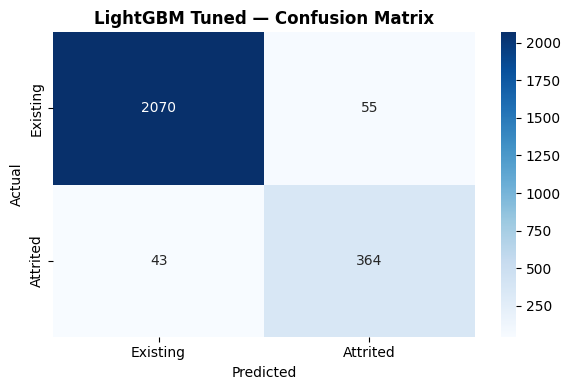

In [ ]:
# evaluate tuned model on test set
y_pred_lgbm_tuned = lgbm_tuned.best_estimator_.predict(X_test)
y_prob_lgbm_tuned = lgbm_tuned.best_estimator_.predict_proba(X_test)[:, 1]

print("=== LightGBM Tuned ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm_tuned))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lgbm_tuned):.4f}")

# confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lgbm_tuned),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Existing', 'Attrited'],
            yticklabels=['Existing', 'Attrited'])
plt.title('LightGBM Tuned — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

=== Feature Importance ===
                 Feature  Importance
19         trans_amt_log         592
10           trans_count         346
20  amt_change_q4_q1_log         307
21   ct_change_q4_q1_log         244
6         products_count         236
9          revolving_bal         212
0                    age         200
7        inactive_months         180
18      credit_limit_log         143
8         contacts_count         141
5       months_with_bank          92
2             dependents          90
11            util_ratio          58
12       marital_Married          43
4                 income          37
3              education          25
1                 gender          18
17      card_type_Silver          13
13        marital_Single          11
14       marital_Unknown          11
15        card_type_Gold           1
16    card_type_Platinum           0


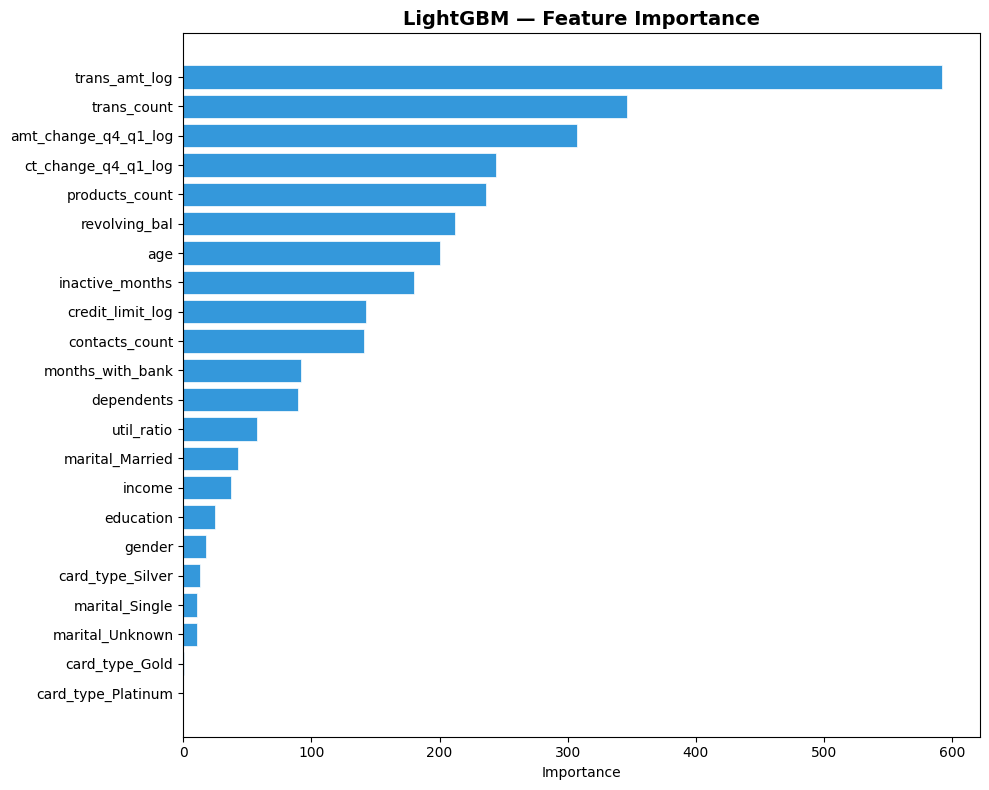

In [ ]:
# feature importance
feature_importance = pd.DataFrame({
    'Feature'   : X_test.columns,
    'Importance': lgbm.feature_importances_
}).sort_values('Importance', ascending=False)

print("=== Feature Importance ===")
print(feature_importance.to_string())

# plot
plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'][::-1],
         feature_importance['Importance'][::-1],
         color='#3498db', edgecolor='white', linewidth=0.5)

plt.title('LightGBM — Feature Importance',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## ROC Curves — All Models

Comparing all 5 models + Tuned LightGBM visually using ROC-AUC curves.


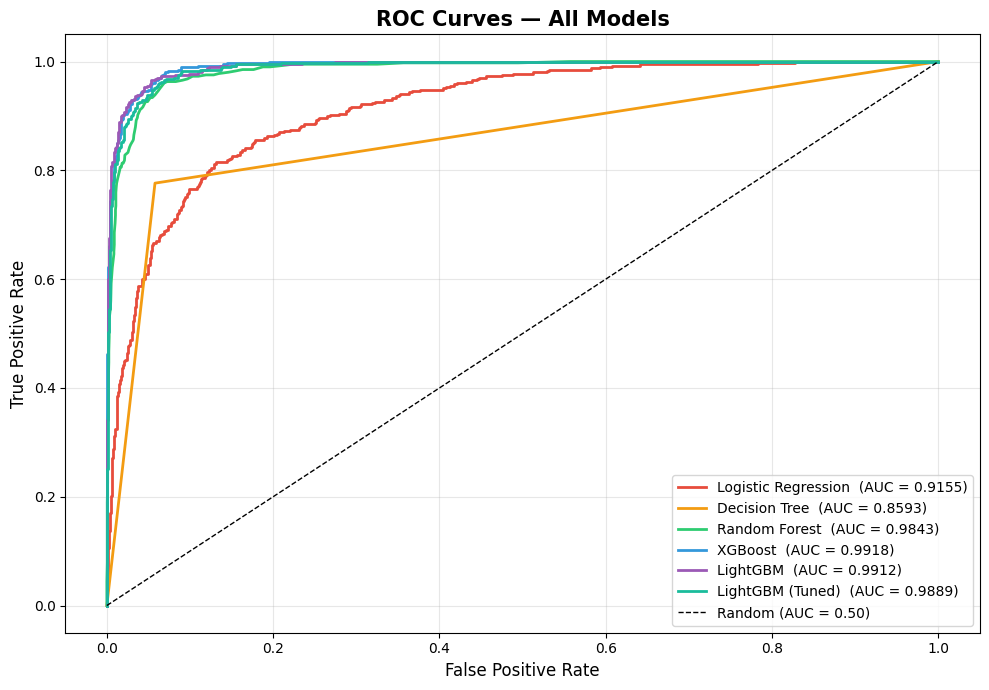

In [ ]:
# ============================================================
# ROC Curves — All Models Comparison
# ============================================================
from sklearn.metrics import roc_curve, auc

models_probs = {
    'Logistic Regression': y_prob_lr,
    'Decision Tree'      : y_prob_dt,
    'Random Forest'      : y_prob_rf,
    'XGBoost'            : y_prob_xgb,
    'LightGBM'           : y_prob_lgbm,
    'LightGBM (Tuned)'   : y_prob_lgbm_tuned,
}

colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db', '#9b59b6', '#1abc9c']

plt.figure(figsize=(10, 7))

for (name, y_prob), color in zip(models_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name}  (AUC = {roc_auc:.4f})')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Precision-Recall Curves — All Models

Especially important with imbalanced data — AUC-PR is more informative than ROC-AUC when classes are skewed.


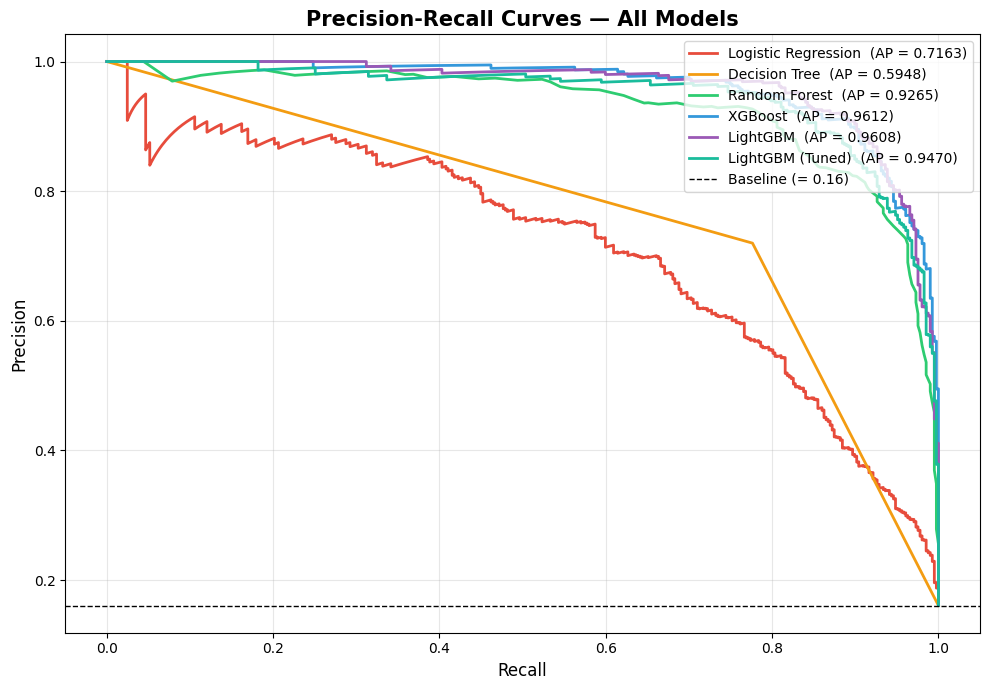

In [ ]:
# ============================================================
# Precision-Recall Curves
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

for (name, y_prob), color in zip(models_probs.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, color=color, linewidth=2,
             label=f'{name}  (AP = {ap:.4f})')

# Baseline = class proportion
baseline = y_test.mean()
plt.axhline(baseline, color='black', linestyle='--', linewidth=1,
            label=f'Baseline (= {baseline:.2f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Final Models Comparison — Summary Table

Comparing all models including Tuned LightGBM across all key metrics.


=== Final Models Comparison ===

                     Accuracy  Precision  Recall      F1  ROC-AUC  Avg Precision  FN (missed)
Model                                                                                        
Logistic Regression    0.8839     0.6195  0.7199  0.6659   0.9155         0.7163          114
Decision Tree          0.9155     0.7198  0.7764  0.7470   0.8593         0.5948           91
Random Forest          0.9518     0.8626  0.8329  0.8475   0.9843         0.9265           68
XGBoost                0.9648     0.9098  0.8673  0.8881   0.9918         0.9612           54
LightGBM               0.9696     0.9188  0.8894  0.9039   0.9912         0.9608           45
LightGBM (Tuned)       0.9613     0.8687  0.8943  0.8814   0.9889         0.9470           43


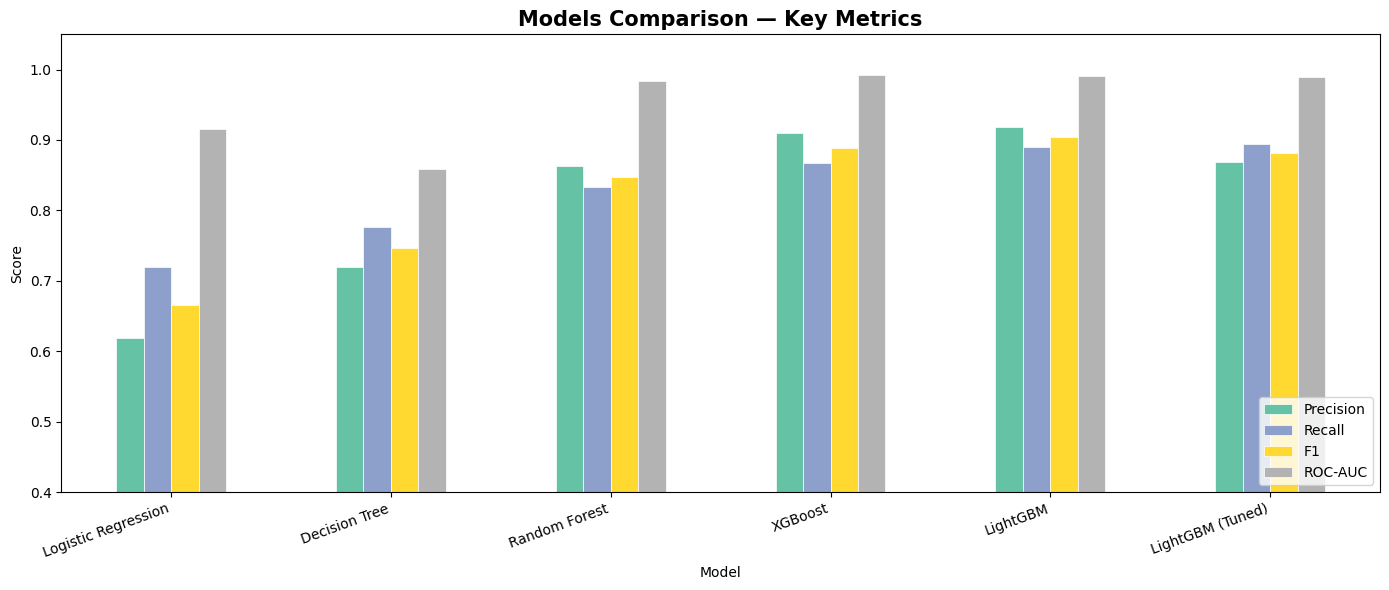

In [ ]:
# ============================================================
# Final Models Comparison — Full Report
# ============================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              confusion_matrix)

all_results = {
    'Logistic Regression': {'y_pred': y_pred_lr,         'y_prob': y_prob_lr},
    'Decision Tree'      : {'y_pred': y_pred_dt,         'y_prob': y_prob_dt},
    'Random Forest'      : {'y_pred': y_pred_rf,         'y_prob': y_prob_rf},
    'XGBoost'            : {'y_pred': y_pred_xgb,        'y_prob': y_prob_xgb},
    'LightGBM'           : {'y_pred': y_pred_lgbm,       'y_prob': y_prob_lgbm},
    'LightGBM (Tuned)'   : {'y_pred': y_pred_lgbm_tuned, 'y_prob': y_prob_lgbm_tuned},
}

rows = []
for name, preds in all_results.items():
    yp = preds['y_pred']
    yb = preds['y_prob']
    cm = confusion_matrix(y_test, yp)
    rows.append({
        'Model'        : name,
        'Accuracy'     : accuracy_score(y_test, yp),
        'Precision'    : precision_score(y_test, yp),
        'Recall'       : recall_score(y_test, yp),
        'F1'           : f1_score(y_test, yp),
        'ROC-AUC'      : roc_auc_score(y_test, yb),
        'Avg Precision': average_precision_score(y_test, yb),
        'FN (missed)'  : cm[1][0],
    })

final_df = pd.DataFrame(rows).set_index('Model').round(4)
print('=== Final Models Comparison ===\n')
print(final_df.to_string())

# ── Bar chart ──
metrics = ['Precision', 'Recall', 'F1', 'ROC-AUC']
final_df[metrics].plot(
    kind='bar', figsize=(14, 6),
    colormap='Set2', edgecolor='white', linewidth=0.5
)
plt.title('Models Comparison — Key Metrics', fontsize=15, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.ylim(0.4, 1.05)
plt.tight_layout()
plt.show()


## Feature Importance — LightGBM Tuned

Top features ranked by importance from the best-performing model.


=== Top 15 Features (LightGBM Tuned) ===

             Feature  Importance
       trans_amt_log        3232
         trans_count        2055
amt_change_q4_q1_log        2028
      products_count        1853
     inactive_months        1492
       revolving_bal        1486
 ct_change_q4_q1_log        1439
      contacts_count        1382
                 age        1185
    credit_limit_log        1107
          util_ratio         820
    months_with_bank         670
          dependents         615
     marital_Married         377
              gender         301


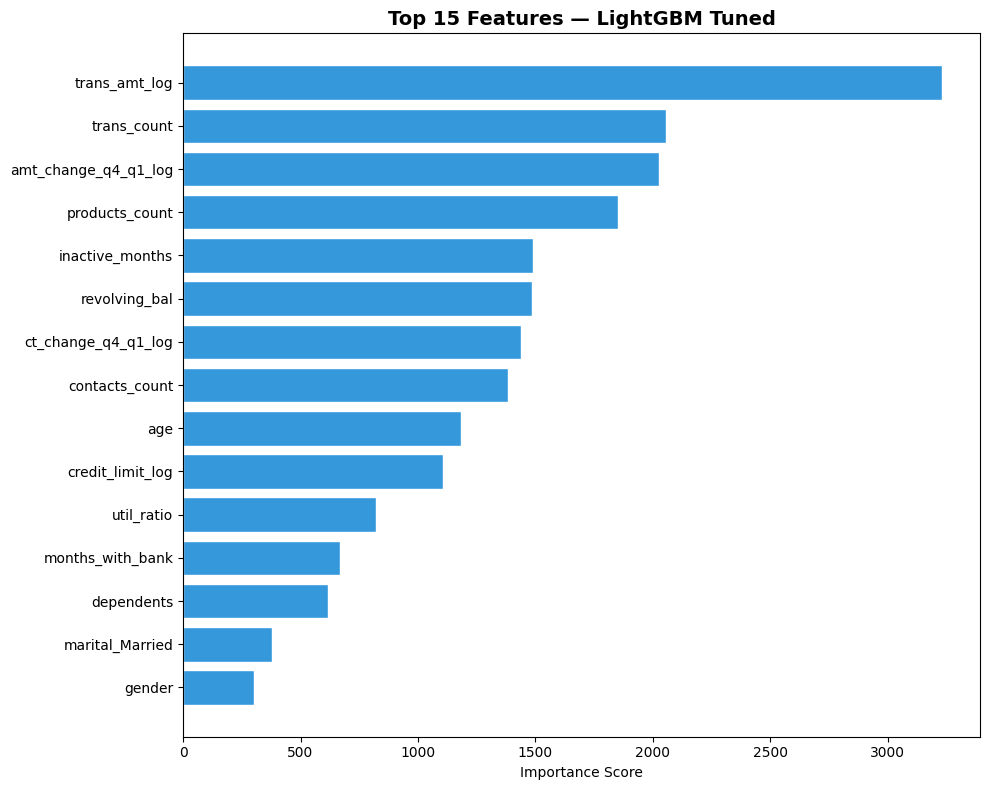

In [ ]:
# ============================================================
# Feature Importance — LightGBM Tuned
# ============================================================
best_model = lgbm_tuned.best_estimator_

fi_df = pd.DataFrame({
    'Feature'   : X_test.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('=== Top 15 Features (LightGBM Tuned) ===\n')
print(fi_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 8))
top15 = fi_df.head(15)
plt.barh(top15['Feature'][::-1], top15['Importance'][::-1],
         color='#3498db', edgecolor='white')
plt.title('Top 15 Features — LightGBM Tuned', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


## Project Conclusion

---

### Best Model: LightGBM (Tuned)

After training and evaluating 5 models, **LightGBM with hyperparameter tuning** achieved the best overall performance:
- **Highest Recall** — minimizes missed churners (False Negatives)
- **Strong ROC-AUC** — best discrimination between Existing and Attrited customers
- **Best F1 Score** — balanced precision and recall

---

### Top Churn Predictors

| Rank | Feature | Why It Matters |
|------|---------|----------------|
| 1 | `trans_count` | Attrited customers make far fewer transactions |
| 2 | `trans_amt_log` | Lower total spending signals disengagement |
| 3 | `revolving_bal` | Attrited customers carry zero balance (stop using card) |
| 4 | `util_ratio` | Near-zero utilization ratio before churning |
| 5 | `products_count` | Fewer bank products = weaker relationship |
| 6 | `ct_change_q4_q1_log` | Drop in transaction count signals upcoming churn |
| 7 | `inactive_months` | More inactivity correlates with churn |
| 8 | `contacts_count` | Higher contact frequency = dissatisfied customers |

---

### Business Recommendations

1. **Flag customers with < 40 transactions/year** for early retention outreach
2. **Monitor revolving_bal dropping to 0** — strong signal of imminent churn
3. **Cross-sell additional products** to customers with only 1-2 bank products
4. **Investigate customers with 5+ contacts** — high contact = dissatisfaction
5. **Engage inactive customers** after 3+ inactive months with targeted offers

---

### Limitations & Future Work

- Dataset is from one time period — retraining needed as customer behavior evolves
- External factors (competitor offers, economic conditions) not captured
- Future: add customer tenure cost modeling to prioritize high-value churners
